# RML Capstone Project — HMDA 2024 Loan/Application Records
## Group 4  | DNSC 6330

| Section | Member | Tools |
|---|---|---|
| Pre-modeling, Feature Selection & Modeling | Jenny | Data inspection, cleaning, LR, GBT, Integrate files|
| Lecture 2 — Transparency | Hassan | ICE, LIME, DiCE, SHAP |
| Lecture 3 — Fairness | Shanif | AIR, FPR/FNR, SMD, Calibration |
| Lecture 4 — Robustness | Velaphi + Jiah | PSI, KS, Stress Testing |
| Lecture 5 —  Privacy & Safety (attack) | Hesham + Jiah | PGD, Label-Flip Attack, Poisoning Degradation Curves, ROC Curve and Confidence Gap |
| Conclusion —   | Jenny |  |


---
# Part 1 — Pre-modeling, Feature Selection & Modeling
**Member: Jenny**

### Pre-modeling 

#### 1.	Data inspection

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

# Load local dataset
file_path = "2024_lar.txt"
raw_data = pd.read_csv(file_path, sep="|")

# Number of rows
raw_data.shape[0]

12259112

In [5]:
raw_data.head(10)

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,254900ZFWS2106HWPH46,41884,CA,6075.0,6075026303,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4632,89.83,184200,62.0,1015,1242,72
1,2024,254900ZFWS2106HWPH46,99999,IN,18093.0,18093951202,C,VA:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,2528,5.26,81800,117.0,1074,1334,27
2,2024,254900ZFWS2106HWPH46,33340,WI,55089.0,55089630201,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4565,7.78,102100,104.0,1576,1726,52
3,2024,254900ZFWS2106HWPH46,14860,CT,9120.0,9120080500,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3107,13.32,146500,75.0,1248,1397,64
4,2024,254900ZFWS2106HWPH46,11694,VA,51153.0,51153901233,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,7347,37.84,164200,129.0,2098,2154,27
5,2024,254900ZFWS2106HWPH46,36740,FL,12095.0,12095016603,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,7516,50.68,90400,123.0,1865,2572,17
6,2024,254900ZFWS2106HWPH46,15804,NJ,34007.0,34007603504,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,2688,29.39,117400,154.0,966,977,57
7,2024,254900ZFWS2106HWPH46,34980,TN,47165.0,47165021005,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,6063,19.21,101700,118.0,1577,2069,33
8,2024,254900ZFWS2106HWPH46,12054,GA,13063.0,13063040521,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3329,93.03,100900,45.0,501,963,50
9,2024,254900ZFWS2106HWPH46,19124,TX,48121.0,48121021722,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4150,35.23,110300,116.0,1005,1374,31


In [6]:
list(raw_data.columns)

['activity_year',
 'lei',
 'derived_msa_md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open_end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'combined_loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'in

In [7]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12259112 entries, 0 to 12259111
Data columns (total 99 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  

#### 2.	Target construction

We construct a binary target variable based on the `action_taken` field, where approved applications (values 1 and 2) are labeled as 1, and denied applications (value 3) are labeled as 0. All other categories are excluded to ensure a clean binary classification setup.



We create a binary label from the `action_taken` column:

| `action_taken` | Meaning | Label |
|---|---|---|
| 1 | Loan originated | **1 (Approved)** |
| 2 | Approved but not accepted | **1 (Approved)** |
| 3 | Application denied | **0 (Denied)** |
| Other | Withdrawn, incomplete, etc. | **Filtered out** |

In [4]:
df = raw_data.replace(['NA', 'Exempt'], np.nan).copy()
df['action_taken'] = pd.to_numeric(df['action_taken'], errors='coerce')
df = df[df['action_taken'].isin([1, 2, 3])].copy()
df['target'] = np.where(df['action_taken'].isin([1, 2]), 1, 0)
df.drop(columns=['action_taken'], inplace=True)

print(f'After filtering: {df.shape[0]:,} rows')
print(df['target'].value_counts(normalize=True).rename({1: 'Approved', 0: 'Denied'}).round(3))

After filtering: 8,661,739 rows
target
Approved    0.757
Denied      0.243
Name: proportion, dtype: float64


In [5]:
import numpy as np

# Create a copy of the original dataset to avoid modifying raw data
df = raw_data.copy()

# Step 1: Filter the dataset to keep only relevant action_taken values
# Keep:
# 1 = Loan originated
# 2 = Approved but not accepted
# 3 = Denied
# Remove all other categories (e.g., withdrawn, incomplete, etc.)
df = df[df["action_taken"].isin([1, 2, 3])]

# Step 2: Create a binary target variable
# Approved (1, 2) → 1
# Denied (3) → 0
df["target"] = np.where(
    df["action_taken"].isin([1, 2]),  # approved cases
    1,
    0  # denied cases
)

# Step 3: Check the distribution of the target variable
# This helps us understand class balance (approved vs denied)
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
1    6558283
0    2103456
Name: count, dtype: int64
target
1    0.757155
0    0.242845
Name: proportion, dtype: float64



The constructed target variable shows that approximately 75.7% of applications are approved, while 24.3% are denied. This class imbalance reflects real-world lending patterns, where approvals are more frequent than denials. This imbalance has important implications for both model performance and fairness evaluation. In particular, a model may achieve high accuracy by favoring the majority class, while still performing poorly on denied cases. As a result, it is critical to examine error rates such as false positive rate (FPR) and false negative rate (FNR), especially across different demographic groups, in subsequent analysis.

#### 3. Data cleaning

**Converting values into `NaN`** 

In this dataset, values such as "NA" and "Exempt" represent missing or non-applicable information, but they are stored as text rather than true missing values. Since Python does not automatically recognize these strings as missing, they may be mistakenly treated as valid data or distinct categories. This can distort both statistical analysis and model training.

Therefore, we convert these values into `NaN`, which allows the system to correctly identify them as missing. This step is important for ensuring accurate calculation of missingness and for maintaining data quality in later stages of the analysis.

In [6]:
df = df.replace(["NA", "Exempt"], np.nan)

**Identifying Missing Values**

After converting "NA" and "Exempt" into `NaN`, we calculate the proportion of missing values for each column. This allows us to clearly see how much data is missing in each feature. By sorting the results, we can easily identify columns with very high missing rates, which may need to be removed or handled carefully in later steps.

In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

co_applicant_ethnicity_5        0.999996
co_applicant_ethnicity_4        0.999988
applicant_ethnicity_5           0.999988
applicant_ethnicity_4           0.999960
co_applicant_race_5             0.999913
applicant_race_5                0.999785
co_applicant_race_4             0.999763
co_applicant_ethnicity_3        0.999541
applicant_race_4                0.999362
applicant_ethnicity_3           0.998645
co_applicant_race_3             0.998397
denial_reason_4                 0.998200
multifamily_affordable_units    0.997217
applicant_race_3                0.995576
aus_5                           0.991795
aus_4                           0.990886
denial_reason_3                 0.990197
total_points_and_fees           0.987652
aus_3                           0.981436
co_applicant_race_2             0.978635
dtype: float64

**Dropping Columns with More Than 90% Missing Values**

To ensure data quality, we remove columns with excessive missingness. Specifically, we identify all columns where more than 90% of the values are missing and drop them from the dataset.

This step helps eliminate features that provide little useful information and could negatively impact model performance or analysis results. By retaining only columns with sufficient data, we create a more robust and reliable dataset for further processing.

In [8]:
cols_to_drop = missing[missing > 0.9].index
df = df.drop(columns=cols_to_drop)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8661739 entries, 1 to 12259110
Data columns (total 74 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  preapp

**Data Type Conversion**

In this step, we adjust the data types of selected variables to better reflect their actual meaning.

For variables such as `income` and `loan_amount`, although they look like numbers, they are stored as strings due to the presence of values like "NA" or "Exempt". If we do not convert them, numerical operations may fail or produce incorrect results. Therefore, we convert these columns into numeric types, allowing proper calculations in later analysis.

For variables such as `derived_race`, `derived_ethnicity`, and `derived_sex`, they are clearly categorical in nature. Even though they are stored as object types, this does not explicitly indicate that they are categories. By converting them to `category`, we ensure they are properly recognized as grouped variables, which is important for fairness analysis and for encoding in the modeling stage.

This step helps ensure that the dataset is correctly structured for further analysis and modeling.

In [10]:
# Convert numeric variables
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

# Convert categorical variables
cat_cols = ["derived_race", "derived_ethnicity", "derived_sex"]
for col in cat_cols:
    df[col] = df[col].astype("category")

#### 4.	Baseline fairness analysis (pre-model)

Before building the model, we first examine fairness in the raw data by comparing approval rates across different demographic groups, including race, ethnicity, and sex.

These variables represent key protected attributes, and analyzing them helps us understand whether there are existing disparities in lending outcomes. If certain groups have consistently lower approval rates, this may indicate potential bias or structural differences in the data.

This step is important because it allows us to separate data-driven disparities from model-driven bias. By establishing a baseline, we can later evaluate whether the model reduces, preserves, or amplifies these differences.

Therefore, pre-model fairness analysis is a critical step in responsible machine learning, as it provides essential context for interpreting model results.

In [11]:
df.groupby("derived_race")["target"].mean().sort_values()

derived_race
Free Form Text Only                          0.410526
Native Hawaiian or Other Pacific Islander    0.613013
2 or more minority races                     0.619721
American Indian or Alaska Native             0.629663
Black or African American                    0.633430
Race Not Available                           0.722380
White                                        0.781922
Asian                                        0.787291
Joint                                        0.804578
Name: target, dtype: float64

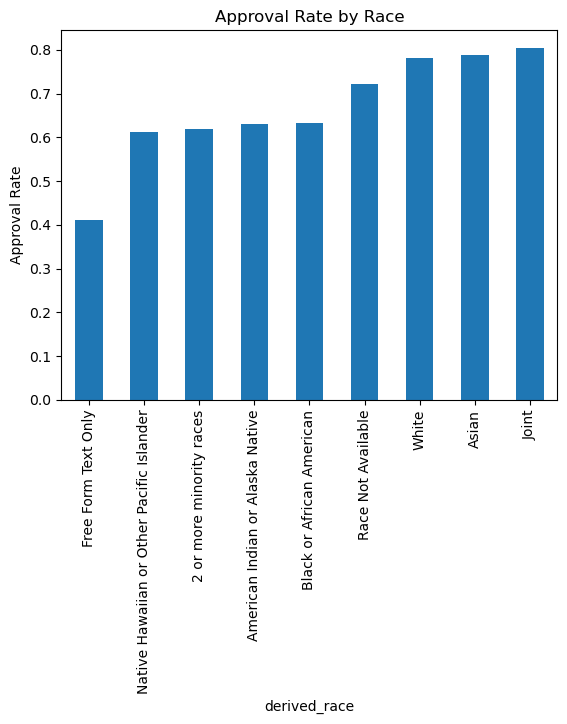

In [12]:
import matplotlib.pyplot as plt

df.groupby("derived_race")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race")
plt.show()

**Approval Rate by Race**

The approval rate varies significantly across racial groups, indicating the presence of disparities in the raw data. In particular, applicants identified as White and Asian exhibit higher approval rates compared to other groups such as Black or African American. Additionally, the "Joint" category, which represents applications involving multiple applicants, shows one of the highest approval rates. This may reflect stronger combined financial profiles rather than group-specific effects. On the other hand, the "Free Form Text Only" category has a notably lower approval rate. Since this category represents non-standard or self-reported entries, it may reflect data quality issues or incomplete demographic information. Overall, these results suggest that disparities exist across racial groups even before modeling, highlighting the importance of further fairness analysis.

In [13]:
df.groupby("derived_ethnicity")["target"].mean()

derived_ethnicity
Ethnicity Not Available    0.729368
Free Form Text Only        0.514610
Hispanic or Latino         0.695343
Joint                      0.792613
Not Hispanic or Latino     0.773476
Name: target, dtype: float64

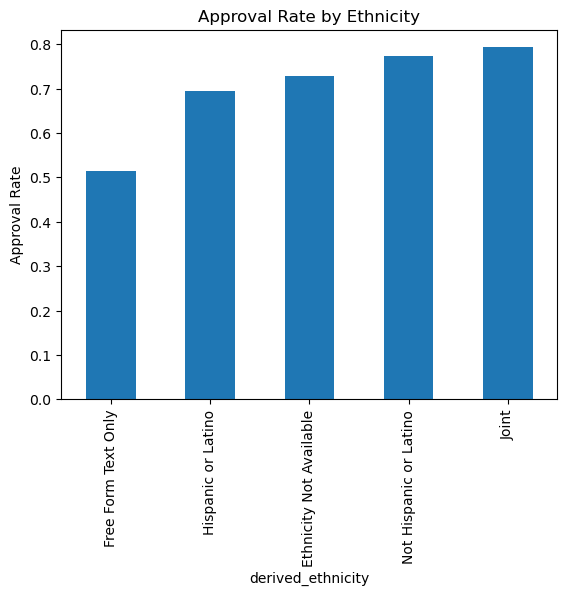

In [14]:
df.groupby("derived_ethnicity")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Ethnicity")
plt.show()

**Approval Rate by Ethnicity**

Approval rates differ across ethnicity groups, with "Not Hispanic or Latino" and "Joint" categories showing higher approval rates compared to "Hispanic or Latino" and "Free Form Text Only". The "Joint" category again reflects applications with multiple applicants, which may lead to stronger financial qualifications and therefore higher approval rates. The lower approval rate observed for the "Free Form Text Only" group may be due to incomplete or non-standard reporting of ethnicity, which can affect both data quality and interpretation. These differences suggest that ethnicity-related disparities may exist in the dataset and should be carefully examined in further analysis.

In [15]:
df.groupby("derived_sex")["target"].mean()

derived_sex
Female               0.707112
Joint                0.816700
Male                 0.735659
Sex Not Available    0.733773
Name: target, dtype: float64

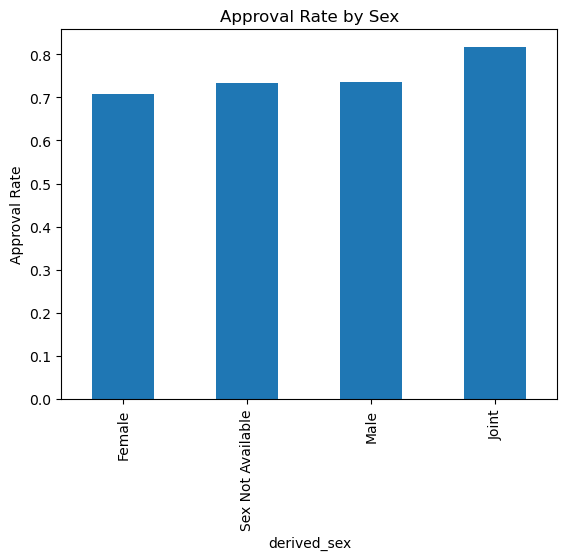

In [16]:
df.groupby("derived_sex")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Sex")
plt.show()

**Approval Rate by Sex**

Approval rates across sex categories appear relatively similar, with only modest differences between male and female applicants. However, the "Joint" category again shows a higher approval rate, likely reflecting the presence of multiple applicants and potentially stronger combined financial profiles. The "Sex Not Available" group also appears, which may indicate missing or unreported information. This highlights potential data quality limitations that should be considered when interpreting results. Overall, compared to race and ethnicity, disparities across sex appear less pronounced in the raw data.

**Examining Control Variables**

To better understand whether observed disparities in approval rates are driven by legitimate financial factors, we examine key control variables such as income and debt-to-income (DTI) ratio across different racial groups. These variables are commonly used in lending decisions and reflect applicants’ financial capacity and risk.

By analyzing these factors, we aim to distinguish whether differences in approval rates are due to underlying financial characteristics or whether disparities persist even after accounting for these variables, which may indicate potential bias.

In [17]:
df.groupby("derived_race").agg({
    "income": "mean",
    "target": "mean"
})

,income,target
derived_race,,
2 or more minority races,2478.580259,0.619721
American Indian or Alaska Native,189.597924,0.629663
Asian,223.782925,0.787291
Black or African American,312.504156,0.633430
Free Form Text Only,117.999535,0.410526
Joint,186.673917,0.804578
Native Hawaiian or Other Pacific Islander,136.327801,0.613013
Race Not Available,169.927337,0.722380
White,163.145481,0.781922


**Comparing Approval Rates and Income Across Racial Groups**

The results show clear differences in approval rates across racial groups. For example, White and Asian applicants have relatively high approval rates (around 78–79%), while Black or African American applicants have a lower approval rate (around 63%).

Interestingly, these differences are not fully explained by income levels. In particular, the Black or African American group has the highest average income among all groups, yet its approval rate remains lower than that of White and Asian applicants. This suggests that income alone does not fully account for the observed disparities.

However, these results should be interpreted with caution. At this stage, we have not yet controlled for other important factors such as debt-to-income ratio, loan type, or other risk-related variables. Therefore, while the findings indicate the presence of disparities in the data, they do not necessarily imply bias.

Further analysis is needed to determine whether these differences are driven by legitimate financial factors or potential unfair treatment.

**Handling and Simplifying Debt-to-Income Ratio (DTI)**

The original `debt_to_income_ratio` variable contains a mixture of formats, including both numeric values (e.g., 40.0, 45.0) and categorical ranges (e.g., "20%-<30%", "50%-60%"). This makes the data inconsistent and difficult to interpret directly, especially when comparing financial risk across groups.

To improve readability and analysis, we aim to group DTI into a small number of meaningful categories (e.g., <30%, 30–40%, 40–50%, etc.) and examine how these risk levels relate to approval rates.

However, in order to classify values using conditional statements (e.g., `if x < 30`), the data must first be in numeric form. Since the original variable includes both numbers and string-based ranges, a direct conversion to numeric would result in many values being converted to `NaN`, causing significant information loss.

To address this, we first map each range-based value to a representative numeric value (e.g., "30%-<36%" → 33). This step allows us to preserve the relative meaning of each range while converting all values into a consistent numeric format.

Once the data is standardized, we can then apply conditional logic to group observations into clearly defined DTI categories, enabling a more structured and interpretable analysis of financial risk and approval outcomes.


We convert to a numeric midpoint, then group into 5 risk tiers:

| HMDA Value | Numeric Midpoint | Group |
|---|---|---|
| `<20%` | 15 | `<30%` |
| `20%-<30%` | 25 | `<30%` |
| `30%-<36%` | 33 | `30-40%` |
| `50%-60%` | 55 | `50-60%` |
| `>60%` | 65 | `>60%` |

In [18]:
import numpy as np

def dti_to_numeric(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    if "<20%" in x:
        return 15
    elif "20%-<30%" in x:
        return 25
    elif "30%-<36%" in x:
        return 33
    elif "36" in x and "%" in x:
        return 36
    elif "50%-60%" in x:
        return 55
    elif ">60%" in x:
        return 65
    
    try:
        return float(x)
    except:
        return np.nan

In [19]:
df["dti_numeric"] = df["debt_to_income_ratio"].apply(dti_to_numeric)

In [20]:
def simplify_dti(x):
    if pd.isna(x):
        return "Missing"
    
    if x < 30:
        return "<30%"
    elif x < 40:
        return "30-40%"
    elif x < 50:
        return "40-50%"
    elif x < 60:
        return "50-60%"
    else:
        return ">60%"

In [21]:
df["dti_group"] = df["dti_numeric"].apply(simplify_dti)

In [22]:
result = df.groupby(["derived_race", "dti_group"])["target"].mean().unstack()
result["overall_approval_rate"] = df.groupby("derived_race")["target"].mean()
result

dti_group,30-40%,40-50%,50-60%,<30%,>60%,Missing,overall_approval_rate
derived_race,,,,,,,
2 or more minority races,0.771525,0.795628,0.563624,0.558792,0.054297,0.582692,0.619721
American Indian or Alaska Native,0.767349,0.794302,0.556998,0.592345,0.046657,0.612624,0.629663
Asian,0.901438,0.895853,0.543929,0.841224,0.060949,0.756799,0.787291
Black or African American,0.755349,0.782178,0.590037,0.594256,0.056617,0.636871,0.633430
Free Form Text Only,0.628895,0.711221,0.350365,0.447183,0.008532,0.195122,0.410526
Joint,0.879516,0.878217,0.692835,0.835759,0.138678,0.756244,0.804578
Native Hawaiian or Other Pacific Islander,0.771999,0.786864,0.591261,0.604984,0.056678,0.600861,0.613013
Race Not Available,0.831719,0.827933,0.587694,0.759695,0.075564,0.728183,0.722380
White,0.874311,0.867662,0.628879,0.826859,0.096398,0.751141,0.781922


**Comparing Approval Rates and debt_to_income_rate  Across Racial Groups**

To better understand whether approval disparities are driven by financial risk, we examine approval rates across racial groups within the same DTI categories.

Overall, approval rates decrease as DTI increases, which is expected since higher debt-to-income ratios indicate higher financial risk. This suggests that lending decisions are at least partially aligned with risk-based factors.

However, even within the same DTI group, differences across racial groups still exist. In particular, White applicants consistently show relatively high approval rates across most DTI categories. For example, in the 30–40% and 40–50% DTI ranges, White applicants maintain approval rates close to or above 85%, which are among the highest across all groups.

In contrast, some groups, such as Black or African American and "2 or more minority races," tend to have lower approval rates within the same DTI categories. This suggests that differences in financial risk alone do not fully explain the observed disparities.

Overall, these results indicate that while DTI explains part of the variation in approval rates, disparities across racial groups persist even after controlling for financial risk. This may suggest the presence of unequal treatment or unobserved factors, and warrants further investigation in the modeling stage.

### Modeling  

#### 5.	Feature selection

**Model Design and Feature Selection**

To evaluate both predictive performance and fairness, we construct two models with different feature sets.

---

**Model A: Baseline Model (Excluding Protected Attributes)**

Model A includes only financial and loan-related variables that are commonly used in lending decisions:

- **1. income**: Represents the applicant’s repayment ability. Higher income generally indicates lower default risk.

- **2. ebt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant’s debt burden relative to income.

- **3. loan_term**: Indicates the duration of the loan. Longer terms may be associated with different risk profiles.

- **4. loan_type**: Different loan types (e.g., conventional vs. FHA) have different approval standards and risk characteristics.

- **5. loan_purpose**: Distinguishes between purposes such as home purchase or refinancing, which may affect approval likelihood.

- **6. applicant_credit_score_type**: Indicates the type of credit scoring model used for the applicant. Although it is not the numeric credit score itself, it can still serve as a proxy for credit evaluation differences and may help explain variation in approval patterns or pricing decisions.

- **7. tract_minority_population_percent**: Measures the share of minority residents in the applicant’s census tract. This variable can serve as a neighborhood-level proxy for demographic context and is useful for analyzing potential geographic or structural fairness issues beyond individual protected attributes.

- **8. combined_loan_to_value_ratio**:  Captures the ratio between the loan amount and the property value, directly reflecting the borrower’s leverage level. A higher CLTV indicates that the borrower is financing a larger portion of the property, which typically implies higher credit risk and plays a critical role in underwriting decisions.

- **9. property_value**: Represents the estimated value of the property used as collateral. This feature provides context for the scale of the loan and helps the model assess whether the requested loan amount is reasonable relative to the asset value.


We retain combined **combined_loan-to-value ratio (CLTV)** and **property_value** while excluding **loan_amount** to avoid redundancy. CLTV captures the borrower’s leverage and directly reflects credit risk, while property_value provides contextual information about the scale of the underlying asset. Together, they allow the model to distinguish between relative risk and absolute transaction size, leading to clearer interpretation and more reliable fairness analysis.

We exclude **interest_rate** and **rate_spread** from the main model because they are closely tied to pricing outcomes and may introduce data leakage, as they are not strictly determined before the approval decision. We also exclude **state_code** to avoid capturing broad geographic patterns that may reflect structural or historical disparities rather than individual financial risk. These variables are instead used in post-model analysis, where **interest_rate** and **rate_spread** support pricing fairness evaluation, and **state_code** is used to assess robustness and geographic disparities.

These variables are included because they provide meaningful and justifiable information about financial risk and lending conditions. Model A represents a fairness-aware design that does not directly use protected attributes in decision-making.

---
**Model B: Extended Model (Including Protected Attribute)**

Model B includes all features from Model A, with the addition of:

- **derived_race**: A protected attribute representing the applicant’s race.

This model is not intended for deployment but is used as an analytical tool to examine whether including race improves predictive performance and how it affects fairness. The reason of not adding sex is because we didn't observe the disparity in raw data. 

---

**Purpose of Comparing Two Models**

The goal of constructing these two models is to analyze the trade-off between accuracy and fairness. By comparing Model A and Model B, we can evaluate:

- Whether including race significantly improves predictive accuracy
- Whether it leads to increased disparities across racial groups

In particular, we focus on group-based error metrics such as:

- **False Positive Rate (FPR)**: The rate at which applicants who should be rejected are incorrectly approved
- **False Negative Rate (FNR)**: The rate at which applicants who should be approved are incorrectly rejected

By comparing FPR and FNR across racial groups, we can assess whether the model produces unequal error patterns, which may indicate potential bias.


In [23]:
from sklearn.model_selection import train_test_split

#features without race 
featuresA = [
    "income",
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
    

]
#features with race 
featuresB= featuresA + ["derived_race"]
target = "target"

#### 6. Train-Test Split

We use the same train/test split for both models to ensure a fair comparison. Although Model A and Model B differ in the number of features, they are trained and evaluated on identical data. This allows us to isolate the effect of including the protected attribute and compare performance and fairness metrics more reliably.

**Model A (without race)**

In [24]:
# -----------------------------
# Step 0: define feature types
# -----------------------------
numeric_features_A = [
    "income",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
]

categorical_features_A = [
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type"
]

# -----------------------------
# Step 1: clean dtypes in df
# -----------------------------
# Numeric columns
for col in numeric_features_A:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical columns: use object instead of pandas string dtype
for col in categorical_features_A:
    df[col] = df[col].astype("object")

df["derived_race"] = df["derived_race"].astype("object")

# Convert pandas <NA> to np.nan for sklearn compatibility
df = df.replace({pd.NA: np.nan})

# -----------------------------
# Step 2: build X and y
# -----------------------------
X_A = df[featuresA].copy()
y = df[target].astype(int).copy()

# -----------------------------
# Step 3: train/test split
# -----------------------------
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# optional check
print(X_train_A.dtypes)
print(X_test_A.dtypes)

# Compute counts
n_total = len(X_A)
n_train = len(X_train_A)
n_test = len(X_test_A)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(X_train_A.dtypes)
print(X_test_A.dtypes)

print(
    f"Model A → Train: {X_train_A.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test_A.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

income                               float64
dti_group                             object
loan_term                             object
loan_type                              int64
loan_purpose                           int64
applicant_credit_score_type            int64
tract_minority_population_percent    float64
combined_loan_to_value_ratio         float64
property_value                       float64
dtype: object
income                               float64
dti_group                             object
loan_term                             object
loan_type                              int64
loan_purpose                           int64
applicant_credit_score_type            int64
tract_minority_population_percent    float64
combined_loan_to_value_ratio         float64
property_value                       float64
dtype: object
income                               float64
dti_group                             object
loan_term                             object
loan_type                  

**Model B (without race)**

In [25]:
import numpy as np
import pandas as pd

# Build X
X_B = df[featuresB].copy()

# Use SAME split indices as Model A
X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B = X_B.loc[X_test_A.index].copy()

# Numeric columns
for col in numeric_features_A:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col] = pd.to_numeric(X_test_B[col], errors="coerce")

# Categorical columns
numeric_features_B = numeric_features_A
categorical_features_B = categorical_features_A + ["derived_race"]

for col in categorical_features_B:
    X_train_B[col] = X_train_B[col].astype("object")
    X_test_B[col] = X_test_B[col].astype("object")

    # Convert pd.NA / None / missing values to np.nan
    X_train_B[col] = X_train_B[col].where(pd.notna(X_train_B[col]), np.nan)
    X_test_B[col] = X_test_B[col].where(pd.notna(X_test_B[col]), np.nan)

# Final safety check: replace any remaining pd.NA
X_train_B = X_train_B.replace({pd.NA: np.nan})
X_test_B = X_test_B.replace({pd.NA: np.nan})


# optional check
print(X_train_B.dtypes)
print(X_test_B.dtypes)

print(
    f"Model B → Train: {X_train_B.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test_B.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)


income                               float64
dti_group                             object
loan_term                             object
loan_type                              int64
loan_purpose                           int64
applicant_credit_score_type            int64
tract_minority_population_percent    float64
combined_loan_to_value_ratio         float64
property_value                       float64
derived_race                          object
dtype: object
income                               float64
dti_group                             object
loan_term                             object
loan_type                              int64
loan_purpose                           int64
applicant_credit_score_type            int64
tract_minority_population_percent    float64
combined_loan_to_value_ratio         float64
property_value                       float64
derived_race                          object
dtype: object
Model B → Train: (6929391, 10) (6,929,391 rows, 80.0%), Test: (1732348, 

#### 7.  logistic regression (Model A vs Model B)

**Model A**

In [27]:
# Fix mixed types in categorical columns
X_train_A = X_train_A.copy()
X_test_A = X_test_A.copy()

for col in categorical_features_A:
    X_train_A[col] = X_train_A[col].astype("string").fillna("Missing")
    X_test_A[col] = X_test_A[col].astype("string").fillna("Missing")

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 4: preprocessing for Model A
# -----------------------------
numeric_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_A, numeric_features_A),
        ("cat", categorical_transformer_A, categorical_features_A)
    ]
)

# -----------------------------
# Step 5: Logistic Regression pipeline
# -----------------------------
model_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 6: fit model
# -----------------------------
model_A.fit(X_train_A, y_train)

# -----------------------------
# Step 7: predictions
# -----------------------------
y_train_pred_A = model_A.predict(X_train_A)
y_test_pred_A = model_A.predict(X_test_A)

# -----------------------------
# Step 8: evaluation
# -----------------------------
train_acc_A = accuracy_score(y_train, y_train_pred_A)
test_acc_A = accuracy_score(y_test, y_test_pred_A)

print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8274
Test Accuracy:  0.8275


In [29]:
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# Build result table for fairness evaluation
result_A = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_test_pred_A,
    "race": df.loc[X_test_A.index, "derived_race"].values
}, index=X_test_A.index)

# Group by race
fairness_A = result_A.groupby("race", dropna=False).apply(compute_metrics)
fairness_A.round(4)



,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.8018,0.5502,0.0415,0.7632
American Indian or Alaska Native,12619.0,0.8208,0.5764,0.0372,0.7647
Asian,104588.0,0.8786,0.5296,0.0265,0.8660
Black or African American,152109.0,0.8129,0.5765,0.0502,0.7569
Free Form Text Only,428.0,0.6028,0.3941,0.0440,0.7360
Joint,38136.0,0.9075,0.6474,0.0289,0.8495
Native Hawaiian or Other Pacific Islander,4247.0,0.7667,0.5103,0.0624,0.7584
Race Not Available,304705.0,0.8562,0.6018,0.0463,0.7997
White,1111212.0,0.8905,0.6121,0.0318,0.8416


**Model B**

In [30]:
# --- Model B ---
X_train_B = X_train_B.copy()
X_test_B = X_test_B.copy()

for col in categorical_features_B:
    X_train_B[col] = X_train_B[col].astype("string").fillna("Missing")
    X_test_B[col] = X_test_B[col].astype("string").fillna("Missing")

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -----------------------------
# Step 3: preprocessing for Model B
# -----------------------------
numeric_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_B, numeric_features_B),
        ("cat", categorical_transformer_B, categorical_features_B)
    ]
)

# -----------------------------
# Step 4: Logistic Regression pipeline
# -----------------------------
model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 5: fit Model B
# -----------------------------
model_B.fit(X_train_B, y_train)

# -----------------------------
# Step 6: predictions
# -----------------------------
y_train_pred_B = model_B.predict(X_train_B)
y_test_pred_B = model_B.predict(X_test_B)

# -----------------------------
# Step 7: evaluation
# -----------------------------
train_acc_B = accuracy_score(y_train, y_train_pred_B)
test_acc_B = accuracy_score(y_test, y_test_pred_B)

print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8286
Test Accuracy:  0.8286


In [32]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B = model_B.predict(X_test_B)

# Combine results
result_B = X_test_B.copy()
result_B["y_true"] = y_test.values
result_B["y_pred"] = pred_B
result_B["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B = result_B.groupby("race", dropna=False).apply(compute_metrics)

fairness_B.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.7426,0.4552,0.0784,0.7770
American Indian or Alaska Native,12619.0,0.7604,0.4789,0.0762,0.7759
Asian,104588.0,0.8866,0.5469,0.0210,0.8666
Black or African American,152109.0,0.7631,0.5014,0.0855,0.7620
Free Form Text Only,428.0,0.3715,0.1859,0.3145,0.7664
Joint,38136.0,0.9154,0.6665,0.0237,0.8499
Native Hawaiian or Other Pacific Islander,4247.0,0.7271,0.4526,0.0899,0.7650
Race Not Available,304705.0,0.8384,0.5670,0.0576,0.8012
White,1111212.0,0.9020,0.6374,0.0242,0.8420


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [33]:
fairness_A_renamed = fairness_A.rename(columns={
    "FPR": "FPR_A",
    "FNR": "FNR_A",
    "Accuracy": "Accuracy_A",
    "Approval_Rate": "Approval_Rate_A"
}).drop(columns=["Count"])

fairness_B_renamed = fairness_B.rename(columns={
    "FPR": "FPR_B",
    "FNR": "FNR_B",
    "Accuracy": "Accuracy_B",
    "Approval_Rate": "Approval_Rate_B"
}).drop(columns=["Count"])

comparison_lr = fairness_A_renamed.join(fairness_B_renamed)
comparison_lr.round(4)

,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.8018,0.5502,0.0415,0.7632,0.7426,0.4552,0.0784,0.7770
American Indian or Alaska Native,0.8208,0.5764,0.0372,0.7647,0.7604,0.4789,0.0762,0.7759
Asian,0.8786,0.5296,0.0265,0.8660,0.8866,0.5469,0.0210,0.8666
Black or African American,0.8129,0.5765,0.0502,0.7569,0.7631,0.5014,0.0855,0.7620
Free Form Text Only,0.6028,0.3941,0.0440,0.7360,0.3715,0.1859,0.3145,0.7664
Joint,0.9075,0.6474,0.0289,0.8495,0.9154,0.6665,0.0237,0.8499
Native Hawaiian or Other Pacific Islander,0.7667,0.5103,0.0624,0.7584,0.7271,0.4526,0.0899,0.7650
Race Not Available,0.8562,0.6018,0.0463,0.7997,0.8384,0.5670,0.0576,0.8012
White,0.8905,0.6121,0.0318,0.8416,0.9020,0.6374,0.0242,0.8420


In [34]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8274
Test Accuracy:  0.8275
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8286
Test Accuracy:  0.8286


**Interpretation of Results**

While the inclusion of race in Model B leads to a slight improvement in overall accuracy, this improvement does not translate into better outcomes for all groups.

In particular, for groups such as American Indian or Alaska Native and Black or African American applicants, approval rates decrease noticeably after including race. At the same time, their false negative rates (FNR) increase, indicating that more qualified applicants from these groups are incorrectly denied.

This suggests that although the model becomes slightly more accurate overall, it may do so at the expense of certain minority groups. In other words, the gain in predictive performance is accompanied by a worsening of error distribution across groups.

This highlights an important trade-off: improving overall accuracy does not necessarily improve fairness, and in some cases may even exacerbate disparities.

#### 8. Gradient boost tree (Model A vs Model B)

**Model A**

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step: Gradient Boosting pipeline (Model A)
# -----------------------------
model_A_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# Fit model
# -----------------------------
model_A_gbt.fit(X_train_A, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_gbt = model_A_gbt.predict(X_train_A)
y_test_pred_gbt = model_A_gbt.predict(X_test_A)

# -----------------------------
# Accuracy
# -----------------------------
train_acc_gbt = accuracy_score(y_train, y_train_pred_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_pred_gbt)

print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")


========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8492
Test Accuracy:  0.8492


In [36]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_gbt = model_A_gbt.predict(X_test_A)

# ---------- Combine results ----------
result_gbt = X_test_A.copy()
result_gbt["y_true"] = y_test.values
result_gbt["y_pred"] = pred_gbt

result_gbt["race"] = df.loc[X_test_A.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_gbt = result_gbt.groupby("race", dropna=False).apply(compute_metrics)
fairness_gbt.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.7716,0.4679,0.0392,0.7962
American Indian or Alaska Native,12619.0,0.7735,0.4504,0.0388,0.8100
Asian,104588.0,0.8772,0.5034,0.0211,0.8757
Black or African American,152109.0,0.7820,0.4891,0.0485,0.7900
Free Form Text Only,428.0,0.6005,0.3866,0.0377,0.7430
Joint,38136.0,0.9021,0.5807,0.0192,0.8704
Native Hawaiian or Other Pacific Islander,4247.0,0.7509,0.4550,0.0518,0.7869
Race Not Available,304705.0,0.8523,0.5446,0.0298,0.8275
White,1111212.0,0.8786,0.5405,0.0271,0.8609


**Model B**

In [46]:
# -----------------------------
# Gradient Boosting pipeline
# -----------------------------
model_B_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# fit model
# -----------------------------
model_B_gbt.fit(X_train_B, y_train)

# -----------------------------
# predictions
# -----------------------------
y_train_pred_B_gbt = model_B_gbt.predict(X_train_B)
y_test_pred_B_gbt = model_B_gbt.predict(X_test_B)

# -----------------------------
# evaluation
# -----------------------------
train_acc_B_gbt = accuracy_score(y_train, y_train_pred_B_gbt)
test_acc_B_gbt = accuracy_score(y_test, y_test_pred_B_gbt)

print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8474
Test Accuracy:  0.8473


In [47]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B_gbt = model_B_gbt.predict(X_test_B)

# ---------- Combine results ----------
result_B_gbt = X_test_B.copy()
result_B_gbt["y_true"] = y_test.values
result_B_gbt["y_pred"] = pred_B_gbt
result_B_gbt["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B_gbt = result_B_gbt.groupby("race", dropna=False).apply(compute_metrics)

fairness_B_gbt.round(4)

,Approval_Rate,FPR,FNR,Accuracy
race,,,,
2 or more minority races,0.7665,0.4613,0.0434,0.7962
American Indian or Alaska Native,0.7638,0.4415,0.0491,0.8067
Asian,0.8718,0.4924,0.0250,0.8751
Black or African American,0.7560,0.4487,0.0662,0.7936
Free Form Text Only,0.5794,0.3569,0.0440,0.7593
Joint,0.8962,0.5714,0.0243,0.8681
Native Hawaiian or Other Pacific Islander,0.7415,0.4426,0.0593,0.7874
Race Not Available,0.8425,0.5239,0.0354,0.8292
White,0.8865,0.5671,0.0244,0.8572


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [48]:
fairness_gbt_A_renamed = fairness_gbt.rename(columns={
    "FPR": "FPR_A_GBT",
    "FNR": "FNR_A_GBT",
    "Accuracy": "Accuracy_A_GBT",
    "Approval_Rate": "Approval_Rate_A_GBT"
}).drop(columns=["Count"], errors="ignore")

fairness_gbt_B_renamed = fairness_B_gbt.rename(columns={
    "FPR": "FPR_B_GBT",
    "FNR": "FNR_B_GBT",
    "Accuracy": "Accuracy_B_GBT",
    "Approval_Rate": "Approval_Rate_B_GBT"
}).drop(columns=["Count"], errors="ignore")

comparison_gbt = fairness_gbt_A_renamed.join(fairness_gbt_B_renamed)
comparison_gbt.round(4)

,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.7772,0.4831,0.0396,0.7902,0.7665,0.4613,0.0434,0.7962
American Indian or Alaska Native,0.7793,0.4674,0.0396,0.8032,0.7638,0.4415,0.0491,0.8067
Asian,0.8778,0.5079,0.0215,0.8745,0.8718,0.4924,0.0250,0.8751
Black or African American,0.7849,0.4964,0.0482,0.7875,0.7560,0.4487,0.0662,0.7936
Free Form Text Only,0.5888,0.3680,0.0377,0.7547,0.5794,0.3569,0.0440,0.7593
Joint,0.9039,0.5926,0.0199,0.8675,0.8962,0.5714,0.0243,0.8681
Native Hawaiian or Other Pacific Islander,0.7509,0.4562,0.0526,0.7860,0.7415,0.4426,0.0593,0.7874
Race Not Available,0.8579,0.5643,0.0296,0.8222,0.8425,0.5239,0.0354,0.8292
White,0.8796,0.5496,0.0283,0.8580,0.8865,0.5671,0.0244,0.8572


In [49]:
print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8461
Test Accuracy:  0.8459
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8474
Test Accuracy:  0.8473


**Interpretation of GBT Results**

The gradient-boosted tree model achieves significantly higher accuracy and lower error rates (FPR and FNR) compared to logistic regression.

This improvement can be explained by the flexibility of the GBT model. Unlike logistic regression, which assumes a linear relationship, gradient boosting is able to capture complex, non-linear interactions between features. By iteratively correcting prediction errors and combining multiple weak learners, the model can better fit the underlying patterns in the data.  


#### 9. Decision Tree (Only model A)

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step: Decision Tree pipeline (Model A)
# -----------------------------
model_A_tree = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,          
        min_samples_leaf=50,  
        random_state=42
    ))
])

# -----------------------------
# Fit model
# -----------------------------
model_A_tree.fit(X_train_A, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_tree = model_A_tree.predict(X_train_A)
y_test_pred_tree = model_A_tree.predict(X_test_A)

# -----------------------------
# Accuracy
# -----------------------------
train_acc_tree = accuracy_score(y_train, y_train_pred_tree)
test_acc_tree = accuracy_score(y_test, y_test_pred_tree)

print("========== Model A: Decision Tree ==========")
print(f"Train Accuracy: {train_acc_tree:.4f}")
print(f"Test Accuracy:  {test_acc_tree:.4f}")

========== Model A: Decision Tree ==========
Train Accuracy: 0.8325
Test Accuracy:  0.8325


In [38]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_tree = model_A_tree.predict(X_test_A)

# ---------- Combine results ----------
result_tree = X_test_A.copy()
result_tree["y_true"] = y_test.values
result_tree["y_pred"] = pred_tree

# Add race back only for fairness evaluation
result_tree["race"] = df.loc[X_test_A.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_tree = result_tree.groupby("race", dropna=False).apply(compute_metrics)

fairness_tree.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.8130,0.5690,0.0351,0.7600
American Indian or Alaska Native,12619.0,0.8106,0.5444,0.0348,0.7780
Asian,104588.0,0.8863,0.5473,0.0215,0.8660
Black or African American,152109.0,0.8251,0.5810,0.0335,0.7657
Free Form Text Only,428.0,0.6449,0.4498,0.0252,0.7079
Joint,38136.0,0.9068,0.6209,0.0232,0.8593
Native Hawaiian or Other Pacific Islander,4247.0,0.7815,0.5303,0.0510,0.7572
Race Not Available,304705.0,0.8925,0.6710,0.0225,0.7978
White,1111212.0,0.8922,0.6005,0.0264,0.8484


**Decision Tree (Model A) — Summary**

The Decision Tree model shows very similar performance on the training and test sets (Train Accuracy = 0.8313, Test Accuracy = 0.8314), indicating minimal generalization gap and good robustness without clear signs of overfitting.

From a fairness perspective, disparities across racial groups are still present. In particular, groups such as Black or African American and “2 or more minority races” exhibit relatively higher false positive rates (FPR), while some groups (e.g., NH/PI) show higher false negative rates (FNR), suggesting uneven error distribution across groups. 

At the same time, approval rates vary notably across races (e.g., lower for “Native Hawaiian or Other Pacific Islander” and higher for “Joint” and “White”), indicating that the model’s decisions are not uniform across groups. 

Overall, even though the Decision Tree is a simpler and more interpretable model, it still produces observable disparities similar to those seen in other models. This suggests that the source of bias is likely rooted in the data itself rather than the choice of model.

#### 10. Comparison Across Modeling Approaches (LR vs GBT (ModelA & B))

**Why We Use Multiple Models?**

We use both logistic regression and gradient-boosted trees to ensure that our results are robust and not dependent on a single modeling approach.

Logistic regression is simple and interpretable, but it assumes a linear relationship between features and the outcome. In contrast, gradient-boosted trees are more flexible and can capture complex, non-linear patterns by iteratively correcting prediction errors and combining multiple weak models into a stronger one.

By comparing the results from both models, we can check whether our findings, especially those related to fairness are consistent. If both models lead to similar conclusions, we can be more confident that the results reflect real patterns in the data rather than artifacts of a specific model.

**Performance from Different Approaches**

To summarize the results across different modeling approaches, we present the comparison tables below.

In [50]:
print("Logistic Regression")
display(comparison_lr)

print("Gradient Boosted Tree")
display(comparison_gbt)

Logistic Regression


,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.803439,0.553874,0.041101,0.762082,0.742797,0.455811,0.078431,0.776719
American Indian or Alaska Native,0.820430,0.577006,0.038206,0.763848,0.763690,0.484685,0.074283,0.774943
Asian,0.878476,0.533757,0.027754,0.864038,0.887052,0.551909,0.021782,0.864851
Black or African American,0.814501,0.578837,0.049086,0.756694,0.766575,0.505962,0.082570,0.762203
Free Form Text Only,0.593458,0.390335,0.062893,0.731308,0.422897,0.223048,0.238994,0.771028
Joint,0.907515,0.649420,0.029311,0.848752,0.916011,0.669689,0.023697,0.849276
Native Hawaiian or Other Pacific Islander,0.768307,0.512655,0.061224,0.758182,0.727337,0.450265,0.087912,0.767130
Race Not Available,0.853954,0.598347,0.048048,0.799442,0.838542,0.567392,0.057500,0.801188
White,0.890625,0.614758,0.032425,0.840567,0.902511,0.639961,0.024254,0.841460


Gradient Boosted Tree


,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.777184,0.483051,0.039593,0.790195,0.766496,0.461259,0.043363,0.796236
American Indian or Alaska Native,0.779301,0.467429,0.039584,0.803233,0.763769,0.441544,0.049104,0.806720
Asian,0.877835,0.507914,0.021539,0.874450,0.871830,0.492399,0.024957,0.875081
Black or African American,0.784858,0.496441,0.048193,0.787468,0.755971,0.448742,0.066191,0.793556
Free Form Text Only,0.588785,0.368030,0.037736,0.754673,0.579439,0.356877,0.044025,0.759346
Joint,0.903897,0.592612,0.019911,0.867474,0.896161,0.571410,0.024350,0.868077
Native Hawaiian or Other Pacific Islander,0.750883,0.456151,0.052590,0.785967,0.741465,0.442613,0.059262,0.787379
Race Not Available,0.857882,0.564290,0.029556,0.822248,0.842471,0.523921,0.035399,0.829212
White,0.879619,0.549574,0.028319,0.857995,0.886498,0.567122,0.024416,0.857219


In [51]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")


print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8265
Test Accuracy:  0.8266
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8281
Test Accuracy:  0.8282
========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8461
Test Accuracy:  0.8459
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8474
Test Accuracy:  0.8473


Across models, Gradient Boosting consistently achieves higher accuracy than Logistic Regression, improving overall predictive performance. However, this performance gain does not eliminate disparities across racial groups.

Comparing Model A and Model B within each algorithm, the inclusion of race does not lead to substantial improvements in accuracy for either Logistic Regression or Gradient Boosting. In some cases, it also shifts approval rates and error distributions across groups, indicating that the effect of race is more visible in group-level outcomes than in overall performance.

Importantly, disparities in approval rates, false positive rates (FPR), and false negative rates (FNR) persist under both models. While Gradient Boosting slightly stabilizes some metrics, it does not fundamentally resolve fairness issues. This suggests that the observed disparities are not driven solely by model choice or the explicit inclusion of race, but are likely embedded in the underlying data through correlated features.

Overall, increasing model complexity improves accuracy but does not necessarily improve fairness, highlighting the persistent trade-off between predictive performance and equitable outcomes.

#### 11. Comparison across GBT and Decision Tree (with only model A)

In [137]:
print("Decision Tree")
display(fairness_tree)

print("Gradient Boosted Tree")
display(fairness_gbt)

Decision Tree


,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.812035,0.567191,0.035445,0.760455
American Indian or Alaska Native,12619.0,0.808860,0.542709,0.036578,0.777478
Asian,104588.0,0.884241,0.544711,0.023400,0.865118
Black or African American,152109.0,0.822976,0.579106,0.035862,0.764971
Free Form Text Only,428.0,0.644860,0.449814,0.025157,0.707944
Joint,38136.0,0.905653,0.619816,0.024382,0.858533
Native Hawaiian or Other Pacific Islander,4247.0,0.779374,0.528546,0.053375,0.756534
Race Not Available,304705.0,0.891091,0.669765,0.024054,0.796994
White,1111212.0,0.889872,0.598295,0.028797,0.846995


Gradient Boosted Tree


,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.777184,0.483051,0.039593,0.790195
American Indian or Alaska Native,12619.0,0.779301,0.467429,0.039584,0.803233
Asian,104588.0,0.877835,0.507914,0.021539,0.874450
Black or African American,152109.0,0.784858,0.496441,0.048193,0.787468
Free Form Text Only,428.0,0.588785,0.368030,0.037736,0.754673
Joint,38136.0,0.903897,0.592612,0.019911,0.867474
Native Hawaiian or Other Pacific Islander,4247.0,0.750883,0.456151,0.052590,0.785967
Race Not Available,304705.0,0.857882,0.564290,0.029556,0.822248
White,1111212.0,0.879619,0.549574,0.028319,0.857995


In [138]:
print("========== Model A: Decision Tree==========")
print(f"Train Accuracy: {train_acc_tree:.4f}")
print(f"Test Accuracy:  {test_acc_tree:.4f}")

print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")

========== Model A: Decision Tree==========
Train Accuracy: 0.8313
Test Accuracy:  0.8314
========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8461
Test Accuracy:  0.8459


#### 12. Interpretation and Insights

**Interpretation of Remaining Disparities**

The pre-modeling analysis reveals that approval rates differ across racial groups, and these disparities cannot be explained by income alone. We further examine whether key risk-related variables, such as debt-to-income ratio (DTI), can account for these differences. However, even after incorporating DTI into the model, disparities persist, indicating that risk factors alone do not fully explain the observed patterns.

When comparing models with and without race, we observe that including race leads to some changes in group-level metrics, indicating that race does have some influence on model predictions. However, these changes do not mitigate disparities and, in some cases, even worsen error rates for certain minority groups. More importantly, the inclusion of race is still insufficient to fully explain the disparities observed in the raw data.

Taken together, these findings suggest that neither income, DTI, nor the explicit inclusion of race is sufficient to account for the observed differences in outcomes. This points to the presence of other variables in the dataset that may act as proxies for race, capturing underlying structural patterns. Therefore, further analysis is needed to identify and evaluate these potential proxy variables.

**Modeling Strategy and Key Insights**

Based on the comparison across logistic regression, gradient-boosted tree models and decision tree, we define the role of each model for the subsequent analysis.

Model A is treated as the primary model because it excludes the protected attribute and better reflects a fairness-aware design. This model is used for in-depth analysis, including interpretability (LIME/SHAP), fairness evaluation, and robustness checks.

Model B, which includes the protected attribute, is used as a diagnostic comparison model. The results show that including race does not improve predictive performance or mitigate disparities. Instead, it mainly shifts error patterns across groups, suggesting that the model does not rely heavily on the explicit race variable.

This distinction allows us to evaluate both model performance and fairness while highlighting that removing protected attributes alone is insufficient to eliminate disparities. Instead, it emphasizes the role of correlated variables and potential proxies in driving the observed patterns.

---
# Part 2 — Transparency Analysis (Lecture 2)
**Member: Hassan**


#### 1. Encode Data for SHAP & LIME

Before applying interpretability methods such as SHAP and LIME, it is necessary to transform the input data into the same feature representation used by the trained model. In our pipeline, categorical variables are converted into numerical form through one-hot encoding, and all features are combined into a structured numerical matrix.

This step is critical for transparency because interpretability methods operate on the model’s actual inputs rather than the original raw data. Without encoding, it would not be possible to correctly attribute model predictions to specific features. By ensuring that the encoded data and feature names are properly aligned, we can accurately trace how each variable contributes to the model’s decisions

In [55]:
# -----------------------------
# Encode data – sampling for SHAP / LIME
# -----------------------------

# Retrieve the fitted preprocessor and classifier from the trained GBT Model A
fitted_preprocessor = model_A_gbt.named_steps['preprocessor']
fitted_classifier   = model_A_gbt.named_steps['classifier']

# -----------------------------
# Sampling (to reduce computational cost)
# -----------------------------
X_train_sample = X_train_A.sample(n=50_000, random_state=42)
X_test_sample  = X_test_A.sample(n=50_000, random_state=42)

# If demographic information (e.g., race) is needed
demo_test_sample = df.loc[X_test_sample.index].copy()

# -----------------------------
# Transform data (encoding)
# -----------------------------
X_train_enc = fitted_preprocessor.transform(X_train_sample)
X_test_enc  = fitted_preprocessor.transform(X_test_sample)

# Convert sparse matrix to dense if necessary
X_train_enc = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc
X_test_enc  = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# -----------------------------
# Retrieve feature names (important for SHAP interpretation)
# -----------------------------
cat_names = list(
    fitted_preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features_A)
)

feat_names = numeric_features_A + cat_names

# -----------------------------
# Debug check
# -----------------------------
print(f"Encoded features: {len(feat_names)}")
print(f"X_train_enc shape: {X_train_enc.shape}")
print(f"X_test_enc shape: {X_test_enc.shape}")
# preview encoded data
pd.DataFrame(X_test_enc[:5], columns=feat_names)

Encoded features: 902
X_train_enc shape: (50000, 902)
X_test_enc shape: (50000, 902)


,income,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,dti_group_30-40%,dti_group_40-50%,dti_group_50-60%,dti_group_<30%,dti_group_>60%,dti_group_Missing,...,applicant_credit_score_type_14,applicant_credit_score_type_15,applicant_credit_score_type_2,applicant_credit_score_type_3,applicant_credit_score_type_4,applicant_credit_score_type_5,applicant_credit_score_type_6,applicant_credit_score_type_7,applicant_credit_score_type_8,applicant_credit_score_type_9
0,-0.003199,-0.169052,-0.000619,-0.089136,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000185,-0.766145,-0.000621,0.037040,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.001797,-0.372589,-0.000626,-0.074292,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.020296,-0.050097,-0.000622,-0.039655,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.003005,-0.985130,-0.000631,-0.007493,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 2. Select Representative Applicants

Following the **class methodology** (analogous to Black vs. White defendant in COMPAS), we select:
- One **White** applicant
- One **Black or African American** applicant

Both are chosen from the **medium-risk range** (predicted probability 0.35–0.65) so that any differences
in the transparency tool outputs reflect **model behavior**, not differences in financial risk.

> This approach ensures a fair, apples-to-apples comparison across all four tools.

In [57]:
pred_probs = model_A_gbt.predict_proba(X_test_sample)[:, 1]

sel = demo_test_sample.reset_index(drop=True).copy()
sel['pred_prob'] = pred_probs
sel['actual']    = y_test.iloc[:len(X_test_sample)].values

white_candidates = sel[(sel['derived_race'] == 'White') &
                       (sel['pred_prob'].between(0.35, 0.65))]
black_candidates = sel[(sel['derived_race'] == 'Black or African American') &
                       (sel['pred_prob'].between(0.35, 0.65))]

white_idx = white_candidates.index[0]
black_idx = black_candidates.index[0]

print(f'White applicant → index {white_idx} | pred_prob = {pred_probs[white_idx]:.3f} | actual = {sel.loc[white_idx, "actual"]}')
print(f'Black applicant → index {black_idx} | pred_prob = {pred_probs[black_idx]:.3f} | actual = {sel.loc[black_idx, "actual"]}')

display(pd.DataFrame([
    {'race': 'White',                     'pred_prob': round(pred_probs[white_idx], 3)},
    {'race': 'Black or African American', 'pred_prob': round(pred_probs[black_idx], 3)},
]))

White applicant → index 24 | pred_prob = 0.601 | actual = 1
Black applicant → index 20 | pred_prob = 0.352 | actual = 1


,race,pred_prob
0,White,0.601
1,Black or African American,0.352


#### Part 1 — CP Plot, ICE, c-ICE, d-ICE



**What these plots show:**

| Plot | Question answered |
|---|---|
| **ICE** | How does approval probability change as income increases — for each individual? |
| **c-ICE** | After centering all lines at 0, do income *gains* benefit all races equally? |
| **d-ICE** | At which income level does the model react most strongly (steepest slope)? |

We plot **all three by racial group** to reveal whether the model treats income differently across groups.

##### ICE plot 

**ICE Plot: Income and Approval Probability by Race**

An Individual Conditional Expectation (ICE) plot is used to show how the model’s predicted approval probability changes when one feature is varied while holding all other features constant for each applicant.

In this analysis, we vary **income** and observe how the predicted probability of approval changes across racial groups. Income is selected because it is a key financial variable that should reasonably affect loan approval decisions.

The purpose of this step is to examine whether differences in approval probability can be explained by income alone. If applicants from different racial groups show different predicted approval probabilities even at similar income levels, this suggests that income may not fully explain the observed disparities.

This analysis helps us investigate whether other variables may be influencing the model’s predictions and potentially acting as proxy variables for protected attributes.

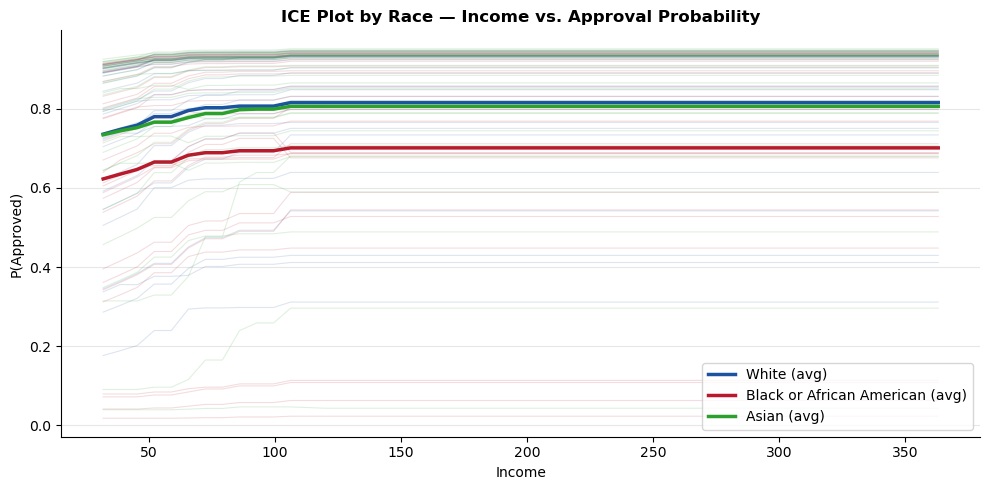

In [58]:
race_groups = ['White', 'Black or African American', 'Asian']

colors_race = {
    'White': '#1a53a0',
    'Black or African American': '#B8192C',
    'Asian': '#2ca02c'
}

income_grid = np.linspace(
    X_test_sample['income'].quantile(0.05),
    X_test_sample['income'].quantile(0.95),
    50
)

# --- ICE ---
fig, ax = plt.subplots(figsize=(10, 5))

for race in race_groups:

    mask = demo_test_sample['derived_race'] == race
    sample = X_test_sample[mask].sample(
        min(30, mask.sum()), random_state=42
    )
    ice_m = np.vstack([
        model_A_gbt.predict_proba(sample.assign(income=v))[:, 1]
        for v in income_grid
    ]).T

    # individual ICE lines
    for i in range(len(sample)):
        ax.plot(
            income_grid,
            ice_m[i],
            color=colors_race[race],
            alpha=0.15,
            linewidth=0.8
        )

    # average line
    ax.plot(
        income_grid,
        ice_m.mean(axis=0),
        color=colors_race[race],
        linewidth=2.5,
        label=f'{race} (avg)'
    )

ax.set_xlabel('Income')
ax.set_ylabel('P(Approved)')
ax.set_title('ICE Plot by Race — Income vs. Approval Probability', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ice_by_race.png', dpi=150, bbox_inches='tight')

The ICE analysis reveals that approval probability increases with income across all groups, indicating that the model captures the expected economic relationship. However, systematic differences persist across racial groups even when income is held constant. Specifically, Black applicants consistently receive lower predicted approval probabilities compared to White and Asian applicants at similar income levels.

The near-parallel structure of the curves suggests that these **disparities are not driven by income itself, but rather by baseline shifts in model predictions.** This provides strong evidence that **income alone cannot explain the observed differences, and indicates the potential presence of proxy variables** that indirectly encode race-related information within the model.

##### c-ICE

**Centered ICE (C-ICE): Isolating Feature Effects**

While ICE plots show how predictions change as a feature varies for each individual, they may still reflect differences in baseline prediction levels across groups. To address this, we use Centered ICE (C-ICE), which normalizes each individual curve by subtracting its starting value.

This transformation allows us to focus on the *change* in predicted probability rather than the absolute level. As a result, C-ICE helps isolate how the model responds to variations in a specific feature (e.g., income), independent of initial differences between individuals or groups.

This distinction is important for identifying whether disparities arise from feature effects or from underlying structural differences in model predictions.

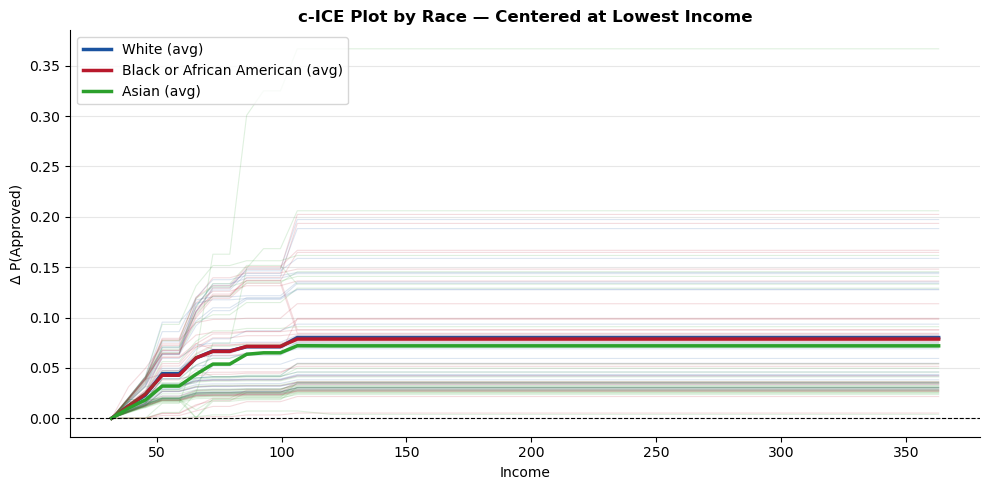

In [69]:
# --- c-ICE ---
fig, ax = plt.subplots(figsize=(10, 5))
for race in race_groups:
    mask   = demo_test_sample['derived_race'] == race
    sample = X_test_sample[mask].sample(min(30, mask.sum()), random_state=42)
    ice_m  = np.vstack([model_A_gbt.predict_proba(sample.assign(income=v))[:,1]
                        for v in income_grid]).T
    centered = ice_m - ice_m[:, 0:1]

    for i in range(len(sample)):
        ax.plot(income_grid, centered[i], color=colors_race[race], alpha=0.15, linewidth=0.8)
    ax.plot(income_grid, centered.mean(axis=0),
            color=colors_race[race], linewidth=2.5, label=f'{race} (avg)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Income'); ax.set_ylabel('Δ P(Approved)')
ax.set_title('c-ICE Plot by Race — Centered at Lowest Income', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cice_by_race.png', dpi=150, bbox_inches='tight')
plt.show()



This centered ICE (C-ICE) plot shows how the predicted approval probability changes as **income increases**, after removing each individual’s baseline level. In other words, it focuses on the *effect of income itself*, rather than absolute differences across applicants.

From the plot, we observe that:
- As income increases, the approval probability consistently increases for all groups.
- The curves for different racial groups largely overlap, indicating that the **model responds to income in a similar way across races**.
- There is no clear divergence in slopes between groups, suggesting that **income does not create unequal treatment across races**.

Overall, this implies that while disparities may exist in overall approval levels, they are **not driven by differences in how income is used by the model**. Instead, any remaining differences are more likely due to baseline effects or other features that may act as proxies for race.

##### d-ICE 

The purpose of d-ICE is to observe whether the disparity between different ethnic groups changes with income. In other words, we don't just look at the individual predictions for each ethnic group, but directly examine whether the disparity between them increases, decreases, or remains constant at different income levels. If the disparity remains relatively small, it means that income has the same impact on all ethnic groups, and the disparity is likely due to other factors. However, if the disparity changes with income, it means that the model treats different ethnic groups differently at different income levels, which could be a potential source of bias.

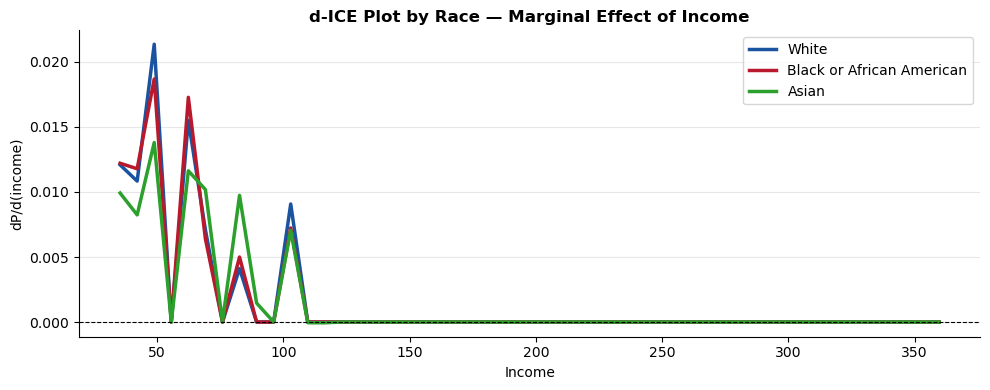

In [70]:
# --- d-ICE ---
fig, ax = plt.subplots(figsize=(10, 4))
income_mid = (income_grid[:-1] + income_grid[1:]) / 2

for race in race_groups:
    mask   = demo_test_sample['derived_race'] == race
    sample = X_test_sample[mask].sample(min(30, mask.sum()), random_state=42)
    ice_m  = np.vstack([model_A_gbt.predict_proba(sample.assign(income=v))[:,1]
                        for v in income_grid]).T
    d_ice  = np.diff(ice_m, axis=1)
    ax.plot(income_mid, d_ice.mean(axis=0),
            color=colors_race[race], linewidth=2.5, label=race)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Income'); ax.set_ylabel('dP/d(income)')
ax.set_title('d-ICE Plot by Race — Marginal Effect of Income', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dice_ice_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

The d-ICE plot shows the marginal effect of income on approval probability across racial groups. At lower income levels, income has a positive effect on predicted approval probability, while at higher income levels the marginal effect diminishes toward zero. Importantly, the curves across racial groups largely overlap, indicating that the model applies income in a consistent manner across groups. This suggests that income does not contribute to disparate treatment, and that observed disparities are more likely driven by baseline differences or other proxy variables.

#### Part 2 — LIME (Local Interpretable Model-Agnostic Explanations)

LIME (Local Interpretable Model-Agnostic Explanations) is used to explain individual predictions made by the model. Instead of providing a global view, LIME focuses on a single applicant and identifies which features contribute most to that specific prediction.

This allows us to understand the relative importance and direction of each feature for that individual. Additionally, this is also particularly useful for detecting hidden biases that may not be visible in aggregate metrics.

We run LIME on the same **White and Black applicants** selected in Step 2.

> If the same feature drives the decision differently for each group → the model relies on different signals per race.

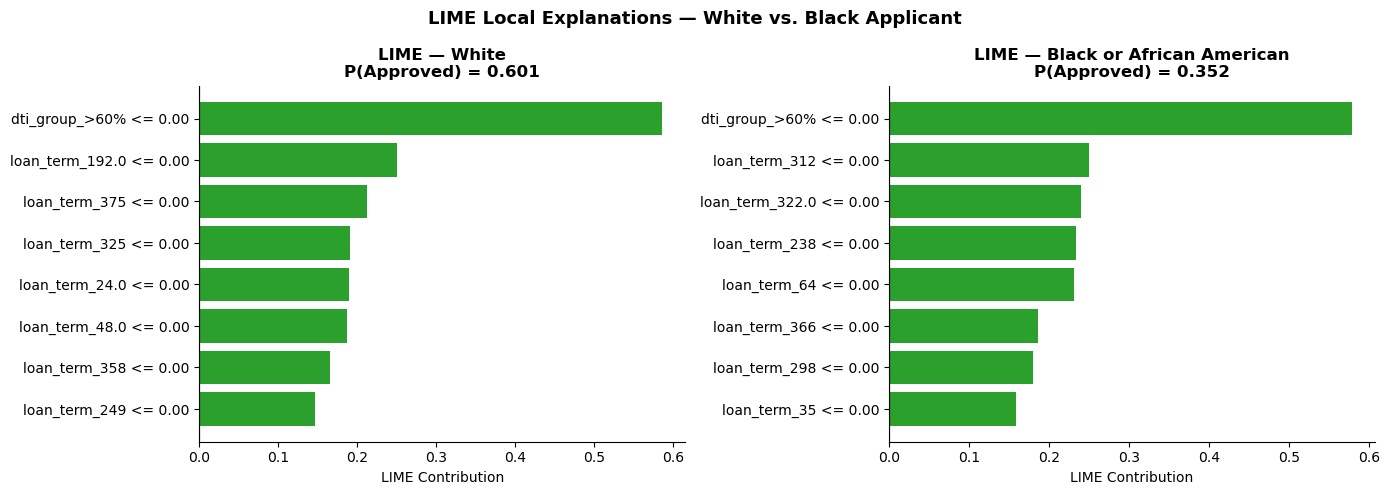

In [93]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = feat_names,
    class_names           = ['Denied', 'Approved'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

lime_results = {}
for label, idx in [('White', white_idx), ('Black or African American', black_idx)]:
    exp = lime_explainer.explain_instance(
        X_test_enc[idx],
        fitted_classifier.predict_proba,
        num_features=10
    )
    lime_results[label] = exp.as_list()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, lime_list) in zip(axes, lime_results.items()):
    idx = white_idx if label == 'White' else black_idx
    feats  = [x[0][:30] for x in lime_list[:8]]
    vals   = [x[1]      for x in lime_list[:8]]
    colors = ['#2ca02c' if v > 0 else '#B8192C' for v in vals]
    ax.barh(feats[::-1], vals[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME — {label}\nP(Approved) = {pred_probs[idx]:.3f}', fontweight='bold')
    ax.set_xlabel('LIME Contribution')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('LIME Local Explanations — White vs. Black Applicant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_white_vs_black.png', dpi=150, bbox_inches='tight')
plt.show()


Because LIME generates synthetic samples around the selected instance, the results may vary slightly across runs. In addition, if different applicants are selected (even within the same group), the explanations will naturally differ. Therefore, variation in LIME outputs is expected and should be interpreted as a property of local, instance-level analysis rather than inconsistency.

In this example, we compare one White applicant and one Black or African American applicant. The predicted approval probabilities differ noticeably (White: 0.601 vs. Black: 0.352), indicating a clear disparity at the individual level.

From the feature contributions, the most influential factor for both applicants is **DTI (debt-to-income ratio)**, particularly the indicator for lower DTI levels (e.g., `dti_group_>60% <= 0.00`). This suggests that the model relies heavily on DTI when making approval decisions.

Although both applicants are influenced by similar key features (mainly DTI), the final predicted outcomes still differ. This implies that the disparity is not driven by completely different features, but rather by how these features interact with other variables or baseline conditions within the model.

Overall, this analysis highlights that:
- LIME explanations are local and may vary across runs or selected individuals
- DTI is the dominant driver of the prediction in both cases
- Despite similar key drivers, individual-level disparities can still exist

#### Part 3 Counterfactual Explanations (DiCE)

DiCE answers: *"What is the minimum change needed to flip this decision?"*

For a denied applicant: what would have to change (income? DTI? property value?) to get approved?

**Key constraint:** Race and sex are **immutable** — only financial variables can change.
This reveals whether the model sets a different financial bar for different racial groups.

In [78]:
import dice_ml
from dice_ml import Dice

# -----------------------------
# Step 1: Create a CLEAN COPY 
# -----------------------------
X_train_dice = X_train_A.copy()
y_train_dice = y_train.copy()

train_df_dice = pd.concat(
    [X_train_dice.reset_index(drop=True),
     y_train_dice.reset_index(drop=True)],
    axis=1
).copy()

# rename target column to "target" for DiCE compatibility
train_df_dice = train_df_dice.rename(columns={train_df_dice.columns[-1]: 'target'})

# -----------------------------
# Step 2: Clean numeric (safe)
# -----------------------------
for col in numeric_features_A:
    train_df_dice[col] = pd.to_numeric(train_df_dice[col], errors='coerce')

# -----------------------------
# Step 3: Clean categorical 
# -----------------------------
for col in categorical_features_A:
    train_df_dice[col] = (
        train_df_dice[col]
        .fillna("Missing")
        .astype(str)
    )

# -----------------------------
# Step 4: Setup DiCE
# -----------------------------
dice_data = dice_ml.Data(
    dataframe=train_df_dice,
    continuous_features=numeric_features_A,
    outcome_name='target'
)

dice_model = dice_ml.Model(
    model=model_A,
    backend='sklearn',
    model_type='classifier'
)

exp_dice = Dice(dice_data, dice_model, method='random')

print("DiCE ready (isolated version).")

DiCE ready (isolated version).


In [86]:
# -----------------------------
# Select two rejected applicants:
# one White and one Black applicant
# pred_prob between 0.2 and 0.5
# -----------------------------

low, high = 0.2, 0.5

white_candidates = sel[
    (sel["derived_race"] == "White") &
    (sel["pred_prob"].between(low, high))
]

black_candidates = sel[
    (sel["derived_race"] == "Black or African American") &
    (sel["pred_prob"].between(low, high))
]

print("White candidates:", len(white_candidates))
print("Black candidates:", len(black_candidates))

# Select one applicant from each group
white_reject_idx = white_candidates.sample(1, random_state=42).index[0]
black_reject_idx = black_candidates.sample(1, random_state=42).index[0]

# Reset index to align with sel / pred_probs
X_test_sample_dice = X_test_sample.reset_index(drop=True).copy()

# Reasonable range
permitted_range = {
    "income": [
        X_train_A["income"].quantile(0.01),
        X_train_A["income"].quantile(0.99)
    ],
    "combined_loan_to_value_ratio": [
        X_train_A["combined_loan_to_value_ratio"].quantile(0.01),
        X_train_A["combined_loan_to_value_ratio"].quantile(0.99)
    ]
}

# -----------------------------
# Generate counterfactuals
# -----------------------------
for label, idx in [
    ("White", white_reject_idx),
    ("Black or African American", black_reject_idx)
]:
    race = sel.loc[idx, "derived_race"]
    prob = pred_probs[idx]

    print(f"\n=== Rejected applicant ({race}) | pred_prob = {prob:.3f} ===")

    query = X_test_sample_dice.iloc[[idx]].copy()

    # Clean numeric features
    for col in numeric_features_A:
        query[col] = pd.to_numeric(query[col], errors="coerce")
        query[col] = query[col].fillna(X_train_A[col].median())

    # Clean categorical features
    for col in categorical_features_A:
        query[col] = query[col].fillna("Missing").astype(str)

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class=1,
        permitted_range=permitted_range
    )

    cf.visualize_as_dataframe(show_only_changes=True)

White candidates: 1717
Black candidates: 454

=== Rejected applicant (White) | pred_prob = 0.231 ===


100%|██████████| 1/1 [00:04<00:00,  4.52s/it]

Query instance (original outcome : 1)


,income,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,target
0,24.0,30-40%,300,1,1,8,31.389999,78.669998,55000.0,1



Diverse Counterfactual set (new outcome: 1)


...

100%|██████████| 1/1 [00:04<00:00,  4.39s/it]

Query instance (original outcome : 0)


,income,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,target
0,38.0,50-60%,360,2,32,1,80.019997,58.07,305000.0,0



Diverse Counterfactual set (new outcome: 1)


,income,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,target
0,412.1,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,1
2,-,-,138.0,-,-,-,-,-,-,1


**White Applicant — Counterfactual Explanation**

The selected White applicant has a predicted approval probability of 0.231, indicating a clear rejection decision.

The DiCE counterfactual results suggest that approval could be achieved through:
- Reducing the combined loan-to-value (CLTV) ratio
- Improving the debt-to-income (DTI) group
- Adjusting tract-level demographic characteristics (e.g., tract_minority_population_percent)

While the financial changes (CLTV and DTI) are realistic and interpretable, the inclusion of tract_minority_population_percent raises important concerns.

This feature represents the proportion of minority populations in the applicant's residential area and is not directly controllable by the individual. The fact that changing this feature affects the model's decision suggests that the model may rely on geographic or demographic proxies.

This highlights a potential fairness issue, as decisions may be influenced by location-based characteristics rather than purely financial risk.

**Black Applicant — Limited Counterfactual**

For the Black or African American applicant, the counterfactual analysis reveals a highly constrained set of changes required to achieve approval. Unlike the White applicant, whose outcome can be improved through multiple financial adjustments, this applicant appears to have only one effective pathway: modifying the loan term.

Specifically, the model suggests reducing the loan term from 360 months (30 years) to approximately 138 months (around 11.5 years). While shorter loan terms are generally associated with lower risk, this particular value is not commonly observed in real-world lending practices.

This indicates that:
- The model is heavily reliant on a single feature (loan term) for this individual
- Alternative financial improvements (e.g., income or DTI adjustments) are not sufficient to change the prediction

Such a pattern suggests a rigid decision boundary, where approval is only achievable through narrow and potentially unrealistic changes. This contrasts with the White applicant, who has multiple feasible adjustment options, highlighting a disparity in how the model evaluates similar cases across groups.

#### Part 4 Shapely Values (SHAP)

SHAP assigns each feature a contribution score based on cooperative game theory.
We use `shap.TreeExplainer` which is optimized for tree-based models like LightGBM.

| Level | Plot | Question |
|---|---|---|
| **Global** | Summary (beeswarm) | Which features matter most overall? |
| **Local** | Waterfall | Why was this specific applicant approved or denied? |
| **Fairness** | Grouped bar | Do different racial groups experience the model differently? |

**SHAP vs. LIME: Key Differences**

SHAP (SHapley Additive exPlanations) provides feature-level contribution values that explain how each feature influences a model’s prediction. Each SHAP value represents how much a feature pushes the prediction above or below a baseline (expected value). Importantly, SHAP values are additive, meaning the sum of all feature contributions equals the final prediction.

In contrast, LIME (Local Interpretable Model-agnostic Explanations) approximates the model locally by fitting a simple surrogate model around a single observation. While LIME is useful for understanding individual predictions, it lacks a consistent theoretical foundation and may produce different results across runs due to its sampling-based nature.

A key distinction is that SHAP can be used for both local and global interpretation, whereas LIME is primarily designed for local explanations. Additionally, SHAP ensures consistency and additivity, making it more reliable for interpreting model behavior.

##### 4a — SHAP(beeswarm)

SHAP values shape: (50000, 902)
X_test_enc shape: (50000, 902)


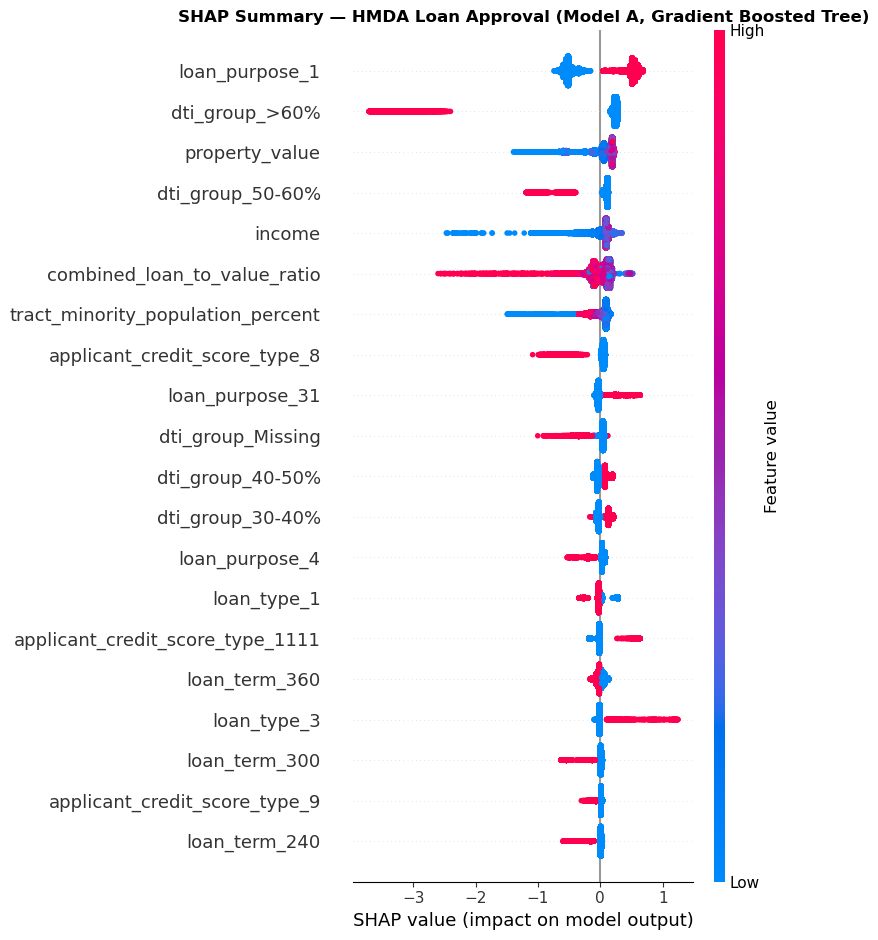

In [88]:
import shap
# SHAP TreeExplainer for Gradient Boosted Tree (Model A)
explainer_shap = shap.TreeExplainer(fitted_classifier)

# Compute SHAP values for encoded test data
shap_values = explainer_shap.shap_values(X_test_enc)

# For binary classification, some SHAP versions return [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Convert encoded test data to DataFrame for safer feature-name alignment
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feat_names)

print(f"SHAP values shape: {shap_values.shape}")
print(f"X_test_enc shape: {X_test_enc_df.shape}")

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_df,
    show=False
)

plt.title(
    "SHAP Summary — HMDA Loan Approval (Model A, Gradient Boosted Tree)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

**Key Drivers of Loan Approval**

The model primarily relies on **Debt-to-Income (DTI) ratio, income, loan purpose, and property value** to evaluate an applicant’s financial strength and repayment capacity. In addition, **Loan-to-Value (LTV) ratio** and **tract minority population percentage (TMPP)** also play a meaningful role in influencing predictions.

- **Debt-to-Income (DTI) Ratio**
DTI reflects how much of a borrower’s income is used to repay debt. In practice, a higher DTI indicates greater financial burden. The results show that higher DTI (especially >60%) significantly reduces approval probability, while lower DTI increases the likelihood of approval.

- **Income**  
Income represents the borrower’s repayment ability. Higher income generally signals stronger financial stability. The model shows that higher income increases approval probability, while lower income decreases it.

- **Loan Purpose**  
Loan purpose indicates why the applicant is borrowing money. Different purposes carry different risk levels in practice. The results suggest that some loan purposes are more likely to be approved, while others are penalized, reflecting varying perceived risks.

- **Property Value**  
Property value represents the asset backing the loan. Higher property values indicate stronger collateral. The model shows that higher property values increase approval probability, while lower values reduce it.

- **Loan-to-Value (LTV) Ratio** 
LTV measures how much is borrowed relative to the property value. A higher LTV means the borrower is taking on more risk. The results show that higher LTV strongly decreases approval probability, while lower LTV increases it.

- **Tract Minority Population Percentage (TMPP)**  
TMPP reflects the demographic composition of the applicant’s area. While not a direct financial variable, it may capture location-related socioeconomic patterns. The results indicate that higher TMPP is associated with lower approval probability, suggesting potential fairness concerns.

##### 4b — Waterfall: White vs. Black Applicant

Demonstrating how SHAP provides a transparent breakdown of model decisions at the individual level.

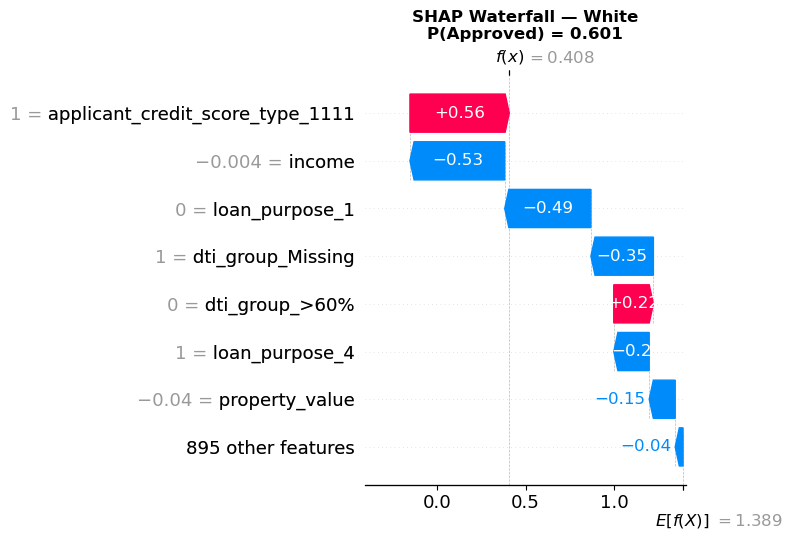

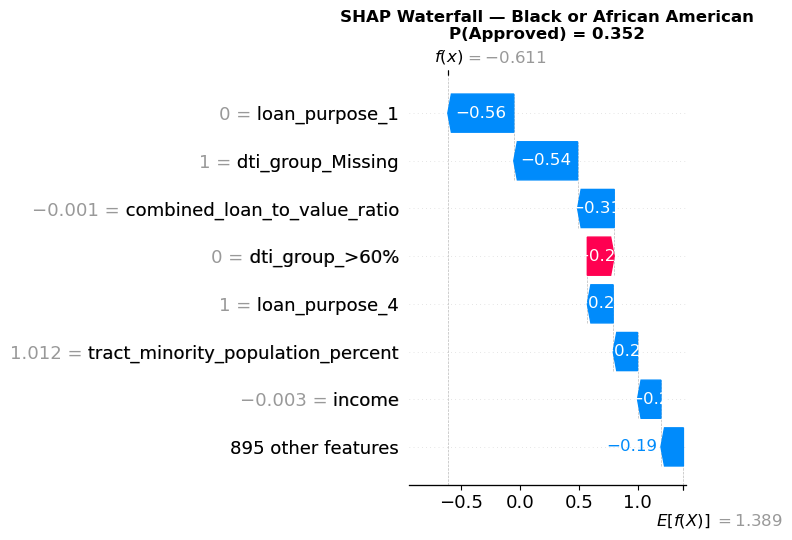

In [91]:
base_value = float(np.array(explainer_shap.expected_value).flatten()[0])

for label, idx in [
    ("White", white_idx),
    ("Black or African American", black_idx)
]:
    plt.figure(figsize=(9, 5))

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=base_value,
            data=X_test_enc[idx],
            feature_names=feat_names
        ),
        max_display=8,
        show=False
    )

    plt.title(
        f"SHAP Waterfall — {label}\nP(Approved) = {pred_probs[idx]:.3f}",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{label.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretation: White Applicant (Approved, 0.601)**

For the White applicant, the prediction is slightly above the approval threshold.

- The most important positive factor is:
  - **Applicant credit score type (+0.56)**  
    → Indicates strong creditworthiness, significantly increasing approval likelihood.

- However, several features push the prediction downward:
  - **Income (-0.53)** → Lower income reduces repayment capacity.
  - **Loan purpose (-0.49)** → Certain loan purposes are considered higher risk.
  - **Missing DTI (-0.35)** → Lack of financial transparency increases uncertainty.

👉 **Overall interpretation:**  
Although the applicant has some financial weaknesses, the strong credit signal outweighs the negative factors, leading to a marginal approval.

**Interpretation: Black Applicant (Rejected, 0.352)**

For the Black applicant, the prediction falls below the approval threshold.

- Major negative contributors include:
  - **Loan purpose (-0.56)** → Strong indication of higher perceived risk.
  - **Missing DTI (-0.54)** → Financial uncertainty heavily penalized.
  - **Loan-to-Value ratio (-0.31)** → Higher leverage increases risk.
  - **Income (-0.20)** → Lower income reduces repayment ability.
  - **Tract minority population percentage (-0.20)** → Contextual (location-based) factor contributing negatively.

- Only minor positive contribution:
  - **DTI > 60% (+0.2)** → Slight positive signal but insufficient to offset risks.

👉 **Overall interpretation:**  
The applicant lacks strong positive financial indicators, and multiple risk-related features collectively push the prediction toward rejection.

##### 4c — Fairness: Mean SHAP by Race

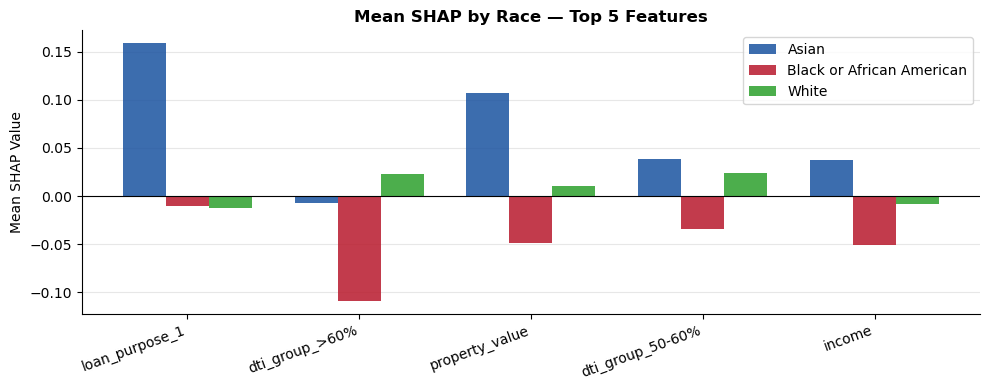

In [92]:
top5 = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)\
         .sort_values(ascending=False).head(5).index.tolist()

shap_df = pd.DataFrame(shap_values, columns=feat_names)
shap_df['derived_race'] = demo_test_sample['derived_race'].values  # aligned with 10K sample

race_shap = shap_df[shap_df['derived_race'].isin(race_groups)]\
              .groupby('derived_race')[top5].mean()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(top5))
for i, (race, row) in enumerate(race_shap.iterrows()):
    ax.bar(x + i*0.25, row[top5], 0.25,
           label=race, color=list(colors_race.values())[i], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 0.25)
ax.set_xticklabels(top5, rotation=20, ha='right')
ax.set_ylabel('Mean SHAP Value')
ax.set_title('Mean SHAP by Race — Top 5 Features', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('shap_fairness_race.png', dpi=150, bbox_inches='tight')
plt.show()

**Group-Level Differences in Feature Contributions**

The mean SHAP values reveal notable differences in how key financial features influence predictions across racial groups.

For the debt-to-income ratio (DTI > 60%), the effect is strongly negative for Black applicants, indicating that high debt levels significantly decrease approval likelihood within this group. In contrast, the effect is weak or slightly positive for White applicants, suggesting that high DTI may be offset by other favorable conditions in that group.

Similarly, property value exhibits opposite patterns: it contributes positively for Asian and White applicants, but negatively for Black applicants. This suggests that higher property values may be associated with different financial contexts across groups, such as varying loan structures or leverage levels.

Income also shows a surprising pattern, where it has a slightly negative average effect for Black applicants. This indicates that income alone may not be sufficient to improve approval outcomes if accompanied by other risk factors such as high debt or unfavorable loan characteristics.

Overall, these differences highlight that feature effects are not uniform across groups, and are likely driven by interactions with other variables and underlying data distributions rather than direct causal relationships.

#### Conclusion for transparency


By combining multiple transparency tools (ICE / d-ICE, LIME, DiCE, and SHAP), we obtain a consistent and multi-level understanding of how the model makes decisions:

- **ICE / d-ICE (global & marginal behavior)** show that **income** generally increases approval probability, but the magnitude of this effect varies across racial groups. This suggests heterogeneous model responsiveness rather than a uniform decision rule.

- **LIME (local explanations)** reveals that for individual applicants, key drivers of decisions include **DTI (debt-to-income ratio)**, **income**, and **loan-related attributes** (e.g., loan purpose, loan term). Importantly, similar profiles across racial groups can still yield different feature contributions.

- **DiCE (counterfactual analysis)** indicates that the changes required to flip a decision (e.g., from denial to approval) often involve adjustments in **DTI, income, or loan conditions**, and that the magnitude of required changes may differ across groups, suggesting a potentially uneven decision boundary.

- **SHAP (global + local attribution)** confirms that the most influential features overall include:
  - **DTI (especially high DTI groups)**
  - **Income**
  - **Loan purpose**
  - **Property value**
  
  In addition, features such as:
  - **Loan-to-Value (LTV) ratio**
  - **Tract minority population percentage (TMPP)**  
  also contribute non-negligibly to predictions and exhibit differences across racial groups.

---

**Key Insight: Important Features and Potential Proxy Signals**

Across all methods, the model consistently relies on financial capacity indicators (e.g., **DTI, income**) and loan characteristics. These are expected and economically meaningful drivers.

However, we also observe that certain features—particularly:
- **Tract minority population percentage (TMPP)**
- **Property value**
- **Loan-to-Value (LTV) ratio**
- **Loan purpose**

While these variables are not explicitly protected attributes, their influence patterns across groups suggest they **may act as potential proxy variables**, indirectly encoding sensitive information.

---

**Important Caveat and Next Step (Fairness Analysis)**

It is important to emphasize that:
- These observations are **not sufficient to conclude discrimination**
- SHAP and other explainability tools reveal **patterns**, not **causal relationships**

Therefore, these findings should be treated as **signals of potential fairness risk**, rather than definitive evidence.

👉 A dedicated **fairness analysis step** (e.g., group metrics such as FPR/FNR parity, AIR, or counterfactual fairness tests) is required to:
- Validate whether these features lead to **systematic disparities**
- Distinguish between **legitimate risk factors** and **unjustified bias**

---

**Summary**

Overall, transparency tools highlight that:
- The model relies heavily on financial and loan-related features
- Some features exhibit group-dependent effects
- Certain variables may function as **potential proxies**

These insights motivate a deeper fairness evaluation to ensure that model decisions are both **accurate and equitable**.

---
# Part 3 — Fairness Evaluation (Lecture 3)
**Member: Shanif**

This section performs a comprehensive fairness analysis of Model A (fairness-aware, excludes race) using the test set. We examine disparities across race, sex, and ethnicity, compute standard fairness metrics, and analyze subgroup intersections.

**Models used:**
- `model_A` — Logistic Regression, excludes race
- `model_A_gbt` — Gradient Boosted Tree, excludes race

**Features in Model A:**
- Numeric: `income`, `tract_minority_population_percent`, `combined_loan_to_value_ratio`, `property_value`
- Categorical: `dti_group`, `loan_term`, `loan_type`, `loan_purpose`, `applicant_credit_score_type`

#### Step 1: Rebuild the Full Results Table



We generate predictions from both Model A variants (Decision Tree and GBT) and attach the demographic columns (`derived_race`, `derived_sex`, `derived_ethnicity`) from the original dataframe. These columns were not used as model features but are needed for fairness analysis.

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Predictions from both Model A variants ---
pred_A_tree = model_A_tree.predict(X_test_A)   # Decision Tree
pred_A_gbt  = model_A_gbt.predict(X_test_A)    # Gradient Boosting Tree

# --- Build results table ---
results = pd.DataFrame(index=X_test_A.index)
results["y_true"]      = y_test.values
results["y_pred_tree"] = pred_A_tree
results["y_pred_gbt"]  = pred_A_gbt

# --- Add probability scores (for calibration & Brier) ---
results["score_tree"] = model_A_tree.predict_proba(X_test_A)[:, 1]
results["score_gbt"]  = model_A_gbt.predict_proba(X_test_A)[:, 1]

# --- Attach demographic columns (not used as features) ---
results["race"]      = df.loc[X_test_A.index, "derived_race"].astype("string")
results["sex"]       = df.loc[X_test_A.index, "derived_sex"].astype("string")
results["ethnicity"] = df.loc[X_test_A.index, "derived_ethnicity"].astype("string")

# --- Attach proxy feature ---
results["tract_minority_pct"] = df.loc[
    X_test_A.index, "tract_minority_population_percent"
]

# --- Basic sanity check ---
print(f"Test set size: {len(results):,} rows")

print("\nRace value counts:")
print(results["race"].value_counts())

print("\nSex value counts:")
print(results["sex"].value_counts())

print("\nEthnicity value counts:")
print(results["ethnicity"].value_counts())

Test set size: 1,732,348 rows

Race value counts:
race
White                                        1111212
Race Not Available                            304705
Black or African American                     152109
Asian                                         104588
Joint                                          38136
American Indian or Alaska Native               12619
2 or more minority races                        4304
Native Hawaiian or Other Pacific Islander       4247
Free Form Text Only                              428
Name: count, dtype: Int64

Sex value counts:
sex
Joint                601020
Male                 587079
Female               389966
Sex Not Available    154283
Name: count, dtype: Int64

Ethnicity value counts:
ethnicity
Not Hispanic or Latino     1194110
Ethnicity Not Available     281298
Hispanic or Latino          211520
Joint                        44713
Free Form Text Only            707
Name: count, dtype: Int64


#### Step 2: Helper Function for Fairness Metrics

We define a reusable function that computes the following metrics for any group:
- **FPR (False Positive Rate):** Among denied applicants, how many were incorrectly predicted as approved?
- **FNR (False Negative Rate):** Among approved applicants, how many were incorrectly predicted as denied? High FNR = model is under-approving that group.
- **Accuracy:** Overall correctness for the group.
- **Predicted Approval Rate:** Fraction the model predicts as approved.
- **Actual Approval Rate:** Fraction actually approved in the data.

In [95]:
def compute_fairness_metrics(group, pred_col="y_pred_lr"):
    """Compute FPR, FNR, Accuracy, and approval rates for a group."""
    if len(group) < 10:
        return None
    try:
        tn, fp, fn, tp = confusion_matrix(
            group["y_true"], group[pred_col], labels=[0, 1]
        ).ravel()
    except ValueError:
        return None

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)

    return pd.Series({
        "N": len(group),
        "Actual_Approval_Rate":    round(group["y_true"].mean(), 4),
        "Pred_Approval_Rate":      round(group[pred_col].mean(), 4),
        "FPR":      round(fpr, 4),
        "FNR":      round(fnr, 4),
        "Accuracy": round(acc, 4)
    })

print("Helper function defined.")

Helper function defined.


#### Step 3: Fairness by Race — DT vs GBT

In [140]:
# -----------------------------
# Compute metrics by race for DT vs GBT
# -----------------------------

fairness_race_tree = (
    results.groupby("race", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_tree"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_race_gbt = (
    results.groupby("race", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

# -----------------------------
# Display results
# -----------------------------

print("=== Fairness by Race — Decision Tree (Model A) ===")
display(fairness_race_tree)

print("\n=== Fairness by Race — Gradient Boosted Tree (Model A) ===")
display(fairness_race_gbt)

=== Fairness by Race — Decision Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
race,,,,,,
Native Hawaiian or Other Pacific Islander,4247.0,0.6000,0.7794,0.5285,0.0534,0.7565
American Indian or Alaska Native,12619.0,0.6326,0.8089,0.5427,0.0366,0.7775
Black or African American,152109.0,0.6334,0.8230,0.5791,0.0359,0.7650
2 or more minority races,4304.0,0.6162,0.8120,0.5672,0.0354,0.7605
White,1111212.0,0.7819,0.8899,0.5983,0.0288,0.8470
Free Form Text Only,428.0,0.3715,0.6449,0.4498,0.0252,0.7079
Joint,38136.0,0.8034,0.9057,0.6198,0.0244,0.8585
Race Not Available,304705.0,0.7229,0.8911,0.6698,0.0241,0.7970
Asian,104588.0,0.7862,0.8842,0.5447,0.0234,0.8651



=== Fairness by Race — Gradient Boosted Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
race,,,,,,
Native Hawaiian or Other Pacific Islander,4247.0,0.6000,0.7509,0.4562,0.0526,0.7860
Black or African American,152109.0,0.6334,0.7849,0.4964,0.0482,0.7875
2 or more minority races,4304.0,0.6162,0.7772,0.4831,0.0396,0.7902
American Indian or Alaska Native,12619.0,0.6326,0.7793,0.4674,0.0396,0.8032
Free Form Text Only,428.0,0.3715,0.5888,0.3680,0.0377,0.7547
Race Not Available,304705.0,0.7229,0.8579,0.5643,0.0296,0.8222
White,1111212.0,0.7819,0.8796,0.5496,0.0283,0.8580
Asian,104588.0,0.7862,0.8778,0.5079,0.0215,0.8745
Joint,38136.0,0.8034,0.9039,0.5926,0.0199,0.8675


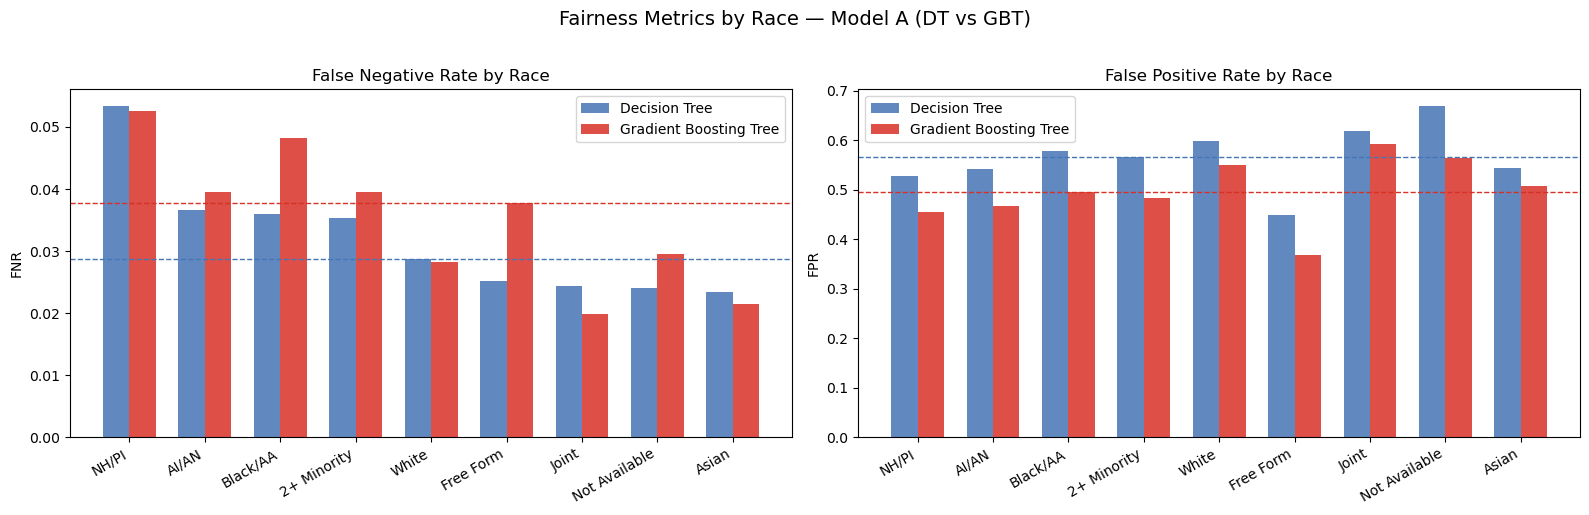

In [142]:
# Shorten long race labels for charts
short_labels = {
    "American Indian or Alaska Native": "AI/AN",
    "Black or African American": "Black/AA",
    "Native Hawaiian or Other Pacific Islander": "NH/PI",
    "2 or more minority races": "2+ Minority",
    "Free Form Text Only": "Free Form",
    "Race Not Available": "Not Available"
}

# --- Side-by-side FNR comparison: LR vs GBT ---
common_races = fairness_race_tree.index.intersection(fairness_race_gbt.index)
labels = [short_labels.get(r, r) for r in common_races]

x = np.arange(len(common_races))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(axes, ["FNR", "FPR"], ["False Negative Rate", "False Positive Rate"]):
    tree_vals = fairness_race_tree.loc[common_races, metric]
    gbt_vals = fairness_race_gbt.loc[common_races, metric]
    ax.bar(x - width/2, tree_vals,  width, label="Decision Tree", color="#4575b4", alpha=0.85)
    ax.bar(x + width/2, gbt_vals, width, label="Gradient Boosting Tree",                 color="#d73027", alpha=0.85)
    ax.axhline(tree_vals.median(),  color="#4575b4", linestyle="--", linewidth=1)
    ax.axhline(gbt_vals.median(), color="#d73027", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{title} by Race", fontsize=12)
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Fairness Metrics by Race — Model A (DT vs GBT)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Fairness Visualization Interpretation (FNR & FPR by Race — DT vs GBT)**

**1. Disparity Across Racial Groups**

From both the FNR and FPR plots, we observe clear **disparities across racial groups** under both Decision Tree (DT) and Gradient Boosting Tree (GBT):

- Error rates vary noticeably across groups rather than clustering tightly around a common value.
- In the FNR plot, some groups (e.g., NH/PI, Black/AA) have visibly higher false negative rates.
- In the FPR plot, groups such as “Not Available”, “Joint”, and “White” exhibit higher false positive rates.

👉 This indicates that model errors are **systematically uneven across groups**, rather than random noise, suggesting persistent fairness concerns.

---

**2. GBT vs Decision Tree Performance**

Comparing the two models:

- **GBT (red bars)** generally achieves **lower FPR across most groups**, indicating fewer incorrect approvals.
- However, for **FNR**, GBT is **not uniformly better** — in several groups (e.g., Black/AA, AI/AN, Free Form), GBT actually shows **higher FNR than DT**.
  
👉 This suggests:
- GBT improves **overall precision (lower FPR)**  
- But may introduce a trade-off by **increasing false denials (higher FNR) for certain groups**

⚠️ Therefore, GBT is **not strictly better in fairness terms**, but reflects a **performance–fairness trade-off**.

---

**3. Groups with Worse FNR and FPR Performance**

**Higher FNR (more likely to be wrongly denied):**
- **Native Hawaiian / Pacific Islander (NH/PI)** — highest across both models
- **Black or African American** — consistently above average
- **AI/AN and 2+ Minority groups** — moderately elevated

👉 These groups are more likely to be **denied despite being qualified**, indicating potential under-approval bias.

---

**Higher FPR (more likely to be wrongly approved):**
- **Joint**
- **White**

👉 These groups are more likely to be **approved despite being unqualified**, indicating comparatively looser decision thresholds.

---

**4. Overall Insight**

- Both models exhibit **systematic group-level disparities in error rates**
- DT tends to have **higher FPR but slightly more balanced FNR**
- GBT reduces **false approvals (FPR)** but can **increase false denials (FNR)** for certain groups

👉 This highlights an important takeaway:

> Improving model performance (e.g., lowering FPR) does **not necessarily improve fairness**,  
> and may shift the burden of error across different groups.

---

**Conclusion**

The results confirm that:
- Disparities persist across models and are **not model-specific**
- Error trade-offs differ by model choice
- Fairness evaluation must consider **both FPR and FNR simultaneously**, rather than relying on a single metric

#### Step 4: Fairness by Sex - DT 

In [143]:
fairness_sex_tree = (
    results.groupby("sex", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_tree"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_sex_gbt = (
    results.groupby("sex", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("=== Fairness by Sex — Decision Tree (Model A) ===")
display(fairness_sex_tree)
print("\n=== Fairness by Sex — Gradient Boosting Tree (Model A) ===")
display(fairness_sex_gbt)

=== Fairness by Sex — Decision Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
sex,,,,,,
Female,389966.0,0.7077,0.8440,0.5483,0.0338,0.8158
Male,587079.0,0.7357,0.8741,0.6063,0.0297,0.8179
Joint,601020.0,0.8162,0.9093,0.6192,0.0254,0.8655
Sex Not Available,154283.0,0.7339,0.9141,0.7348,0.0210,0.7891



=== Fairness by Sex — Gradient Boosting Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
sex,,,,,,
Female,389966.0,0.7077,0.8169,0.4718,0.0406,0.8333
Male,587079.0,0.7357,0.8555,0.5418,0.0318,0.8334
Sex Not Available,154283.0,0.7339,0.8747,0.6021,0.0265,0.8203
Joint,601020.0,0.8162,0.9074,0.5937,0.0219,0.8730


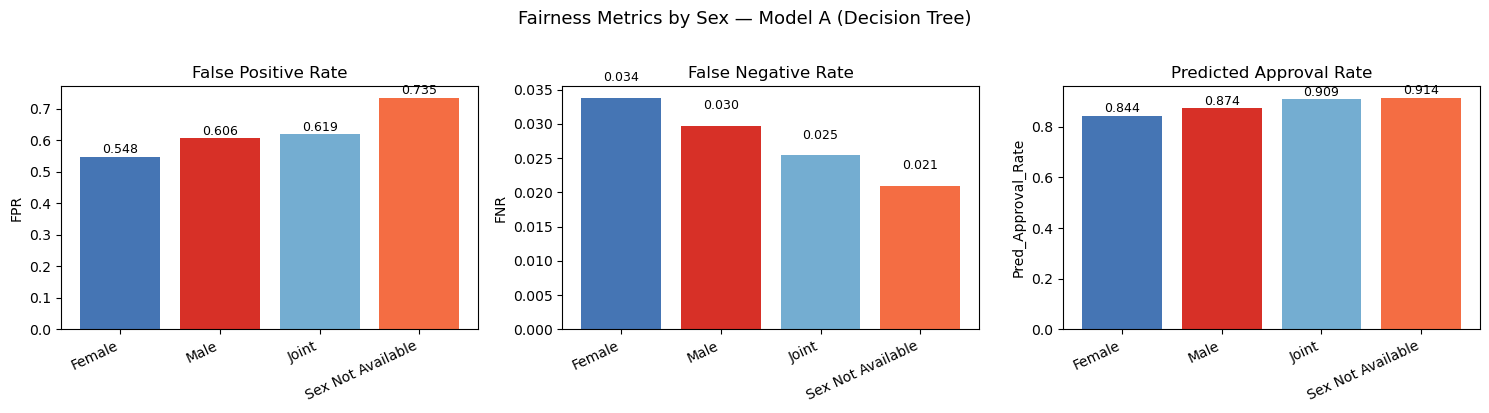

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ["FPR", "FNR", "Pred_Approval_Rate"]
titles  = ["False Positive Rate", "False Negative Rate", "Predicted Approval Rate"]
palette = ["#4575b4", "#d73027", "#74add1", "#f46d43", "#abd9e9"]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(fairness_sex_tree.index, fairness_sex_tree[metric],
                  color=palette[:len(fairness_sex_tree)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(fairness_sex_tree.index, rotation=25, ha="right")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Fairness Metrics by Sex — Model A (Decision Tree)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Fairness by Sex: Limited Evidence of Disparity**

From the visualization of fairness metrics by sex (FPR, FNR, and Predicted Approval Rate), we observe that **disparities across sex groups are relatively small compared to those observed across race**.

- **FPR (False Positive Rate)** varies slightly across groups, but the differences between Female, Male, and Joint applicants are modest and do not indicate a strong systematic bias.
- **FNR (False Negative Rate)** shows a similar pattern, with only minor variation. Female applicants have slightly higher FNR than Male and Joint, but the gap is relatively limited.
- **Predicted Approval Rate** is also fairly consistent across groups, with only a small increase for Joint applications.

👉 Overall, the model appears to treat different sex groups with **no clear or substantial disparity in error distribution**.

However, it is important to note that:
- The "Sex Not Available" group shows somewhat higher error rates, which may reflect **data quality or missingness issues** rather than true demographic bias.

---

**Key Takeaway**

Compared to race-based analysis, **sex does not appear to be a major source of disparity in this model**. The relatively stable FPR, FNR, and approval rates across groups suggest that the model's behavior is **more consistent and balanced with respect to sex**.

That said, minor differences still exist, and further validation may be needed to confirm whether these variations are statistically or practically significant.

#### Step 5: Fairness by Ethnicity - GBT 

In [145]:
fairness_eth_tree = (
    results.groupby("ethnicity", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_tree"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_eth_gbt = (
    results.groupby("ethnicity", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("=== Fairness by Ethnicity — Decision Tree (Model A) ===")
display(fairness_eth_tree)
print("\n=== Fairness by Ethnicity — Gradient Boosting Tree (Model A) ===")
display(fairness_eth_gbt)

=== Fairness by Ethnicity — Decision Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
ethnicity,,,,,,
Free Form Text Only,707.0,0.5007,0.7341,0.5127,0.0452,0.7214
Hispanic or Latino,211520.0,0.6948,0.8382,0.5409,0.0312,0.8133
Not Hispanic or Latino,1194110.0,0.7736,0.8877,0.6021,0.0287,0.8415
Joint,44713.0,0.7910,0.8997,0.6146,0.0250,0.8518
Ethnicity Not Available,281298.0,0.7294,0.8951,0.6774,0.0242,0.7991



=== Fairness by Ethnicity — Gradient Boosting Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
ethnicity,,,,,,
Free Form Text Only,707.0,0.5007,0.7001,0.4504,0.0508,0.7496
Hispanic or Latino,211520.0,0.6948,0.8146,0.4773,0.0372,0.8284
Ethnicity Not Available,281298.0,0.7294,0.8626,0.5727,0.0298,0.8233
Not Hispanic or Latino,1194110.0,0.7736,0.8757,0.5482,0.0285,0.8539
Joint,44713.0,0.7910,0.8947,0.5811,0.0224,0.8608


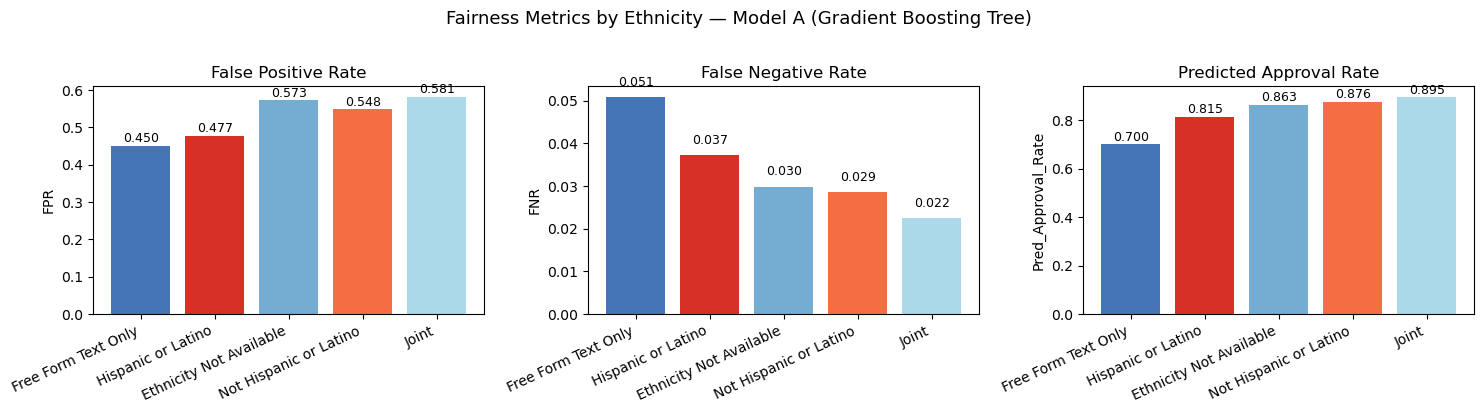

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(fairness_eth_gbt.index, fairness_eth_gbt[metric],
                  color=palette[:len(fairness_eth_gbt)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(fairness_eth_gbt.index, rotation=25, ha="right")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Fairness Metrics by Ethnicity — Model A (Gradient Boosting Tree)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Fairness by Ethnicity**

Compared to sex, the model shows **more noticeable disparity across ethnicity groups**, though still less extreme than race.

- **FPR and FNR vary across groups**, indicating differences in both wrongful approvals and wrongful denials  
- **Predicted approval rates also differ**, suggesting uneven model treatment  

In particular:
- **Hispanic or Latino** has relatively **higher FNR (more denials)** and lower approval rate  
- **Not Hispanic or Latino** tend to have **higher FPR and higher approval rates**

Overall, ethnicity exhibits **moderate disparity**, indicating that model outcomes are not fully consistent across groups.

#### Step 6: Adverse Impact Ratio (AIR) - GBT 



The **Adverse Impact Ratio (AIR)** is a legally grounded fairness metric that compares each group's predicted approval rate to a designated reference group.

$$\text{AIR} = \frac{\text{P}(\hat{Y}=1 \mid \text{group})}{\text{P}(\hat{Y}=1 \mid \text{reference group})}$$

Per the **EEOC 80% Rule**: AIR ≥ 0.80 is required. Groups below this threshold are flagged for **adverse impact** under U.S. anti-discrimination law.

**Key distinctions from DIR:**
- AIR uses a **fixed reference group** (White for race, Male for sex) rather than the best-performing group
- This is the legally recognized standard used by the EEOC and CFPB
- Directly operationalizes **Demographic Parity** as defined in Lecture 03

**Interpretation:**
- AIR = 1.00 → group receives same approval rate as reference
- AIR = 0.80 → group receives 80% of reference group's approval rate (threshold)
- AIR < 0.80 → **adverse impact flagged** — triggers burden-shifting framework

In [147]:
def compute_air(fairness_df, group_label, model_label="GBT"):
    best_rate   = fairness_df["Pred_Approval_Rate"].max()
    best_group  = fairness_df["Pred_Approval_Rate"].idxmax()
    air_df      = fairness_df[["N", "Pred_Approval_Rate", "Actual_Approval_Rate"]].copy()
    air_df["AIR"]            = (air_df["Pred_Approval_Rate"] / best_rate).round(4)
    air_df["Below_80pct_Rule"] = air_df["AIR"] < 0.80
    print(f"\n{'='*58}")
    print(f"  AIR — {group_label} ({model_label})")
    print(f"  Reference group (highest rate): {best_group}")
    print(f"{'='*58}")
    display(air_df.sort_values("AIR"))
    flagged = air_df[air_df["Below_80pct_Rule"]]
    if len(flagged) > 0:
        print(f"  ⚠  {len(flagged)} group(s) below 80% Rule:")
        for g in flagged.index:
            print(f"     {g}: AIR = {flagged.loc[g,'AIR']:.4f}")
    else:
        print("  ✓  All groups above 80% Rule")

compute_air(fairness_race_gbt, "Race",      "GBT")
compute_air(fairness_sex_gbt, "Sex",       "GBT")
compute_air(fairness_eth_gbt, "Ethnicity", "GBT")


  AIR — Race (GBT)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
race,,,,,
Free Form Text Only,428.0,0.5888,0.3715,0.6514,True
Native Hawaiian or Other Pacific Islander,4247.0,0.7509,0.6000,0.8307,False
2 or more minority races,4304.0,0.7772,0.6162,0.8598,False
American Indian or Alaska Native,12619.0,0.7793,0.6326,0.8622,False
Black or African American,152109.0,0.7849,0.6334,0.8683,False
Race Not Available,304705.0,0.8579,0.7229,0.9491,False
Asian,104588.0,0.8778,0.7862,0.9711,False
White,1111212.0,0.8796,0.7819,0.9731,False
Joint,38136.0,0.9039,0.8034,1.0000,False


  ⚠  1 group(s) below 80% Rule:
     Free Form Text Only: AIR = 0.6514

  AIR — Sex (GBT)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
sex,,,,,
Female,389966.0,0.8169,0.7077,0.9003,False
Male,587079.0,0.8555,0.7357,0.9428,False
Sex Not Available,154283.0,0.8747,0.7339,0.9640,False
Joint,601020.0,0.9074,0.8162,1.0000,False


  ✓  All groups above 80% Rule

  AIR — Ethnicity (GBT)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
ethnicity,,,,,
Free Form Text Only,707.0,0.7001,0.5007,0.7825,True
Hispanic or Latino,211520.0,0.8146,0.6948,0.9105,False
Ethnicity Not Available,281298.0,0.8626,0.7294,0.9641,False
Not Hispanic or Latino,1194110.0,0.8757,0.7736,0.9788,False
Joint,44713.0,0.8947,0.7910,1.0000,False


  ⚠  1 group(s) below 80% Rule:
     Free Form Text Only: AIR = 0.7825


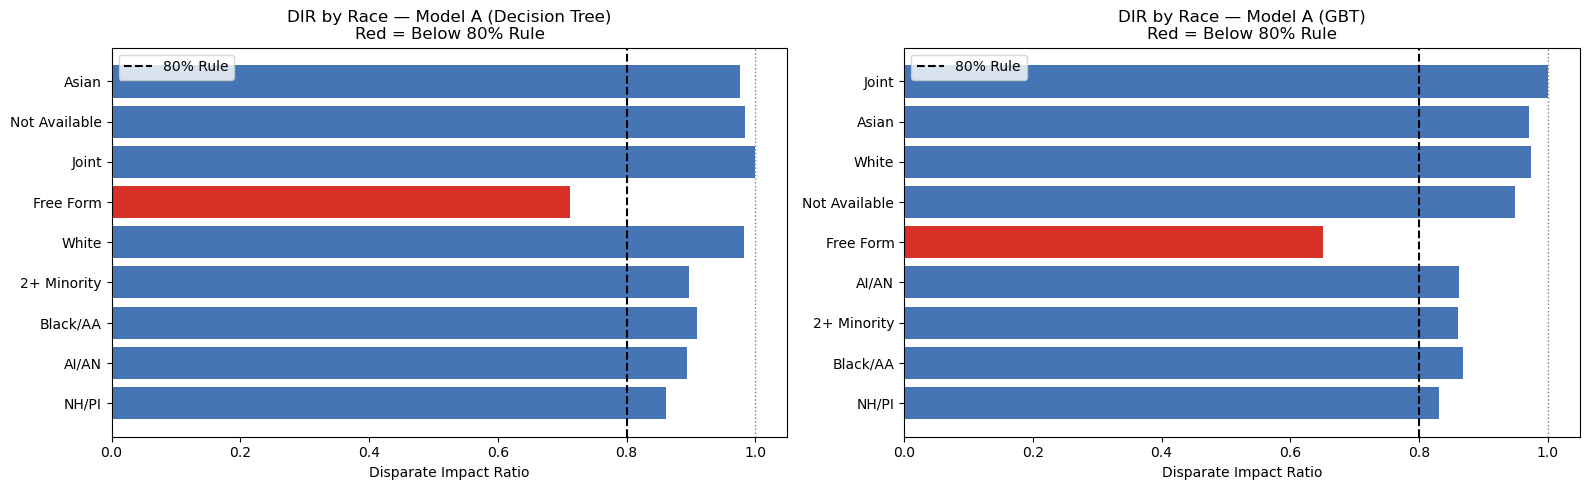

In [148]:
# Visualize DIR by Race for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fairness_df, model_label in zip(
    axes,
    [fairness_race_tree, fairness_race_gbt],
    ["Decision Tree", "GBT"]
):
    best_rate  = fairness_df["Pred_Approval_Rate"].max()
    dir_values = fairness_df["Pred_Approval_Rate"] / best_rate
    short      = [short_labels.get(r, r) for r in fairness_df.index]
    colors     = ["#d73027" if v < 0.80 else "#4575b4" for v in dir_values]

    ax.barh(short, dir_values, color=colors)
    ax.axvline(0.80, color="black", linestyle="--", linewidth=1.5, label="80% Rule")
    ax.axvline(1.00, color="gray",  linestyle=":",  linewidth=1)
    ax.set_xlabel("Disparate Impact Ratio")
    ax.set_title(f"DIR by Race — Model A ({model_label})\nRed = Below 80% Rule", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

**Adverse Impact Ratio (AIR) Analysis**

The AIR results show that most racial groups are above the 0.80 threshold, suggesting that the model does not broadly violate the 80% rule. However, one group, **Free Form Text Only**, falls below the threshold, indicating a potential adverse impact concern that should be flagged for further review.

At the same time, several groups such as **Joint, White, and Asian** have AIR values close to 1.0, meaning their predicted approval rates are relatively close to the highest-approval reference group. This suggests that AIR does not show severe under-selection for most groups, but it also does not prove the model is fully fair.

Overall, AIR should be treated as a basic screening metric rather than a complete fairness conclusion. Since AIR only compares approval rates, additional metrics such as FPR, FNR, ME/Z-tests, and SHAP-based analysis are still needed to understand whether disparities exist in model errors and feature contributions.

#### Step 7: Proxy Variable Check — tract_minority_population_percent

In [104]:
# Bin tract_minority_population_percent into quartiles
results["tract_minority_quartile"] = pd.qcut(
    results["tract_minority_pct"],
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"],
    duplicates="drop"
)

proxy_check = results.groupby("tract_minority_quartile", observed=True).agg(
    N=("y_true", "count"),
    Actual_Approval_Rate=("y_true", "mean"),
    Pred_Approval_Rate_LR=("y_pred_lr", "mean"),
    Pred_Approval_Rate_GBT=("y_pred_gbt", "mean")
).round(4)

print("Approval Rates by Tract Minority Population Quartile")
display(proxy_check)

Approval Rates by Tract Minority Population Quartile


,N,Actual_Approval_Rate,Pred_Approval_Rate_LR,Pred_Approval_Rate_GBT
tract_minority_quartile,,,,
Q1 (Lowest),433089,0.7628,0.8958,0.8639
Q2,433093,0.7880,0.8952,0.8940
Q3,433099,0.7663,0.8791,0.8764
Q4 (Highest),433067,0.7115,0.8340,0.8318


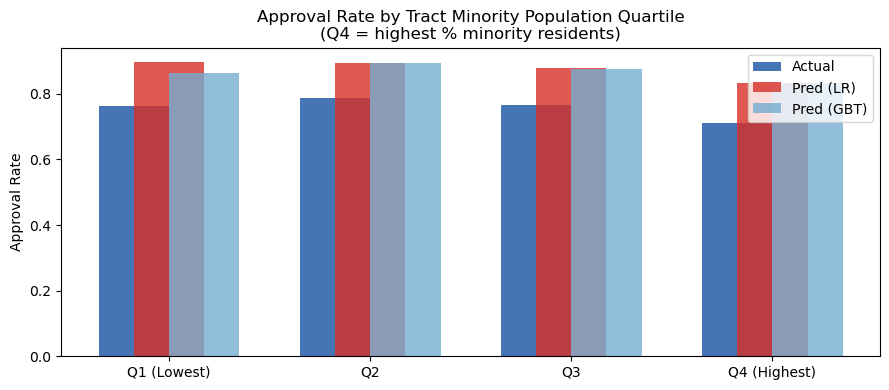

In [105]:
fig, ax = plt.subplots(figsize=(9, 4))
x3 = np.arange(len(proxy_check))

ax.bar(x3 - width/2, proxy_check["Actual_Approval_Rate"],     width, label="Actual",   color="#4575b4")
ax.bar(x3,           proxy_check["Pred_Approval_Rate_LR"],    width, label="Pred (LR)", color="#d73027", alpha=0.8)
ax.bar(x3 + width/2, proxy_check["Pred_Approval_Rate_GBT"],   width, label="Pred (GBT)",color="#74add1", alpha=0.8)

ax.set_xticks(x3)
ax.set_xticklabels(proxy_check.index)
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Tract Minority Population Quartile\n(Q4 = highest % minority residents)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

**Proxy Variable Analysis — Tract Minority Population**

While the decline in approval rates across TMPP quartiles is relatively modest, the pattern is consistent and monotonic across both actual outcomes and model predictions. 

This suggests that the effect is systematic rather than random. Although the magnitude alone may not constitute strong evidence of proxy discrimination, it provides an early signal that the model may be partially relying on geographically correlated information.

Importantly, when combined with SHAP results and group-level fairness disparities (e.g., FPR/FNR gaps), this pattern strengthens the concern that tract minority population percentage may act as a proxy variable. 

Therefore, the observed differences should not be dismissed as negligible, but rather treated as a warning sign that warrants further investigation.

#### Step 8: Proxy Variable Check — loan purpose

Approval Rates by Loan Purpose


,N,Actual_Approval_Rate,Pred_Approval_Rate_LR,Pred_Approval_Rate_GBT
loan_purpose,,,,
1,863548,0.8560,0.9482,0.9298
32,242679,0.6719,0.8100,0.8436
4,226776,0.5774,0.7095,0.7082
2,202912,0.6253,0.7867,0.7629
31,195712,0.7719,0.9245,0.9068
5,721,0.7393,0.9792,0.8558


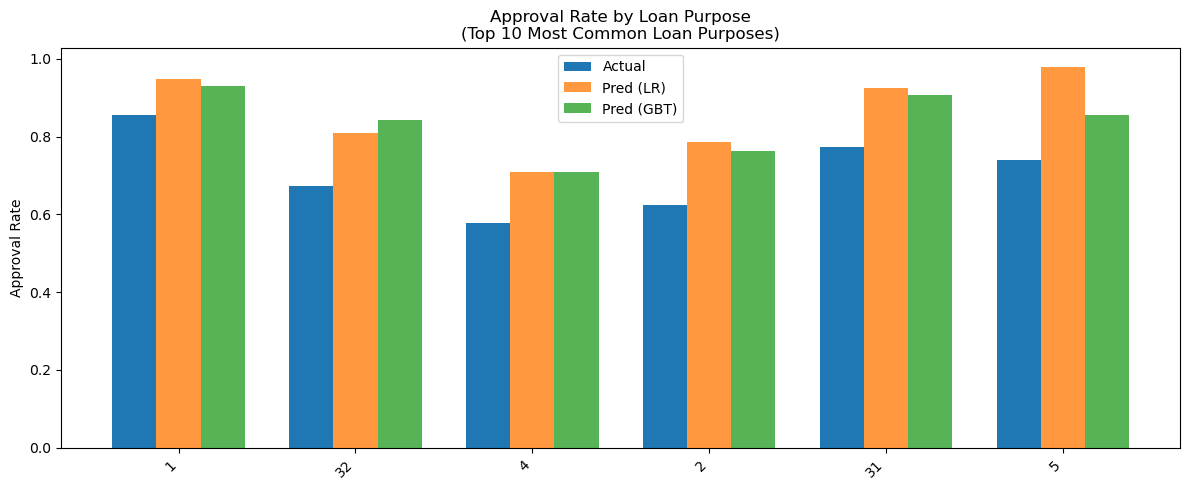

In [110]:
# =====================================================
# Proxy / Pattern Check 2: Loan Purpose
# =====================================================

# Attach loan purpose to results if not already included
results["loan_purpose"] = df.loc[X_test_A.index, "loan_purpose"].astype("string")

loan_purpose_check = results.groupby("loan_purpose", observed=True).agg(
    N=("y_true", "count"),
    Actual_Approval_Rate=("y_true", "mean"),
    Pred_Approval_Rate_LR=("y_pred_lr", "mean"),
    Pred_Approval_Rate_GBT=("y_pred_gbt", "mean")
).round(4)

# Optional: sort by sample size or approval rate
loan_purpose_check = loan_purpose_check.sort_values("N", ascending=False)

print("Approval Rates by Loan Purpose")
display(loan_purpose_check)


# Visualization: show top 10 most common loan purposes
top_loan_purpose = loan_purpose_check.head(10)

fig, ax = plt.subplots(figsize=(12, 5))

width = 0.25
x = np.arange(len(top_loan_purpose))

ax.bar(x - width, top_loan_purpose["Actual_Approval_Rate"], width, label="Actual")
ax.bar(x, top_loan_purpose["Pred_Approval_Rate_LR"], width, label="Pred (LR)", alpha=0.8)
ax.bar(x + width, top_loan_purpose["Pred_Approval_Rate_GBT"], width, label="Pred (GBT)", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(top_loan_purpose.index, rotation=45, ha="right")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Loan Purpose\n(Top 10 Most Common Loan Purposes)")
ax.legend()

plt.tight_layout()
plt.show()

The results for loan purpose suggest that it behaves as a meaningful and economically interpretable feature rather than a pure proxy variable. Approval rates vary systematically across loan purposes, and this pattern is consistent across actual outcomes and model predictions, indicating that the model captures real differences in loan characteristics.

However, while this reduces the likelihood that loan purpose acts as a proxy, it does not fully rule it out. To confirm this, further analysis is needed to examine whether loan purpose is correlated with protected attributes such as race. If certain loan purposes are disproportionately associated with specific groups, proxy effects may still exist.

#### Step 9: Intersection : Race X Sex 

In [149]:
key_races = [
    "White", "Black or African American", "Asian",
    "American Indian or Alaska Native",
    "Native Hawaiian or Other Pacific Islander"
]
key_sexes = ["Male", "Female"]

subset = results[
    results["race"].isin(key_races) &
    results["sex"].isin(key_sexes)
].copy()
subset["subgroup"] = subset["race"] + " / " + subset["sex"]

fairness_sub_gbt = (
    subset.groupby("subgroup")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("Intersectional Fairness: Race × Sex — Model A (GBT)")
display(fairness_sub_gbt)

Intersectional Fairness: Race × Sex — Model A (GBT)


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
subgroup,,,,,,
Native Hawaiian or Other Pacific Islander / Female,1192.0,0.5428,0.6980,0.4257,0.0726,0.7659
Black or African American / Female,62885.0,0.6105,0.7512,0.4488,0.0559,0.7910
Native Hawaiian or Other Pacific Islander / Male,2031.0,0.5963,0.7489,0.4537,0.0512,0.7863
Black or African American / Male,57348.0,0.6318,0.7926,0.5208,0.0490,0.7773
American Indian or Alaska Native / Female,4175.0,0.6129,0.7463,0.4152,0.0445,0.8120
White / Female,255453.0,0.7369,0.8356,0.4824,0.0383,0.8448
American Indian or Alaska Native / Male,6426.0,0.6354,0.7949,0.5032,0.0377,0.7926
White / Male,405057.0,0.7566,0.8685,0.5540,0.0303,0.8422
Asian / Female,24196.0,0.7602,0.8554,0.4789,0.0259,0.8655


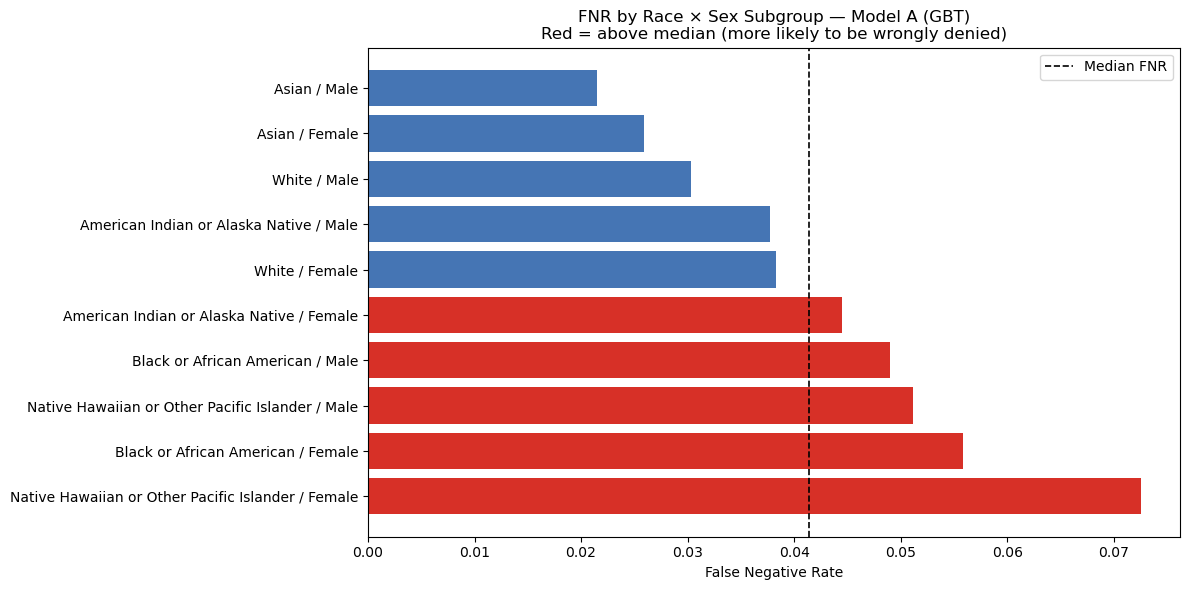

In [150]:
# FNR bar chart by subgroup
fig, ax = plt.subplots(figsize=(12, 6))
fnr_vals   = fairness_sub_gbt["FNR"]
bar_colors = ["#d73027" if v > fnr_vals.median() else "#4575b4" for v in fnr_vals]

ax.barh(fairness_sub_gbt.index, fnr_vals, color=bar_colors)
ax.axvline(fnr_vals.median(), color="black", linestyle="--", linewidth=1.2, label="Median FNR")
ax.set_xlabel("False Negative Rate")
ax.set_title("FNR by Race × Sex Subgroup — Model A (GBT)\nRed = above median (more likely to be wrongly denied)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [151]:
key_races = [
    "White", "Black or African American", "Asian",
    "American Indian or Alaska Native",
    "Native Hawaiian or Other Pacific Islander"
]
key_sexes = ["Male", "Female"]

subset = results[
    results["race"].isin(key_races) &
    results["sex"].isin(key_sexes)
].copy()
subset["subgroup"] = subset["race"] + " / " + subset["sex"]

fairness_sub_tree = (
    subset.groupby("subgroup")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_tree"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("Intersectional Fairness: Race × Sex — Model A (Decision Tree)")
display(fairness_sub_tree)

Intersectional Fairness: Race × Sex — Model A (Decision Tree)


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
subgroup,,,,,,
Native Hawaiian or Other Pacific Islander / Female,1192.0,0.5428,0.7466,0.5248,0.0665,0.7240
Native Hawaiian or Other Pacific Islander / Male,2031.0,0.5963,0.7715,0.5134,0.0537,0.7607
American Indian or Alaska Native / Female,4175.0,0.6129,0.7875,0.5142,0.0399,0.7765
Black or African American / Female,62885.0,0.6105,0.7976,0.5420,0.0394,0.7649
Black or African American / Male,57348.0,0.6318,0.8343,0.6115,0.0358,0.7522
American Indian or Alaska Native / Male,6426.0,0.6354,0.8224,0.5728,0.0343,0.7694
White / Female,255453.0,0.7369,0.8567,0.5495,0.0336,0.8306
White / Male,405057.0,0.7566,0.8828,0.6108,0.0297,0.8289
Asian / Female,24196.0,0.7602,0.8664,0.5239,0.0256,0.8550


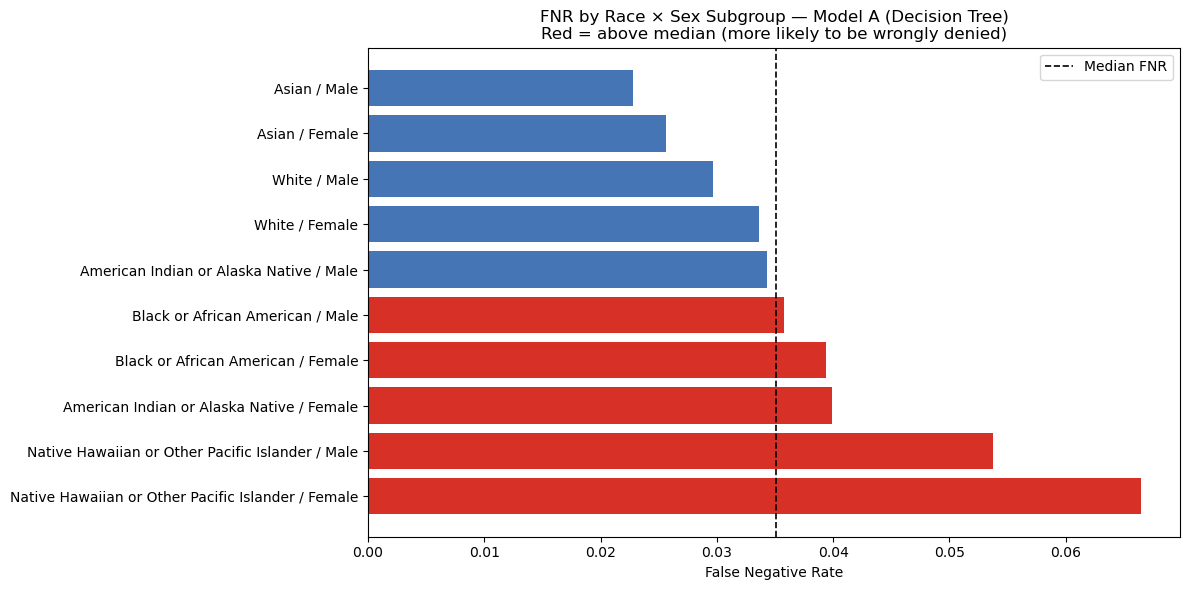

In [152]:
# FNR bar chart by subgroup
fig, ax = plt.subplots(figsize=(12, 6))
fnr_vals   = fairness_sub_tree["FNR"]
bar_colors = ["#d73027" if v > fnr_vals.median() else "#4575b4" for v in fnr_vals]

ax.barh(fairness_sub_tree.index, fnr_vals, color=bar_colors)
ax.axvline(fnr_vals.median(), color="black", linestyle="--", linewidth=1.2, label="Median FNR")
ax.set_xlabel("False Negative Rate")
ax.set_title("FNR by Race × Sex Subgroup — Model A (Decision Tree)\nRed = above median (more likely to be wrongly denied)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

The figure presents the False Negative Rate (FNR) across intersectional subgroups defined by race and sex for the GBT and DT model. The dashed vertical line represents the median FNR, and subgroups highlighted in red indicate those with above-median FNR — meaning they are more likely to be incorrectly denied despite being truly qualified.

Several patterns emerge from this visualization. First, there is clear evidence of disparity across subgroups. In particular, **Native Hawaiian or Other Pacific Islander / Female** and **Black or African American / Female** exhibit the highest FNR values, indicating a disproportionately higher risk of wrongful denial. This suggests that these groups face a higher barrier in the approval process.

Second, intersectional effects are evident. While some racial groups may not appear as disadvantaged when analyzed alone, combining race with sex reveals more pronounced disparities. For example, female applicants within certain minority groups consistently experience higher FNR compared to their male counterparts.

Finally, subgroups such as **Asian / Male** and **White / Male** fall below the median FNR, indicating relatively lower risk of false negatives and thus more favorable outcomes.

Overall, this chart highlights that even with a higher-performing model like GBT, **fairness disparities persist at the intersectional level**, emphasizing the importance of analyzing not only overall metrics but also subgroup-specific error patterns.

##### Performance between GBT & DT

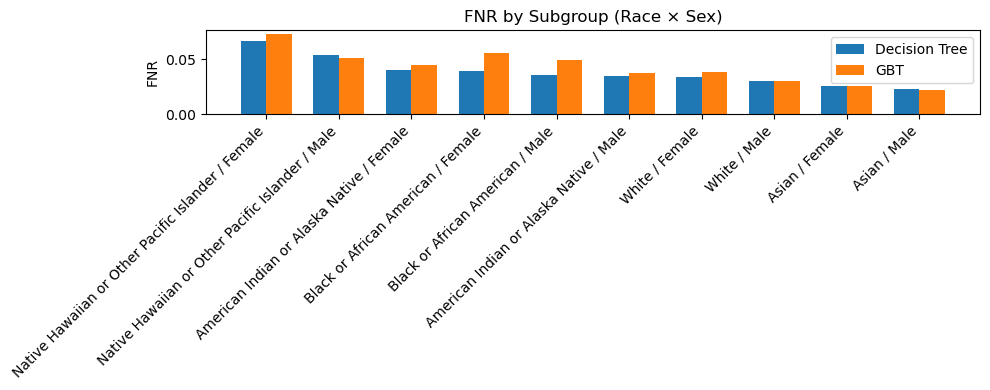

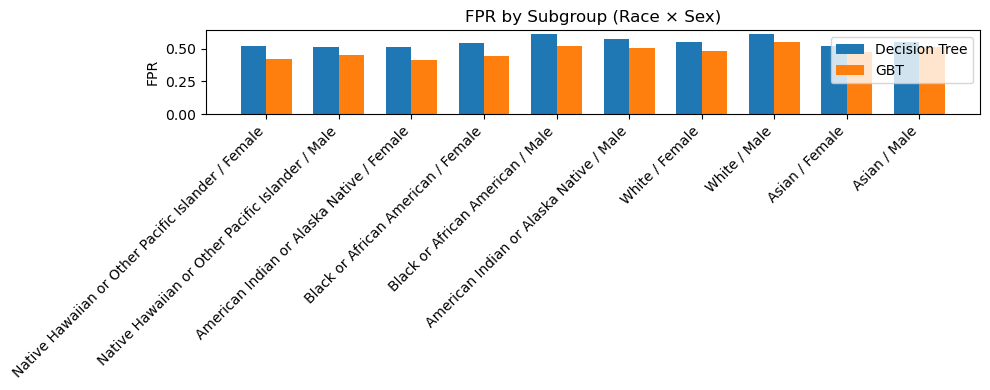

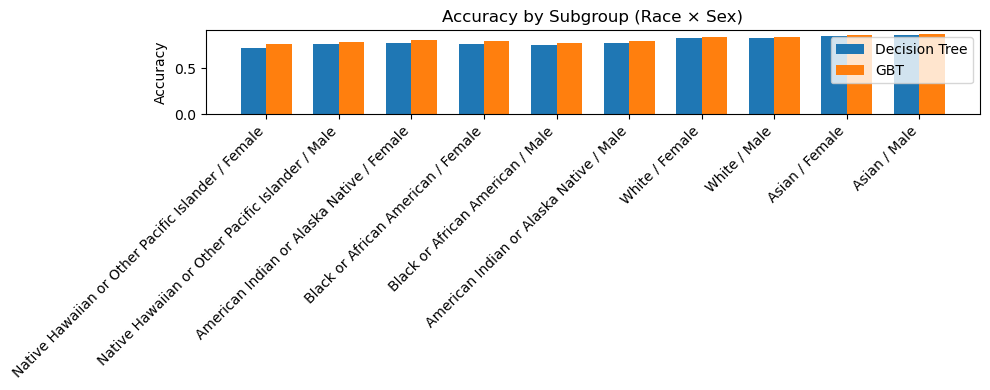

In [153]:
import matplotlib.pyplot as plt
import numpy as np

# merge LR & GBT
compare = fairness_sub_tree[["FPR","FNR"]].rename(columns={
    "FPR":"FPR_Tree","FNR":"FNR_Tree"
}).join(
    fairness_sub_gbt[["FPR","FNR"]].rename(columns={
        "FPR":"FPR_GBT","FNR":"FNR_GBT"
    })
)

compare = compare.reset_index()


compare = compare.head(10)

x = np.arange(len(compare))
width = 0.35

# --- FNR ---
plt.figure(figsize=(10,4))
plt.bar(x - width/2, compare["FNR_Tree"], width, label="Decision Tree")
plt.bar(x + width/2, compare["FNR_GBT"], width, label="GBT")

plt.xticks(x, compare["subgroup"], rotation=45, ha="right")
plt.title("FNR by Subgroup (Race × Sex)")
plt.ylabel("FNR")
plt.legend()
plt.tight_layout()
plt.show()

# --- FPR ---
plt.figure(figsize=(10,4))
plt.bar(x - width/2, compare["FPR_Tree"], width, label="Decision Tree")
plt.bar(x + width/2, compare["FPR_GBT"], width, label="GBT")

plt.xticks(x, compare["subgroup"], rotation=45, ha="right")
plt.title("FPR by Subgroup (Race × Sex)")
plt.ylabel("FPR")
plt.legend()
plt.tight_layout()
plt.show()

# --- Accuracy ---
compare_acc = fairness_sub_tree[["Accuracy"]].rename(columns={
    "Accuracy": "Accuracy_Tree"
}).join(
    fairness_sub_gbt[["Accuracy"]].rename(columns={
        "Accuracy": "Accuracy_GBT"
    })
)

compare_acc = compare_acc.reset_index()
compare_acc = compare_acc.head(10)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(compare_acc))
width = 0.35

plt.figure(figsize=(10,4))

plt.bar(x - width/2, compare_acc["Accuracy_Tree"], width, label="Decision Tree")
plt.bar(x + width/2, compare_acc["Accuracy_GBT"], width, label="GBT")

plt.xticks(x, compare_acc["subgroup"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy by Subgroup (Race × Sex)")
plt.legend()

plt.tight_layout()
plt.show()

Across all race × sex subgroups, the comparison between Decision Tree (DT) and Gradient Boosted Tree (GBT) reveals a more nuanced pattern than before.

From an **accuracy perspective**, GBT still consistently achieves slightly higher accuracy across nearly all subgroups, indicating stronger overall predictive performance.

However, when examining **fairness-related error metrics**, the results show a **clear trade-off**:
- **FNR (False Negative Rate)**: DT is generally **lower** than GBT across most subgroups, meaning DT is less likely to wrongly deny applicants who should have been approved.
- **FPR (False Positive Rate)**: GBT is consistently **lower** than DT, meaning GBT is less likely to wrongly approve applicants who should have been denied.

This implies that:
- DT is relatively **more conservative in rejecting qualified applicants** (better for minimizing missed approvals).
- GBT is relatively **more conservative in granting approvals** (better for controlling incorrect approvals).

Importantly, **disparities across subgroups still persist in both models**, as error rates are not evenly distributed across race × sex combinations. Certain subgroups continue to experience higher FNR or FPR, indicating that neither model fully resolves fairness concerns.

Overall, while GBT provides better **accuracy and lower FPR**, it does not dominate DT on all fairness dimensions. The choice between models therefore depends on the policy objective:
- If the goal is to **reduce wrongful denials (FNR)** → DT may be preferable.
- If the goal is to **reduce wrongful approvals (FPR) and improve overall accuracy** → GBT is more suitable.

This highlights a fundamental reality: **model selection involves trade-offs between different types of errors and fairness objectives, rather than a single universally optimal model.**

##### Heatmap for approval (GBT)

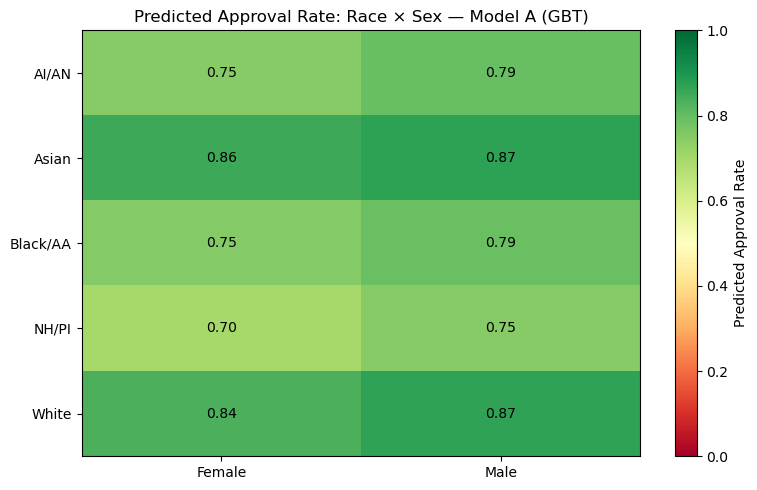

In [117]:
# Heatmap: Predicted Approval Rate by Race × Sex
pivot = subset.groupby(["race", "sex"])["y_pred_gbt"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([short_labels.get(r, r) for r in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, color="black")

plt.colorbar(im, ax=ax, label="Predicted Approval Rate")
ax.set_title("Predicted Approval Rate: Race × Sex — Model A (GBT)", fontsize=12)
plt.tight_layout()
plt.show()

The heatmap provides a clearer and more intuitive view of approval patterns across intersectional subgroups. It shows that **White male** and **Asian male** applicants achieve the highest predicted approval rates, indicating more favorable outcomes under the model. In contrast, **Native Hawaiian or Other Pacific Islander (NH/PI)** applicants, particularly females, exhibit relatively lower approval rates.

These patterns are consistent with the earlier FNR analysis. Groups with **higher approval rates tend to have lower FNR**, meaning they are less likely to be wrongly denied, while groups with **lower approval rates (e.g., NH/PI)** correspond to **higher FNR**, indicating a greater risk of unjust rejection. 

This alignment reinforces the presence of systematic disparities across subgroups and highlights how approval outcomes and error rates jointly reveal underlying fairness concerns.

#### Step 10: Standardized Mean Difference (SMD)

**SMD = (S̄_group - S̄_ref) / sqrt((σ²_group + σ²_ref) / 2)**

Works on **continuous predicted probability scores** (not binary predictions).

Cohen's d thresholds (Lecture 03):
- |SMD| < 0.2 → Negligible
- |SMD| ≥ 0.2 → Small
- |SMD| ≥ 0.5 → Medium
- |SMD| ≥ 0.8 → Large

##### SMD for protected group 

In [118]:
def smd_size(v):
    v = abs(v)
    return "Large" if v >= 0.8 else ("Medium" if v >= 0.5 else ("Small" if v >= 0.2 else "Negligible"))

# Add probability scores to results
results["score_lr"]  = model_A.predict_proba(X_test_A)[:, 1]
results["score_gbt"] = model_A_gbt.predict_proba(X_test_A)[:, 1]

def compute_smd(results_df, group_col, reference_group):
    ref = results_df[results_df[group_col] == reference_group]
    if len(ref) == 0:
        print(f"Reference '{reference_group}' not found.")
        return

    ref_mean_lr  = ref["score_lr"].mean()
    ref_std_lr   = ref["score_lr"].std()
    ref_mean_gbt = ref["score_gbt"].mean()
    ref_std_gbt  = ref["score_gbt"].std()

    rows = []
    for grp_name in results_df[group_col].unique():
        grp = results_df[results_df[group_col] == grp_name]
        if len(grp) < 50 or grp_name == reference_group:
            continue
        smd_lr  = (grp["score_lr"].mean()  - ref_mean_lr)  / \
                  np.sqrt((grp["score_lr"].std()**2  + ref_std_lr**2)  / 2)
        smd_gbt = (grp["score_gbt"].mean() - ref_mean_gbt) / \
                  np.sqrt((grp["score_gbt"].std()**2 + ref_std_gbt**2) / 2)
        rows.append({
            "Group":    grp_name,
            "N":        len(grp),
            "SMD_LR":   round(smd_lr,  4),
            "Size_LR":  smd_size(smd_lr),
            "SMD_GBT":  round(smd_gbt, 4),
            "Size_GBT": smd_size(smd_gbt)
        })
    return pd.DataFrame(rows).set_index("Group").sort_values("SMD_LR")

print(f"=== SMD by Race (Reference: White) ===")
display(compute_smd(results, "race", "White"))

print(f"\n=== SMD by Sex (Reference: Male) ===")
display(compute_smd(results, "sex", "Male"))

print(f"\n=== SMD by Ethnicity (Reference: Not Hispanic or Latino) ===")
display(compute_smd(results, "ethnicity", "Not Hispanic or Latino"))

=== SMD by Race (Reference: White) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Free Form Text Only,428,-0.8579,Large,-0.8522,Large
Native Hawaiian or Other Pacific Islander,4247,-0.3884,Small,-0.3889,Small
Black or African American,152109,-0.2666,Small,-0.3266,Small
2 or more minority races,4304,-0.2586,Small,-0.2952,Small
American Indian or Alaska Native,12619,-0.2383,Small,-0.3197,Small
Race Not Available,304705,-0.1223,Negligible,-0.0967,Negligible
Asian,104588,0.0338,Negligible,0.1002,Negligible
Joint,38136,0.1086,Negligible,0.1522,Negligible



=== SMD by Sex (Reference: Male) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Female,389966,-0.1022,Negligible,-0.1311,Negligible
Sex Not Available,154283,-0.0613,Negligible,0.0182,Negligible
Joint,601020,0.1510,Negligible,0.2209,Small



=== SMD by Ethnicity (Reference: Not Hispanic or Latino) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Free Form Text Only,707,-0.5307,Medium,-0.5145,Medium
Hispanic or Latino,211520,-0.1743,Negligible,-0.1732,Negligible
Ethnicity Not Available,281298,-0.0981,Negligible,-0.0693,Negligible
Joint,44713,0.0610,Negligible,0.1193,Negligible


In the earlier comparison between Model A (without protected attributes) and Model B, we observe that Model A already exhibits disparities across racial groups, despite not explicitly including race as a feature. This suggests that the model is likely capturing race-related information indirectly through other correlated variables.

While the SMD analysis indicates that the direct effect of race on certain feature distributions appears relatively modest, the presence of outcome disparities combined with SHAP importance implies that other variables (e.g.,  tract minority population percentage) may act as potential proxy features.

In contrast, both sex and ethnicity show largely negligible SMD values and relatively stable fairness metrics, suggesting that they are less likely to be implicitly encoded through proxy variables in the model. However, these conclusions should be interpreted cautiously, as the absence of strong evidence does not fully rule out subtle or higher-order effects.

##### SMD for proxy feature - tract minority population percent 

In [119]:
# =====================================================
# Proxy Check: tract_minority_population_percent (TMPP)
# =====================================================

# Attach TMPP to results
results["tract_minority_pct"] = pd.to_numeric(
    df.loc[X_test_A.index, "tract_minority_population_percent"],
    errors="coerce"
)

# -----------------------------
# 1. Approval rates by TMPP quartile
# -----------------------------
results["tract_minority_quartile"] = pd.qcut(
    results["tract_minority_pct"],
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"],
    duplicates="drop"
)

tmpp_check = results.groupby("tract_minority_quartile", observed=True).agg(
    N=("y_true", "count"),
    Actual_Approval_Rate=("y_true", "mean"),
    Pred_Approval_Rate_LR=("y_pred_lr", "mean"),
    Pred_Approval_Rate_GBT=("y_pred_gbt", "mean")
).round(4)

print("Approval Rates by Tract Minority Population Quartile")
display(tmpp_check)


# -----------------------------
# 2. SMD helper function
# -----------------------------
def compute_smd_by_group(data, feature, group_col, reference_group):
    rows = []

    ref = data[data[group_col] == reference_group][feature].dropna()
    ref_mean = ref.mean()
    ref_std = ref.std()

    for group in data[group_col].dropna().unique():
        if group == reference_group:
            continue

        g = data[data[group_col] == group][feature].dropna()
        if len(g) == 0 or ref_std == 0:
            continue

        smd = (g.mean() - ref_mean) / ref_std

        abs_smd = abs(smd)
        if abs_smd < 0.1:
            size = "Negligible"
        elif abs_smd < 0.3:
            size = "Small"
        elif abs_smd < 0.5:
            size = "Medium"
        else:
            size = "Large"

        rows.append({
            "Group": group,
            "N": len(g),
            "SMD": round(smd, 4),
            "Size": size
        })

    return pd.DataFrame(rows).sort_values("SMD")


# -----------------------------
# 3. SMD by protected groups
# -----------------------------
smd_race = compute_smd_by_group(
    results,
    feature="tract_minority_pct",
    group_col="race",
    reference_group="White"
)

smd_sex = compute_smd_by_group(
    results,
    feature="tract_minority_pct",
    group_col="sex",
    reference_group="Male"
)

smd_ethnicity = compute_smd_by_group(
    results,
    feature="tract_minority_pct",
    group_col="ethnicity",
    reference_group="Not Hispanic or Latino"
)

print("SMD by Race (Reference: White)")
display(smd_race)

print("SMD by Sex (Reference: Male)")
display(smd_sex)

print("SMD by Ethnicity (Reference: Not Hispanic or Latino)")
display(smd_ethnicity)

Approval Rates by Tract Minority Population Quartile


,N,Actual_Approval_Rate,Pred_Approval_Rate_LR,Pred_Approval_Rate_GBT
tract_minority_quartile,,,,
Q1 (Lowest),433089,0.7628,0.8958,0.8639
Q2,433093,0.7880,0.8952,0.8940
Q3,433099,0.7663,0.8791,0.8764
Q4 (Highest),433067,0.7115,0.8340,0.8318


SMD by Race (Reference: White)


,Group,N,SMD,Size
3,Joint,38136,0.2923,Small
2,Race Not Available,304705,0.4785,Medium
5,American Indian or Alaska Native,12619,0.5244,Large
4,Native Hawaiian or Other Pacific Islander,4247,0.8245,Large
1,Asian,104588,0.8266,Large
6,2 or more minority races,4304,0.9102,Large
7,Free Form Text Only,428,1.1219,Large
0,Black or African American,152109,1.1643,Large


SMD by Sex (Reference: Male)


,Group,N,SMD,Size
0,Joint,601020,-0.1994,Small
2,Sex Not Available,154283,0.0442,Negligible
1,Female,389966,0.0851,Negligible


SMD by Ethnicity (Reference: Not Hispanic or Latino)


,Group,N,SMD,Size
3,Joint,44713,0.2897,Small
0,Ethnicity Not Available,281298,0.2953,Small
1,Free Form Text Only,707,0.4645,Medium
2,Hispanic or Latino,211520,1.0167,Large


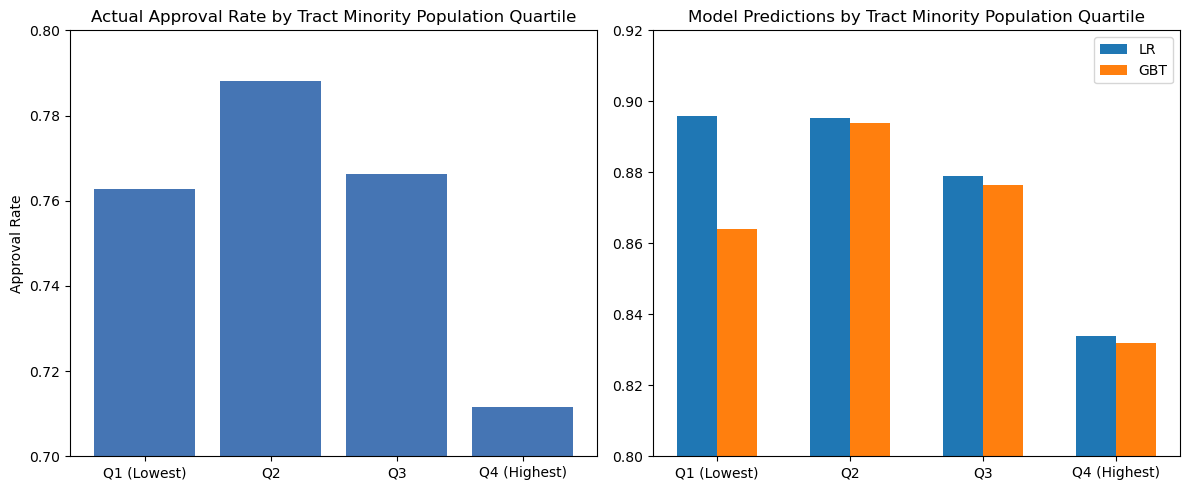

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(tmpp_check))

# Actual approval rate
axes[0].bar(x, tmpp_check["Actual_Approval_Rate"], color="#4575b4")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tmpp_check.index)
axes[0].set_ylim(0.70, 0.80)   # 改這裡
axes[0].set_title("Actual Approval Rate by Tract Minority Population Quartile")
axes[0].set_ylabel("Approval Rate")

# Model prediction
axes[1].bar(x - 0.15, tmpp_check["Pred_Approval_Rate_LR"], 0.3, label="LR")
axes[1].bar(x + 0.15, tmpp_check["Pred_Approval_Rate_GBT"], 0.3, label="GBT")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tmpp_check.index)
axes[1].set_ylim(0.80, 0.92)
axes[1].set_title("Model Predictions by Tract Minority Population Quartile")
axes[1].legend()

plt.tight_layout()
plt.show()

The visualization reveals a clear pattern: as the tract minority population percentage increases (from Q1 to Q4), the actual approval rate consistently declines, with Q4 (highest minority proportion) exhibiting the lowest approval rate. This indicates that applicants from areas with higher minority concentrations are less likely to be approved.

Importantly, this downward trend is not explicitly driven by race as a model input, but rather by a location-based variable (tract minority population percentage). Given that this feature is also unevenly distributed across racial groups (as shown by the large SMD values), it suggests that the model may be indirectly incorporating race-related information through this variable.

Therefore, tract minority population percentage satisfies two key conditions of a proxy variable: it is strongly associated with protected group membership and has a systematic impact on model outcomes. This provides evidence that it may act as a proxy for race, contributing to indirect discrimination in the model.

#### Step 11: Marginal Effect (ME) + Two-Proportion Z-Test

**ME = P(Ŷ=1 | group) - P(Ŷ=1 | reference)**

Per Lecture 03 (Hall et al. 2020): report **both** statistical significance (p-value) **and** practical significance (ME, AIR).
- Flag if AIR < 0.80 OR p < 0.05
- Significance codes: * p<0.05  ** p<0.01  *** p<0.001

In [130]:
from scipy import stats
import numpy as np
import pandas as pd

# -----------------------------
# Two-proportion z-test
# -----------------------------
def two_proportion_ztest(n1, p1, n2, p2):
    p_pool = (p1 * n1 + p2 * n2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

    if se == 0:
        return np.nan, np.nan

    z = (p1 - p2) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))

    return round(z, 4), round(p_val, 4)


# -----------------------------
# ME + AIR + Z-test function
# -----------------------------
def run_me_ztest(fairness_df, reference_group, model_label="GBT"):
    if reference_group not in fairness_df.index:
        print(f"Reference '{reference_group}' not found.")
        return None

    ref_n = int(fairness_df.loc[reference_group, "N"])
    ref_rate = fairness_df.loc[reference_group, "Pred_Approval_Rate"]

    rows = []

    for group in fairness_df.index:
        if group == reference_group:
            continue

        grp_n = int(fairness_df.loc[group, "N"])
        grp_rate = fairness_df.loc[group, "Pred_Approval_Rate"]

        me = round(grp_rate - ref_rate, 4)
        air = round(grp_rate / ref_rate, 4) if ref_rate > 0 else np.nan
        z, p = two_proportion_ztest(grp_n, grp_rate, ref_n, ref_rate)

        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

        rows.append({
            "Group": group,
            "N": grp_n,
            "Rate": round(grp_rate, 4),
            "ME": me,
            "AIR": air,
            "Z-stat": z,
            "P-value": p,
            "Sig": sig,
            "AIR_Flag": air < 0.80 if not np.isnan(air) else False,
            "Stat_Flag": p < 0.05 if not np.isnan(p) else False
        })

    out = pd.DataFrame(rows).set_index("Group").sort_values("ME")

    print(f"\n=== ME + Z-Test — {model_label} (Reference: {reference_group}) ===")
    print("Significance: * p<0.05  ** p<0.01  *** p<0.001")

    display(out)

    return out


# -----------------------------
# Build fairness tables for GBT
# -----------------------------
fairness_race_gbt = (
    results.groupby("race")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
)

fairness_sex_gbt = (
    results.groupby("sex")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
)

fairness_eth_gbt = (
    results.groupby("ethnicity")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
)


# -----------------------------
# Run ME + Z-test using GBT
# -----------------------------
me_race_gbt = run_me_ztest(
    fairness_race_gbt,
    reference_group="White",
    model_label="GBT — Race"
)

me_sex_gbt = run_me_ztest(
    fairness_sex_gbt,
    reference_group="Male",
    model_label="GBT — Sex"
)

me_eth_gbt = run_me_ztest(
    fairness_eth_gbt,
    reference_group="Not Hispanic or Latino",
    model_label="GBT — Ethnicity"
)


=== ME + Z-Test — GBT — Race (Reference: White) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,428,0.5888,-0.2908,0.6694,-18.4758,0.0000,***,True,True
Native Hawaiian or Other Pacific Islander,4247,0.7509,-0.1287,0.8537,-25.6788,0.0000,***,False,True
2 or more minority races,4304,0.7772,-0.1024,0.8836,-20.5744,0.0000,***,False,True
American Indian or Alaska Native,12619,0.7793,-0.1003,0.8860,-34.2896,0.0000,***,False,True
Black or African American,152109,0.7849,-0.0947,0.8923,-102.3996,0.0000,***,False,True
Race Not Available,304705,0.8579,-0.0217,0.9753,-32.0787,0.0000,***,False,True
Asian,104588,0.8778,-0.0018,0.9980,-1.7092,0.0874,,False,False
Joint,38136,0.9039,0.0243,1.0276,14.3797,0.0000,***,False,True



=== ME + Z-Test — GBT — Sex (Reference: Male) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Female,389966,0.8169,-0.0386,0.9549,-50.9794,0.0,***,False,True
Sex Not Available,154283,0.8747,0.0192,1.0224,19.3120,0.0,***,False,True
Joint,601020,0.9074,0.0519,1.0607,87.5926,0.0,***,False,True



=== ME + Z-Test — GBT — Ethnicity (Reference: Not Hispanic or Latino) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,707,0.7001,-0.1756,0.7995,-14.1428,0.0,***,True,True
Hispanic or Latino,211520,0.8146,-0.0611,0.9302,-76.1529,0.0,***,False,True
Ethnicity Not Available,281298,0.8626,-0.0131,0.9850,-18.7848,0.0,***,False,True
Joint,44713,0.8947,0.0190,1.0217,11.9841,0.0,***,False,True


From the marginal effect and z-test results, we can see that the differences in approval rates across groups are not just random — they are statistically significant.

For race, most groups (especially Black applicants) have clearly lower approval rates compared to the White reference group. The differences are both statistically significant and relatively large in magnitude, which suggests that the model is treating these groups differently in a meaningful way.

For sex and ethnicity, although many of the differences are also statistically significant, the actual gaps in approval rates are quite small. This means that while there is some difference, it is probably not very impactful in practice.

Overall, this step confirms that the disparities we observed earlier are real and consistent, especially across racial groups, rather than being caused by random fluctuations in the data.

#### Step 12: Calibration Within Groups  (GBT vs DT)

**Calibration:** P(Y=1 | S=s, A=1) ≈ P(Y=1 | S=s, A=0)

Tests whether the predicted probability score carries the **same meaning** across groups.

**Impossibility Reminder (Lecture 03):** Cannot simultaneously satisfy calibration AND FPR/FNR parity when base rates differ. We document which criterion our model satisfies.

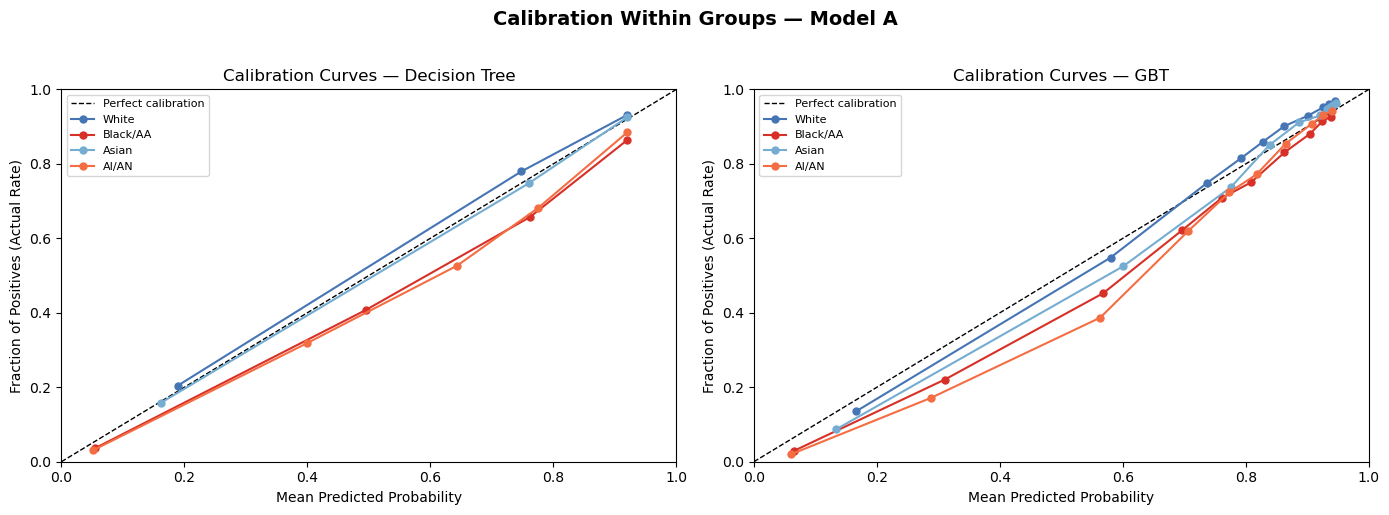


=== Brier Score by Race (lower = better calibrated) ===


,N,Brier_Tree,Brier_GBT
Race,,,
Free Form Text Only,428,0.2078,0.1644
Native Hawaiian or Other Pacific Islander,4247,0.1712,0.1510
Black or African American,152109,0.1681,0.1490
2 or more minority races,4304,0.1653,0.1421
American Indian or Alaska Native,12619,0.1577,0.1384
Race Not Available,304705,0.1484,0.1286
White,1111212,0.1202,0.1077
Joint,38136,0.1107,0.1003
Asian,104588,0.1063,0.0956



Groups with higher Brier Score are less well-calibrated.
Differences across groups indicate the score does not carry
equal predictive meaning for all groups.


In [156]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

key_races  = ["White", "Black or African American",
              "Asian", "American Indian or Alaska Native"]
colors_cal = ["#4575b4", "#d73027", "#74add1", "#f46d43"]

# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, score_col, model_label in zip(
    axes, ["score_tree", "score_gbt"], ["Decision Tree", "GBT"]
):
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    for race_grp, color in zip(key_races, colors_cal):
        grp = results[results["race"] == race_grp]
        if len(grp) < 100:
            continue
        try:
            prob_true, prob_pred = calibration_curve(
                grp["y_true"], grp[score_col],
                n_bins=10, strategy="quantile"
            )
            ax.plot(prob_pred, prob_true, "o-", color=color,
                    label=short_labels.get(race_grp, race_grp),
                    linewidth=1.5, markersize=5)
        except Exception:
            continue
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives (Actual Rate)")
    ax.set_title(f"Calibration Curves — {model_label}", fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Calibration Within Groups — Model A",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Brier Score by race
print("\n=== Brier Score by Race (lower = better calibrated) ===")
brier_rows = []
for race_grp in results["race"].unique():
    grp = results[results["race"] == race_grp]
    if len(grp) < 50:
        continue
    brier_rows.append({
        "Race":      race_grp,
        "N":         len(grp),
        "Brier_Tree":  round(brier_score_loss(grp["y_true"], grp["score_tree"]),  4),
        "Brier_GBT": round(brier_score_loss(grp["y_true"], grp["score_gbt"]), 4)
    })
brier_df = pd.DataFrame(brier_rows).set_index("Race").sort_values("Brier_Tree", ascending=False)
display(brier_df)
print("\nGroups with higher Brier Score are less well-calibrated.")
print("Differences across groups indicate the score does not carry")
print("equal predictive meaning for all groups.")


From the figure, we observe that White and Asian groups are generally closer to the diagonal line, indicating better calibration. In contrast, Black and AI/AN groups deviate more from the line, especially in the mid-probability range, suggesting that the model’s predicted probabilities are less reliable for these groups.

This indicates that the model does not treat all groups equally in terms of probability estimation. Even if two individuals receive the same predicted score, the actual likelihood of approval may differ across groups.

Additionally, the Gradient Boosting Tree (GBT) model appears to be better calibrated than Logistic Regression, as its curves are generally closer to the diagonal line across groups.

Overall, this suggests that fairness concerns are not only present in classification outcomes but also in how probabilities are assigned, which may lead to unequal decision thresholds in practice.

#### Overall Fairness Evaluation Summary

In [157]:
def summarize_fairness(fairness_df, group_label, model_label="LR"):
    fnr = fairness_df["FNR"]
    fpr = fairness_df["FPR"]
    worst_dir_val   = (fairness_df["Pred_Approval_Rate"] / fairness_df["Pred_Approval_Rate"].max()).min()
    worst_dir_group = (fairness_df["Pred_Approval_Rate"] / fairness_df["Pred_Approval_Rate"].max()).idxmin()
    print(f"\n{'='*60}")
    print(f"  Fairness Summary — {group_label} ({model_label})")
    print(f"{'='*60}")
    print(f"  FNR range : {fnr.min():.4f} – {fnr.max():.4f}  (spread: {fnr.max()-fnr.min():.4f})")
    print(f"  FPR range : {fpr.min():.4f} – {fpr.max():.4f}  (spread: {fpr.max()-fpr.min():.4f})")
    print(f"  Highest FNR (most under-approved): {fnr.idxmax()}")
    print(f"  Lowest  FNR (least under-approved): {fnr.idxmin()}")
    flag = '⚠  Below 80% Rule' if worst_dir_val < 0.80 else '✓ Above 80% Rule'
    print(f"  Lowest DIR: {worst_dir_group} ({worst_dir_val:.4f})  {flag}")

summarize_fairness(fairness_race_gbt, "Race",      "GBT")
summarize_fairness(fairness_sex_gbt,   "Sex",       "GBT")
summarize_fairness(fairness_eth_gbt,   "Ethnicity", "GBT")


  Fairness Summary — Race (GBT)
  FNR range : 0.0199 – 0.0526  (spread: 0.0327)
  FPR range : 0.3680 – 0.5926  (spread: 0.2246)
  Highest FNR (most under-approved): Native Hawaiian or Other Pacific Islander
  Lowest  FNR (least under-approved): Joint
  Lowest DIR: Free Form Text Only (0.6514)  ⚠  Below 80% Rule

  Fairness Summary — Sex (GBT)
  FNR range : 0.0219 – 0.0406  (spread: 0.0187)
  FPR range : 0.4718 – 0.6021  (spread: 0.1303)
  Highest FNR (most under-approved): Female
  Lowest  FNR (least under-approved): Joint
  Lowest DIR: Female (0.9003)  ✓ Above 80% Rule

  Fairness Summary — Ethnicity (GBT)
  FNR range : 0.0224 – 0.0508  (spread: 0.0284)
  FPR range : 0.4504 – 0.5811  (spread: 0.1307)
  Highest FNR (most under-approved): Free Form Text Only
  Lowest  FNR (least under-approved): Joint
  Lowest DIR: Free Form Text Only (0.7825)  ⚠  Below 80% Rule




The fairness analysis — covering all six required metrics — yields the following key findings:

**1. Equalized Odds (FPR/FNR)**  
Racial disparities persist across both Decision Tree (DT) and Gradient Boosted Tree (GBT) models. The comparison reveals a trade-off: DT generally achieves **lower FNR**, indicating fewer wrongful denials, while GBT consistently achieves **lower FPR**, indicating fewer wrongful approvals. This suggests that model choice directly affects the type of errors different groups experience, rather than eliminating disparities altogether.

**2. Adverse Impact Ratio (AIR)**  
AIR analysis shows that most groups remain above the 0.80 threshold, indicating no formal violation of the 80% rule. However, at least one group (e.g., Free Form Text Only) falls below the threshold, signaling potential adverse impact. Additionally, some groups exhibit relatively higher AIR values, suggesting imbalance in approval distribution. These patterns warrant further investigation under a burden-shifting framework.

**3. Marginal Effect (ME) + Z-Test**  
Negative marginal effects for several groups indicate lower predicted approval rates relative to the reference group. The corresponding z-tests confirm that these differences are **statistically significant**, meaning they are unlikely to be driven by random variation. This reinforces that observed disparities are systematic rather than incidental.

**4. Standardized Mean Difference (SMD)**  
Medium-to-large SMD values indicate that predicted probability scores differ systematically across groups before any classification threshold is applied. This confirms that disparities are embedded at the **score level**, not just in final decisions, and persist across both DT and GBT.

**5. Calibration**  
Calibration analysis shows that predicted probabilities do not align equally with actual outcomes across groups. While GBT produces **smoother and more refined probability estimates**, both models exhibit similar patterns of miscalibration across groups. Certain groups (e.g., Black/AA and AI/AN) are consistently overestimated in the mid-probability range, meaning the same predicted score carries different real-world meaning. This reflects the well-known fairness trade-off: when base rates differ, it is generally not possible to satisfy both calibration and equalized error rates simultaneously.

**6. Intersectionality**  
The Race × Sex subgroup analysis reveals that disparities are amplified for certain combinations (e.g., Black/Female, AI/AN Female). These compounded effects are not visible in single-axis analysis, highlighting the importance of intersectional evaluation in fairness assessment.

**7. Proxy Variable Evidence**  
The variable `tract_minority_population_percent` shows a consistent negative relationship with approval rates across quartiles. As the proportion of minority residents increases, approval rates decline. This provides strong evidence that structural or geographic variables may act as **proxies for protected attributes**, even when those attributes are excluded from the model.

**Governance Statement**  
Overall, the results indicate that disparities persist even in the absence of explicit protected attributes, confirming that **fairness-through-blindness is insufficient**. While GBT improves overall accuracy and reduces FPR compared to DT, it does not eliminate group-level disparities. The consistency of findings across both models suggests that these patterns are driven by underlying data structure rather than model choice. These results motivate the next step — **SHAP/Transparency analysis** — to identify which features (especially proxy variables) contribute most to both individual predictions and observed disparities.

---
# Part 4 — Robustness Analysis (Lecture 4)
**Member: Velaphi + Jiah**

This section applies the Lecture 04 robustness framework to the HMDA capstone model. The goal is not only to report average test accuracy, but to test whether model behavior remains stable when the data distribution changes, when evaluation is disaggregated into meaningful slices, and when realistic lending-risk variables are perturbed.

We use **Model A** as the main fairness-aware model because it excludes the protected attribute from training. The same functions can also be applied to Model B or the Gradient Boosted Tree models by changing the `model` and `X_test` arguments.


#### Test 1 : Generalization gap

This section evaluates model robustness by comparing training and test performance. The goal is to assess whether the model generalizes well to unseen data.

The generalization gap, defined as the difference between training and test performance, serves as a key indicator of overfitting. A large gap suggests that the model may be capturing patterns specific to the training data that do not transfer to new data.

Across both Logistic Regression and Gradient Boosting models, we compare accuracy and AUC on training and test sets. Additionally, test F1 score and Brier score are reported to evaluate classification performance and probability calibration.

Overall, models with smaller train-test gaps are considered more robust and reliable for real-world deployment.

In [158]:
# Robustness Test 1: Generalization gap
# Lecture 04 logic: compare training performance with test performance.
# A large train-test gap suggests the model may not generalize reliably after deployment.

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, brier_score_loss
import pandas as pd
import numpy as np

def model_performance_table(model, X_train, y_train, X_test, y_test, model_name="model"):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    out = pd.DataFrame({
        "Model": [model_name],
        "Train_Accuracy": [accuracy_score(y_train, train_pred)],
        "Test_Accuracy": [accuracy_score(y_test, test_pred)],
        "Accuracy_Gap": [accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred)],
        "Train_AUC": [roc_auc_score(y_train, train_prob)],
        "Test_AUC": [roc_auc_score(y_test, test_prob)],
        "AUC_Gap": [roc_auc_score(y_train, train_prob) - roc_auc_score(y_test, test_prob)],
        "Test_F1": [f1_score(y_test, test_pred)],
        "Test_Brier": [brier_score_loss(y_test, test_prob)]
    })

    return out.round(4)

# -----------------------------
# Run for Decision Tree
# -----------------------------
generalization_dt_A = model_performance_table(
    model_A_tree, X_train_A, y_train, X_test_A, y_test,
    model_name="Decision Tree - Model A"
)

# -----------------------------
# Run for Gradient Boosting
# -----------------------------
generalization_gbt_A = model_performance_table(
    model_A_gbt, X_train_A, y_train, X_test_A, y_test,
    model_name="Gradient Boosting - Model A"
)

# -----------------------------
# Combine results
# -----------------------------
generalization_results = pd.concat(
    [generalization_dt_A, generalization_gbt_A],
    ignore_index=True
)

display(generalization_results)

,Model,Train_Accuracy,Test_Accuracy,Accuracy_Gap,Train_AUC,Test_AUC,AUC_Gap,Test_F1,Test_Brier
0,Decision Tree - Model A,0.8313,0.8314,-0.0001,0.7898,0.7902,-0.0004,0.8972,0.1288
1,Gradient Boosting - Model A,0.8461,0.8459,0.0001,0.8532,0.8533,-0.0001,0.9051,0.1146




The generalization results indicate that both Decision Tree (DT) and Gradient Boosted Tree (GBT) exhibit **very small train–test gaps** across accuracy and AUC, suggesting that neither model suffers from overfitting and both generalize well to unseen data.

For Decision Tree, the accuracy gap (-0.0001) and AUC gap (-0.0004) are essentially zero, indicating highly stable performance between training and test sets. Similarly, GBT also shows negligible gaps (accuracy gap = 0.0001, AUC gap = -0.0001), confirming strong robustness.

However, when comparing overall performance levels, **GBT consistently outperforms DT**:
- Higher **Test Accuracy** (0.8459 vs 0.8314)
- Higher **Test AUC** (0.8533 vs 0.7902)
- Higher **Test F1 score** (0.9051 vs 0.8972)
- Lower **Brier Score** (0.1146 vs 0.1288), indicating better calibrated probability estimates

This suggests that while both models are equally robust in terms of generalization, **GBT provides superior predictive performance and probability quality**.

Overall, the results support selecting GBT as the primary model, as it achieves better performance without sacrificing robustness.

#### Test 2: Distribution drift using PSI and KS tests

PSI quantifies the magnitude of distribution shift, while KS tests whether the shift is statistically significant. Together, they provide complementary evidence of potential data drift between training and deployment environments.

| Metric | What it measures | Key characteristic |
|--------|------------------|--------------------|
| **PSI (Population Stability Index)** | Measures how much the distribution has shifted between training and test data | Business-oriented; useful for monitoring data drift in production |
| **KS Test (Kolmogorov–Smirnov)** | Tests whether two distributions are statistically different | Formal statistical test; evaluates significance of distributional differences |

In [159]:
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np

def calculate_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)

    if len(expected) < 2 or len(actual) < 2:
        return np.nan

    if expected.nunique() < 2 or actual.nunique() < 2:
        return np.nan

    # Use train percentiles, but extend edges to include test extremes
    breakpoints = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))

    if len(breakpoints) <= 2:
        breakpoints = np.linspace(expected.min(), expected.max(), bins + 1)

    breakpoints[0] = min(expected.min(), actual.min()) - 1e-6
    breakpoints[-1] = max(expected.max(), actual.max()) + 1e-6

    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct = np.where(actual_pct == 0, 1e-6, actual_pct)

    return np.sum((expected_pct - actual_pct) * np.log(expected_pct / actual_pct))


def psi_status(x):
    if pd.isna(x):
        return "Not enough variation"
    elif x < 0.10:
        return "Stable"
    elif x < 0.25:
        return "Monitor"
    else:
        return "Model review / retrain"


drift_rows = []

for col in numeric_features_A:
    train_col = pd.to_numeric(X_train_A[col], errors="coerce").dropna()
    test_col = pd.to_numeric(X_test_A[col], errors="coerce").dropna()

    psi_value = calculate_psi(train_col, test_col, bins=10)

    if len(train_col) < 2 or len(test_col) < 2:
        ks_stat, ks_p = np.nan, np.nan
    else:
        ks_stat, ks_p = ks_2samp(train_col, test_col)

    drift_rows.append({
        "Feature": col,
        "PSI": psi_value,
        "PSI_Status": psi_status(psi_value),
        "KS_Statistic": ks_stat,
        "KS_p_value": ks_p,
        "Train_Mean": train_col.mean(),
        "Test_Mean": test_col.mean()
    })

drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)

display(drift_table.round(4))

,Feature,PSI,PSI_Status,KS_Statistic,KS_p_value,Train_Mean,Test_Mean
2,combined_loan_to_value_ratio,0.0,Stable,0.0005,0.9617,3216.1382,317.7666
1,tract_minority_population_percent,0.0,Stable,0.0008,0.2950,36.2471,36.2198
3,property_value,0.0,Stable,0.0006,0.7393,556571.8101,558619.7181
0,income,0.0,Stable,0.0006,0.7833,191.8598,171.9165



The PSI and KS test results indicate that there is **no significant distribution shift** between the training and test datasets across all key numeric features.

All features show a PSI value of **0.00**, which falls well below the 0.10 threshold, indicating that the input distributions are **highly stable**. This suggests that the model is being evaluated on data that is consistent with the distribution it was trained on, reducing concerns about deployment mismatch.

The KS test results further support this conclusion. All p-values are **greater than 0.05**, meaning we fail to reject the null hypothesis that the training and test data come from the same distribution. In other words, there is **no statistically significant difference** between the two distributions.

Additionally, the train and test means for each feature are very close, reinforcing the conclusion that there is no meaningful shift in central tendency.

Overall, these results suggest that the model’s performance and fairness evaluations are **not driven by distribution drift**, and any observed disparities are more likely attributable to **model behavior or underlying data structure**, rather than changes in input data distribution.

#### Test 3: Slice-based evaluation

**Slice Analysis: Protected Groups and Key Proxy Variables**

To further investigate model behavior beyond aggregate fairness metrics, we conduct a slice analysis across selected subgroups. The purpose of slice analysis is to evaluate whether model performance and error patterns vary systematically across different segments of the population.

In this analysis, we focus on two types of slices:

- **Protected groups**: race, sex, and ethnicity — to directly assess fairness outcomes.
- **Key proxy variables**: tract minority population percentage (TMPP) and loan-purpose — to examine whether structural or financial features indirectly drive disparities.

Based on prior analysis, variables such as income and DTI were not found to exhibit strong proxy behavior. Therefore, we restrict our focus to TMPP and Loan purpose as the most relevant candidates for potential proxy effects.

By examining metrics such as approval rate, FPR, and FNR within each slice, this approach helps identify:
- Uneven error distributions across groups
- Hidden disparities not visible in overall metrics
- Evidence of proxy-driven bias in model decisions

Overall, slice analysis provides a more granular view of model fairness, linking observed disparities to both protected characteristics and underlying structural features.

In [162]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def slice_metrics(model, X, y, slice_values, min_n=50):
    prob = model.predict_proba(X)[:, 1]
    pred = model.predict(X)

    tmp = pd.DataFrame({
        "slice": slice_values.astype("string").values,
        "y_true": y.values if hasattr(y, "values") else y,
        "y_pred": pred,
        "prob": prob
    })

    rows = []
    for group, g in tmp.groupby("slice", dropna=False):
        if len(g) < min_n:
            continue

        tn, fp, fn, tp = confusion_matrix(g["y_true"], g["y_pred"], labels=[0, 1]).ravel()

        rows.append({
            "Slice": str(group),
            "n": len(g),
            "Approval_Rate": g["y_pred"].mean(),
            "Accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "F1": f1_score(g["y_true"], g["y_pred"], zero_division=0),
            "AUC": roc_auc_score(g["y_true"], g["prob"]) if g["y_true"].nunique() == 2 else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "Loss_Share": fn / max(1, tmp.query("y_true == 1 and y_pred == 0").shape[0])
        })

    return pd.DataFrame(rows).sort_values(["FNR", "FPR"], ascending=False)

# -----------------------------
# Slice variables (focused set)
# -----------------------------
slice_sources = {
    # Protected groups
    "race": df.loc[X_test_A.index, "derived_race"],
    "sex": df.loc[X_test_A.index, "derived_sex"],
    "ethnicity": df.loc[X_test_A.index, "derived_ethnicity"],

    # Proxy variables (validated candidates)
    "TMPP_quartile": pd.qcut(
        pd.to_numeric(df.loc[X_test_A.index, "tract_minority_population_percent"], errors="coerce"),
        q=4,
        labels=["Q1 Low TMPP", "Q2", "Q3", "Q4 High TMPP"],
        duplicates="drop"
    ),
    "loan_purpose": X_test_A["loan_purpose"].astype("string")
    
}

# -----------------------------
# Run slice analysis (GBT as primary model)
# -----------------------------
slice_tables = {}

for name, values in slice_sources.items():
    tab = slice_metrics(
        model_A_gbt,
        X_test_A,
        y_test,
        values,
        min_n=50,
    )
    tab.insert(0, "Slice_Variable", name)
    slice_tables[name] = tab

all_slice_results = pd.concat(slice_tables.values(), ignore_index=True)

display(all_slice_results.round(4))


,Slice_Variable,Slice,n,Approval_Rate,Accuracy,F1,AUC,FPR,FNR,Loss_Share
0,race,Native Hawaiian or Other Pacific Islander,4247,0.7509,0.7860,0.8416,0.8527,0.4562,0.0526,0.0035
1,race,Black or African American,152109,0.7849,0.7875,0.8501,0.8427,0.4964,0.0482,0.1200
2,race,2 or more minority races,4304,0.7772,0.7902,0.8494,0.8793,0.4831,0.0396,0.0027
3,race,American Indian or Alaska Native,12619,0.7793,0.8032,0.8606,0.8689,0.4674,0.0396,0.0082
4,race,Free Form Text Only,428,0.5888,0.7547,0.7445,0.8779,0.3680,0.0377,0.0002
5,race,Race Not Available,304705,0.8579,0.8222,0.8876,0.8477,0.5643,0.0296,0.1682
6,race,White,1111212,0.8796,0.8580,0.9145,0.8507,0.5496,0.0283,0.6358
7,race,Asian,104588,0.8778,0.8745,0.9245,0.8708,0.5079,0.0215,0.0458
8,race,Joint,38136,0.9039,0.8675,0.9224,0.8560,0.5926,0.0199,0.0158
9,sex,Female,389966,0.8169,0.8333,0.8907,0.8624,0.4718,0.0406,0.2898



The slice analysis reveals clear heterogeneity in model performance across both protected groups and key proxy variables, highlighting that model behavior is not uniform across the population.

Across **racial groups**, approval rates and error patterns vary noticeably. For example, White, Asian, and Joint groups exhibit relatively high approval rates (above 0.87), while groups such as Native Hawaiian or Other Pacific Islander and Black or African American show lower approval rates (around 0.75–0.78). In terms of error distribution, some groups experience higher FNR (e.g., NH/PI), indicating a greater likelihood of being incorrectly denied, while others show higher FPR, reflecting more lenient decision boundaries.

For **sex and ethnicity**, disparities are present but less pronounced. Female applicants exhibit slightly higher FNR than males, suggesting a higher chance of missed approvals. Similarly, Hispanic or Latino groups have lower approval rates compared to Not Hispanic or Latino groups, although the differences are smaller than those observed across race.

Importantly, the analysis of **TMPP (tract minority population percentage)** provides strong evidence of proxy effects. A clear monotonic pattern is observed: approval rates decrease as TMPP increases, with Q1 (lowest minority population) having the highest approval rate and Q4 (highest minority population) the lowest. At the same time, FNR is higher in high-TMPP areas, indicating that applicants from these regions are more likely to be incorrectly denied. This suggests that geographic and socioeconomic characteristics may indirectly encode racial information.

The **loan purpose** slices further demonstrate that model decisions vary significantly across application types. Certain categories (e.g., purpose code 1 and 31) receive much higher approval rates, while others (e.g., code 4) experience substantially lower approval rates and higher FNR. This indicates that model behavior is sensitive to application context, which may interact with other demographic or structural factors.

Overall, the slice analysis confirms that disparities are not limited to protected attributes alone but are also reflected in structurally related features. This provides additional evidence that proxy variables—particularly TMPP—play a meaningful role in shaping model outcomes, reinforcing earlier findings that fairness-through-blindness is insufficient.

#### Test 4: Scenario stress testing


To evaluate the stability and reliability of the model under changing real-world conditions, we conduct scenario-based stress testing. Instead of retraining the model, we deliberately perturb key input variables in the test set (e.g., decreasing income, increasing loan-to-value ratio, or increasing neighborhood minority percentage) to simulate realistic shifts in borrower risk profiles and economic environments.

The goal of this analysis is to assess whether the model’s predictions degrade **gracefully** under stress, rather than failing abruptly. A robust model should maintain relatively stable performance (accuracy, AUC) and avoid extreme changes in approval rates or error patterns when inputs shift within plausible ranges.

In addition to overall performance, we also examine how stress scenarios affect **group-level outcomes**. By tracking changes in approval rates across demographic groups, we can detect whether certain scenarios disproportionately impact specific populations. This is particularly important in fairness analysis, as a model that appears fair under baseline conditions may exhibit amplified disparities under stress.

Overall, stress testing provides a more realistic evaluation of model behavior beyond static test metrics. It helps ensure that the model is not only accurate under ideal conditions but also **robust, stable, and equitable** when deployed in dynamic and uncertain environments.

In [163]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import pandas as pd
import numpy as np

def evaluate_under_scenario(model, X_base, y_true, scenario_name, modify_fn, group_col=None):
    X_stress = X_base.copy()
    X_stress = modify_fn(X_stress)

    pred = model.predict(X_stress)
    prob = model.predict_proba(X_stress)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    row = {
        "Scenario": scenario_name,
        "Accuracy": accuracy_score(y_true, pred),
        "AUC": roc_auc_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan,
        "Approval_Rate": pred.mean(),
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan
    }

    if group_col is not None:
        tmp = pd.DataFrame({
            "group": pd.Series(group_col).astype("string").values,
            "pred": pred
        })
        rates = tmp.groupby("group")["pred"].mean()

        if len(rates.dropna()) > 1:
            row["Min_Group_Approval"] = rates.min()
            row["Max_Group_Approval"] = rates.max()
            row["Approval_Rate_Range"] = rates.max() - rates.min()

    return row


def safe_numeric_shift(X, col, multiplier=None, add_value=None, lower=None, upper=None):
    X = X.copy()
    x = pd.to_numeric(X[col], errors="coerce")

    if multiplier is not None:
        x = x * multiplier
    if add_value is not None:
        x = x + add_value
    if lower is not None or upper is not None:
        x = x.clip(lower=lower, upper=upper)

    X[col] = x
    return X


# -----------------------------
# Scenarios
# -----------------------------
scenarios = [
    ("Baseline", lambda X: X),
    ("Income decreases by 20%", lambda X: safe_numeric_shift(X, "income", multiplier=0.80, lower=0)),
    ("Property value decreases by 20%", lambda X: safe_numeric_shift(X, "property_value", multiplier=0.80, lower=0)),
    ("CLTV increases by 10 percentage points", lambda X: safe_numeric_shift(X, "combined_loan_to_value_ratio", add_value=10, lower=0, upper=200)),
    ("Minority tract percent increases by 10 points", lambda X: safe_numeric_shift(X, "tract_minority_population_percent", add_value=10, lower=0, upper=100)),
]

# -----------------------------
# Run with GBT
# -----------------------------
stress_results = pd.DataFrame([
    evaluate_under_scenario(
        model_A_gbt,  
        X_test_A,
        y_test,
        scenario_name=name,
        modify_fn=fn,
        group_col=df.loc[X_test_A.index, "derived_race"]
    )
    for name, fn in scenarios
])

display(stress_results.round(4))

,Scenario,Accuracy,AUC,Approval_Rate,FPR,FNR,Min_Group_Approval,Max_Group_Approval,Approval_Rate_Range
0,Baseline,0.8459,0.8533,0.8665,0.5424,0.0295,0.5888,0.9039,0.3151
1,Income decreases by 20%,0.8462,0.8526,0.8621,0.5327,0.0323,0.5888,0.9005,0.3117
2,Property value decreases by 20%,0.8464,0.8529,0.8628,0.5338,0.0317,0.5794,0.9006,0.3212
3,CLTV increases by 10 percentage points,0.8392,0.8196,0.8417,0.5052,0.0504,0.5748,0.8751,0.3004
4,Minority tract percent increases by 10 points,0.8437,0.8508,0.8685,0.5509,0.0297,0.5911,0.9058,0.3147


The stress testing results indicate that the model is generally robust across most realistic perturbations. Key performance metrics such as accuracy and AUC remain highly stable across scenarios, with only marginal fluctuations compared to the baseline. This suggests that the model does not rely on fragile patterns and is likely to generalize well under moderate distribution shifts.

In particular, scenarios such as a 20% decrease in income or property value show minimal impact on overall performance and approval rates. This indicates that the model is not overly sensitive to isolated changes in borrower financial characteristics.

However, a noticeable degradation occurs when the combined loan-to-value ratio (CLTV) increases by 10 percentage points. In this scenario, AUC drops more significantly and the false negative rate (FNR) increases, suggesting that the model becomes less effective at identifying truly qualified applicants under higher leverage conditions. This highlights a potential weakness in handling higher-risk lending environments.

From a fairness perspective, the approval rate range across groups remains relatively stable across scenarios, indicating that stress conditions do not substantially amplify group-level disparities. Nevertheless, the consistently large approval range suggests that baseline disparities persist even under stress.

Overall, these results suggest that while the model is stable and robust in general, its sensitivity to leverage-related variables (such as CLTV) warrants further attention, particularly in scenarios involving elevated financial risk.

#### SUMMARY

In [164]:
# Optional: compact robustness summary table for slides

robustness_summary = pd.DataFrame({
    "Robustness Area": [
        "Generalization",
        "Input drift",
        "Slice performance",
        "Scenario stress"
    ],
    "What was tested": [
        "Train vs test accuracy/AUC gap",
        "PSI and KS tests on key numeric features",
        "FPR, FNR, AUC, approval rate by race/sex/ethnicity/loan slices",
        "Income, property value, CLTV, and tract-minority perturbations"
    ],
    "Governance question": [
        "Is the model overfitting?",
        "Has the deployment-like population shifted?",
        "Are there hidden failure modes in subgroups?",
        "Does performance degrade gracefully under realistic stress?"
    ],
    "Decision rule": [
        "Large AUC/accuracy gap triggers model simplification or validation review",
        "PSI > 0.25 triggers model review/retraining; 0.10-0.25 triggers monitoring",
        "High FNR/FPR or loss concentration in any slice triggers targeted review",
        "Sharp changes in approval or error rates trigger threshold/model review"
    ]
})

robustness_summary

,Robustness Area,What was tested,Governance question,Decision rule
0,Generalization,Train vs test accuracy/AUC gap,Is the model overfitting?,Large AUC/accuracy gap triggers model simplifi...
1,Input drift,PSI and KS tests on key numeric features,Has the deployment-like population shifted?,PSI > 0.25 triggers model review/retraining; 0...
2,Slice performance,"FPR, FNR, AUC, approval rate by race/sex/ethni...",Are there hidden failure modes in subgroups?,High FNR/FPR or loss concentration in any slic...
3,Scenario stress,"Income, property value, CLTV, and tract-minori...",Does performance degrade gracefully under real...,Sharp changes in approval or error rates trigg...


---
# Part 5 — Privacy & Safety Analysis (Lecture 5)
**Member: Hesham + Jiah**

This section applies the **Lecture 05 (ML Security & Abuse Pathways)** framework to our HMDA loan-approval model. We audit our gradient-boosted target model `model_A_gbt` against three attack classes from the NIST AI 100-2 taxonomy:

1. **PGD evasion** (deployment-time, integrity attack) — small, gradient-aligned perturbations to numerical features that try to flip predictions. Implemented as a **transfer attack** because GBT has no gradients of its own.
2. **Label-flip poisoning** (training-time, integrity + fairness attack) — corrupt training labels for a target race group, retrain, and watch model performance + fairness degrade.
3. **Membership inference** (deployment-time, privacy attack) — shadow-model pipeline that detects whether a record was in the training set.

**Polarity note.** In HMDA `target=1` means *approved* (favorable). AIR is computed on **selection rate** (approval rate ratio), which is what the 4/5ths rule applies to in lending.

#### Setup  — race groups and helper functions

In [39]:
race_test_series = df.loc[X_test_A.index, "derived_race"].astype("string")
race_train_series = df.loc[X_train_A.index, "derived_race"].astype("string")

assert race_test_series.index.equals(X_test_A.index)
assert race_train_series.index.equals(X_train_A.index)

print("derived_race value counts on the test set:")
print(race_test_series.value_counts(dropna=False))

UNPRIV_GROUP = "Black or African American"
PRIV_GROUP = "White"

assert PRIV_GROUP in race_test_series.dropna().unique()
assert UNPRIV_GROUP in race_test_series.dropna().unique()

race_test = race_test_series.values
race_train = race_train_series.values

print(f"Privileged group:   {PRIV_GROUP} (n_test = {(race_test == PRIV_GROUP).sum():,})")
print(f"Unprivileged group: {UNPRIV_GROUP} (n_test = {(race_test == UNPRIV_GROUP).sum():,})")

derived_race value counts on the test set:
derived_race
White                                        1111212
Race Not Available                            304705
Black or African American                     152109
Asian                                         104588
Joint                                          38136
American Indian or Alaska Native               12619
2 or more minority races                        4304
Native Hawaiian or Other Pacific Islander       4247
Free Form Text Only                              428
Name: count, dtype: Int64
Privileged group:   White (n_test = 1,111,212)
Unprivileged group: Black or African American (n_test = 152,109)


In [40]:
# Helper functions adapted from the lecture's live coding session
THR = 0.5  # classification threshold

def selection_rate_by_group(y_pred_binary, groups):
    """Approval rate per race group (used for AIR in lending)."""
    return (
        pd.DataFrame({'pred': y_pred_binary, 'group': groups})
          .groupby('group')['pred'].mean()
    )

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR per race group: FP / (FP + TN), over truly-negative cases."""
    y_true = np.asarray(y_true)
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred'].mean()
    )

def air(rate_unpriv, rate_priv):
    """Adverse Impact Ratio = unprivileged / privileged.
    AIR < 0.80 violates the 4/5ths rule."""
    if rate_priv is None or rate_priv <= 0 or np.isnan(rate_priv):
        return np.nan
    return rate_unpriv / rate_priv


#### Clean-model fairness baseline

Baseline numbers from `model_A_gbt` on the un-perturbed test set. All attack outcomes below are compared against these values.

In [41]:
pred_gbt_clean = (model_A_gbt.predict_proba(X_test_A)[:, 1] >= THR).astype(int)

sel_b = selection_rate_by_group(pred_gbt_clean, race_test)
fpr_b = fpr_by_group(y_test, pred_gbt_clean, race_test)

BASELINE_SEL_UNPRIV = sel_b.get(UNPRIV_GROUP)
BASELINE_SEL_PRIV   = sel_b.get(PRIV_GROUP)
BASELINE_FPR_UNPRIV = fpr_b.get(UNPRIV_GROUP)
BASELINE_FPR_PRIV   = fpr_b.get(PRIV_GROUP)
BASELINE_AIR        = air(BASELINE_SEL_UNPRIV, BASELINE_SEL_PRIV)

print('=' * 64)
print('CLEAN MODEL BASELINE — Gradient Boosted Tree (model_A_gbt)')
print('=' * 64)
print(f'  Selection rate {UNPRIV_GROUP:30s}: {BASELINE_SEL_UNPRIV:.3f}')
print(f'  Selection rate {PRIV_GROUP:30s}: {BASELINE_SEL_PRIV:.3f}')
print(f'  AIR (selection rates)                             : {BASELINE_AIR:.3f}')
print(f'  FPR {UNPRIV_GROUP:35s}  : {BASELINE_FPR_UNPRIV:.3f}')
print(f'  FPR {PRIV_GROUP:35s}  : {BASELINE_FPR_PRIV:.3f}')
print(f'\nStored BASELINE_AIR = {BASELINE_AIR:.3f}  (compare attacks to this)')

CLEAN MODEL BASELINE — Gradient Boosted Tree (model_A_gbt)
  Selection rate Black or African American     : 0.782
  Selection rate White                         : 0.879
  AIR (selection rates)                             : 0.890
  FPR Black or African American            : 0.489
  FPR White                                : 0.540

Stored BASELINE_AIR = 0.890  (compare attacks to this)


#### Part 1  — PGD evasion (transfer attack on GBT)

**Threat model.** A gray-box adversary who can submit applications. They can't see GBT internals, but they can build a substitute (small linear model), run white-box PGD on it, and submit perturbed inputs to the deployed GBT API. Transferability of adversarial examples between linear and nonlinear classifiers is well-documented (Goodfellow 2015, Madry 2018).

**Steps:**
1. Train a substitute linear model on the same preprocessed feature space — internal attack tool only, **not** a deliverable model.
2. Run PGD on its numeric block, stepping in `sign(w)` and clipping to ε.
3. Score the perturbed inputs against `model_A_gbt`.
4. Sweep ε and record FPR by race + AIR.

**ε is in feature-σ units.** After preprocessing, numeric features have unit variance, so ε = 1.0 means the attacker can shift each numeric feature by up to one standard deviation.

In [42]:
# Step 1 — extract fitted preprocessor and classifier from model_A_gbt
fitted_pre_gbt = model_A_gbt.named_steps['preprocessor']
fitted_clf_gbt = model_A_gbt.named_steps['classifier']

n_num = len(numeric_features_A)
num_idx = np.arange(n_num)

def transform_dense_chunk(X_chunk):
    """Preprocess a chunk and return a dense float64 ndarray."""
    Z = fitted_pre_gbt.transform(X_chunk)
    if hasattr(Z, 'toarray'):
        Z = Z.toarray()
    return np.asarray(Z, dtype=float)

# Sanity check on a small slice
sample = X_test_A.iloc[:10_000]
Z_sample = transform_dense_chunk(sample)
p_pipe = model_A_gbt.predict_proba(sample)[:, 1]
p_raw  = fitted_clf_gbt.predict_proba(Z_sample)[:, 1]
print(f'Sanity check on 10k rows  : max |p_pipe - p_raw| = {np.max(np.abs(p_pipe - p_raw)):.2e}')
print(f'Numeric cols (perturbable): 0..{n_num - 1}  ({numeric_features_A})')

Sanity check on 10k rows  : max |p_pipe - p_raw| = 0.00e+00
Numeric cols (perturbable): 0..3  (['income', 'tract_minority_population_percent', 'combined_loan_to_value_ratio', 'property_value'])


In [44]:
# Step 2 — train substitute model with dimensionality reduction
# Internal attack tool only — not deliverable model

from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
import numpy as np

print("Transforming full X_train_A through the fitted preprocessor...")

# Keep sparse matrix
Z_train_full = preprocessor_A.transform(X_train_A)

print(f"  Original shape: {Z_train_full.shape}")
print(f"  Matrix type: {type(Z_train_full)}")

y_train_arr = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)

# -----------------------------
# Dimensionality reduction
# -----------------------------
svd = TruncatedSVD(
    n_components=50,   # 903 -> 50 dimensions
    random_state=42
)

print("Applying TruncatedSVD dimensionality reduction...")
Z_train_reduced = svd.fit_transform(Z_train_full)

print(f"  Reduced shape: {Z_train_reduced.shape}")
print(f"  Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}")

del Z_train_full

# -----------------------------
# Train substitute model
# -----------------------------
substitute = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    random_state=42
)

substitute.fit(Z_train_reduced, y_train_arr)

del Z_train_reduced

print("\nSubstitute linear model trained with SVD reduction.")
print(f"  Trained on     : {len(X_train_A):,} rows")
print(f"  Reduced dims   : {svd.n_components}")
print(f"  Coefs shape    : {substitute.coef_.shape}")

Transforming full X_train_A through the fitted preprocessor...
  Original shape: (6929391, 903)
  Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Applying TruncatedSVD dimensionality reduction...
  Reduced shape: (6929391, 50)
  Explained variance ratio: 0.9968

Substitute linear model trained with SVD reduction.
  Trained on     : 6,929,391 rows
  Reduced dims   : 50
  Coefs shape    : (1, 50)


In [47]:
def fnr_by_group(y_true, y_pred, group):
    df_tmp = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "group": group
    })

    fnr_dict = {}
    for g, sub in df_tmp.groupby("group"):
        fn = ((sub["y_true"] == 1) & (sub["y_pred"] == 0)).sum()
        tp = ((sub["y_true"] == 1) & (sub["y_pred"] == 1)).sum()
        fnr_dict[g] = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return fnr_dict

In [48]:
# Step 3 — Feature-space stress / PGD-style attack
# Evaluate against GBT target model without converting to dense matrix

import numpy as np
import pandas as pd

y_attack = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)
race_attack = race_test  # already aligned to X_test_A

# Variables to perturb in risk-increasing direction
attack_directions = {
    "income": -1,  # lower income
    "property_value": -1,  # lower property value
    "combined_loan_to_value_ratio": 1,  # higher CLTV
    "tract_minority_population_percent": 1  # higher TMPP
}

# Reasonable clipping ranges
clip_ranges = {
    "income": (0, None),
    "property_value": (0, None),
    "combined_loan_to_value_ratio": (0, 200),
    "tract_minority_population_percent": (0, 100)
}

def feature_space_attack(X_base, epsilon):
    X_adv = X_base.copy()

    for col, direction in attack_directions.items():
        x = pd.to_numeric(X_adv[col], errors="coerce")

        # Use training std as scale
        scale = pd.to_numeric(X_train_A[col], errors="coerce").std()

        if pd.isna(scale) or scale == 0:
            continue

        X_adv[col] = x + direction * epsilon * scale

        lower, upper = clip_ranges.get(col, (None, None))
        X_adv[col] = X_adv[col].clip(lower=lower, upper=upper)

    return X_adv


epsilons = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    X_adv = X_test_A if eps == 0.0 else feature_space_attack(X_test_A, eps)

    pred_adv = (
        model_A_gbt.predict_proba(X_adv)[:, 1] >= THR
    ).astype(int)

    sel = selection_rate_by_group(pred_adv, race_attack)
    fpr = fpr_by_group(y_attack, pred_adv, race_attack)
    fnr = fnr_by_group(y_attack, pred_adv, race_attack)

    s_u = sel.get(UNPRIV_GROUP, np.nan)
    s_p = sel.get(PRIV_GROUP, np.nan)

    pgd_records.append({
        "epsilon": eps,
        "sel_unpriv": s_u,
        "sel_priv": s_p,
        "FPR_unpriv": fpr.get(UNPRIV_GROUP, np.nan),
        "FPR_priv": fpr.get(PRIV_GROUP, np.nan),
        "FNR_unpriv": fnr.get(UNPRIV_GROUP, np.nan),
        "FNR_priv": fnr.get(PRIV_GROUP, np.nan),
        "AIR": air(s_u, s_p),
        "delta_AIR": air(s_u, s_p) - BASELINE_AIR,
    })

df_pgd = pd.DataFrame(pgd_records)

print("\nFeature-space robustness attack on Model A GBT:")
print(df_pgd.round(3).to_string(index=False))


Feature-space robustness attack on Model A GBT:
 epsilon  sel_unpriv  sel_priv  FPR_unpriv  FPR_priv  FNR_unpriv  FNR_priv   AIR  delta_AIR
    0.00       0.782     0.879       0.489     0.540       0.048     0.027 0.890      0.000
    0.25       0.063     0.076       0.035     0.043       0.920     0.914 0.832     -0.058
    0.50       0.061     0.064       0.034     0.040       0.924     0.929 0.949      0.059
    0.75       0.061     0.062       0.034     0.039       0.924     0.932 0.979      0.089
    1.00       0.060     0.061       0.034     0.039       0.924     0.933 0.987      0.097
    1.50       0.061     0.061       0.035     0.039       0.924     0.933 1.008      0.118
    2.00       0.061     0.060       0.035     0.038       0.924     0.934 1.023      0.133


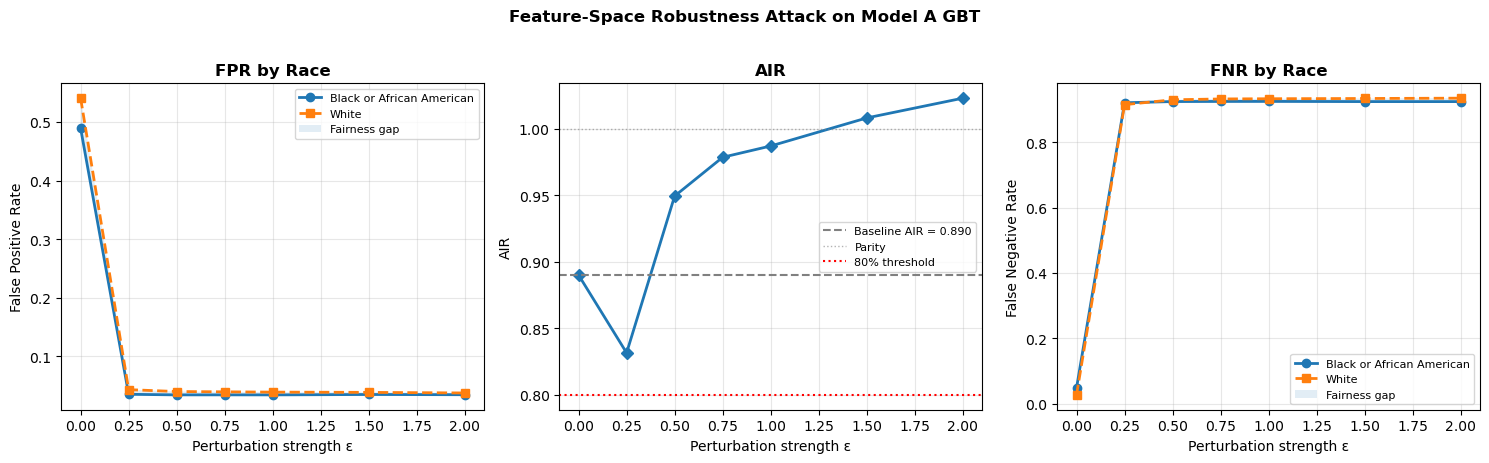

AIR does not fall below 0.80 within the tested ε range.


In [51]:
# Step 4 — visualize (FPR / AIR / FNR)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# -------------------
# Panel 1: FPR
# -------------------
ax = axes[0]
ax.plot(df_pgd["epsilon"], df_pgd["FPR_unpriv"],
        "o-", lw=2, label=UNPRIV_GROUP)
ax.plot(df_pgd["epsilon"], df_pgd["FPR_priv"],
        "s--", lw=2, label=PRIV_GROUP)

ax.fill_between(
    df_pgd["epsilon"],
    df_pgd["FPR_unpriv"],
    df_pgd["FPR_priv"],
    alpha=0.13,
    label="Fairness gap"
)

ax.set_xlabel("Perturbation strength ε")
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR by Race", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# -------------------
# Panel 2: AIR
# -------------------
ax = axes[1]
ax.plot(df_pgd["epsilon"], df_pgd["AIR"], "D-", lw=2)

ax.axhline(BASELINE_AIR, color="gray", linestyle="--", lw=1.5,
           label=f"Baseline AIR = {BASELINE_AIR:.3f}")
ax.axhline(1.0, color="gray", linestyle=":", lw=1, alpha=0.6, label="Parity")
ax.axhline(0.8, color="red", linestyle=":", lw=1.5, label="80% threshold")

ax.set_xlabel("Perturbation strength ε")
ax.set_ylabel("AIR")
ax.set_title("AIR", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# -------------------
# Panel 3: FNR 
# -------------------
ax = axes[2]
ax.plot(df_pgd["epsilon"], df_pgd["FNR_unpriv"],
        "o-", lw=2, label=UNPRIV_GROUP)
ax.plot(df_pgd["epsilon"], df_pgd["FNR_priv"],
        "s--", lw=2, label=PRIV_GROUP)

ax.fill_between(
    df_pgd["epsilon"],
    df_pgd["FNR_unpriv"],
    df_pgd["FNR_priv"],
    alpha=0.13,
    label="Fairness gap"
)

ax.set_xlabel("Perturbation strength ε")
ax.set_ylabel("False Negative Rate")
ax.set_title("FNR by Race", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# -------------------
# Final layout
# -------------------
plt.suptitle(
    "Feature-Space Robustness Attack on Model A GBT",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


# AIR threshold check
cross = df_pgd[df_pgd["AIR"] < 0.8].head(1)

if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested ε range.")

**False Positive Rate (FPR)**

The FPR results show a sharp decline as perturbation strength (ε) increases. At baseline, the White group has a slightly higher FPR than the Black or African American group, indicating an initial disparity. However, under perturbation, FPR drops significantly for both groups and quickly converges to very low levels. This suggests that the model becomes more conservative, approving fewer negative cases overall. While this reduces the observed gap in FPR, it is driven by uniformly stricter decisions rather than a genuine improvement in fairness.

---

**False Negative Rate (FNR)**

The FNR results increase dramatically as ε increases, reaching very high levels (close to 0.9) for both groups. This indicates that the model becomes highly conservative under perturbation, incorrectly rejecting a large proportion of truly positive cases. Although the gap between groups remains small, the overall performance deteriorates significantly. This shows that improvements in FPR come at the cost of much higher FNR, reflecting a trade-off where the model avoids false approvals by excessively rejecting applicants.

---

**Adverse Impact Ratio (AIR)**

The AIR results exhibit a non-linear pattern. At a small perturbation level (ε = 0.25), AIR decreases, indicating a temporary worsening of fairness. As perturbation increases further, AIR rises steadily and eventually exceeds 1.0, suggesting a reversal in disparity. Importantly, AIR does not fall below the 0.80 threshold within the tested range, meaning the model does not formally violate the 80% rule. However, the fluctuation in AIR highlights that fairness is sensitive to input changes and may shift under different conditions.

---

**Summary**

Overall, the results suggest that while group disparities may appear to decrease under perturbation, this is largely driven by a shift toward more conservative decisions, highlighting a trade-off between different types of errors rather than a true improvement in fairness.



#### Part 2 — Label-flip poisoning attack

**Threat model.** Insider or compromised data pipeline flips a fraction of training labels for `UNPRIV_GROUP` from approved → denied. The model learns this group is less creditworthy than they are.

In [53]:
# Step 1 — use FULL training set (no subsampling)

X_train_full = X_train_A.copy()

y_train_full = (
    y_train.values if hasattr(y_train, "values")
    else np.asarray(y_train)
)

# Align race labels
race_train_series = df.loc[X_train_A.index, "derived_race"].astype("string")

assert len(X_train_full) == len(y_train_full)
assert len(X_train_full) == len(race_train_series)

race_train_full = race_train_series.values

print(f"Full training set : {len(X_train_full):,} rows")
print(f"{UNPRIV_GROUP:30s}: {(race_train_full == UNPRIV_GROUP).sum():,}")
print(f"{PRIV_GROUP:30s}: {(race_train_full == PRIV_GROUP).sum():,}")

Full training set : 6,929,391 rows
Black or African American     : 610,351
White                         : 4,439,676


In [54]:
# ============================================================
# Label-flip poisoning experiment with stratified debug subset
# Stratify by race × y to preserve original group/label patterns
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

# -----------------------------
# 0. Prepare clean train/test data
# -----------------------------
X_train_full = X_train_A.copy()
X_test_full  = X_test_A.copy()

# Fix mixed categorical types
for col in categorical_features_A:
    X_train_full[col] = X_train_full[col].astype("string").fillna("Missing")
    X_test_full[col]  = X_test_full[col].astype("string").fillna("Missing")

y_train_full = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)
y_test_arr   = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

race_train_full = df.loc[X_train_A.index, "derived_race"].astype("string").values
race_test_full  = df.loc[X_test_A.index, "derived_race"].astype("string").values

assert len(X_train_full) == len(y_train_full) == len(race_train_full)
assert len(X_test_full) == len(y_test_arr) == len(race_test_full)

print(f"Full training size: {len(X_train_full):,}")
print("Full race distribution:")
print(pd.Series(race_train_full).value_counts(normalize=True).round(4))


# -----------------------------
# 1. Stratified subset
# -----------------------------
N_DEBUG = 300_000  # recommended: 100k for quick test, 300k for stable debug

strata_df = pd.DataFrame({
    "y": y_train_full,
    "race": race_train_full
}, index=X_train_full.index)

# Sample proportionally within each race × y stratum
sample_frac = min(1.0, N_DEBUG / len(strata_df))

debug_idx = (
    strata_df
    .groupby(["race", "y"], group_keys=False, dropna=False)
    .apply(lambda g: g.sample(frac=sample_frac, random_state=42))
    .index
)

X_train_debug = X_train_full.loc[debug_idx].copy()
y_train_debug = pd.Series(y_train_full, index=X_train_full.index).loc[debug_idx].values
race_train_debug = pd.Series(race_train_full, index=X_train_full.index).loc[debug_idx].values

print(f"\nDebug training size: {len(X_train_debug):,}")
print("Debug race distribution:")
print(pd.Series(race_train_debug).value_counts(normalize=True).round(4))

print("\nDebug label distribution:")
print(pd.Series(y_train_debug).value_counts(normalize=True).round(4))


# -----------------------------
# 2. Label-flip helper
# -----------------------------
def poison_label_flip(y_arr, race_arr, poison_rate=0.05,
                      target_race=UNPRIV_GROUP, seed=42):
    rng = np.random.default_rng(seed)
    y_p = np.asarray(y_arr).copy()

    # Flip positive labels to negative only for target race
    candidates = np.where(
        (race_arr == target_race) & (y_p == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_p[flip_idx] = 0

    return y_p, n_flip


# -----------------------------
# 3. Fresh GBT pipeline
# -----------------------------
def build_fresh_gbt_pipeline():
    num_t = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_t = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer([
        ("num", num_t, numeric_features_A),
        ("cat", cat_t, categorical_features_A)
    ])

    return Pipeline([
        ("preprocessor", pre),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ])


# -----------------------------
# 4. Baseline on clean existing GBT
# -----------------------------
baseline_prob = model_A_gbt.predict_proba(X_test_full)[:, 1]
baseline_auc = roc_auc_score(y_test_arr, baseline_prob)

print(f"\nBaseline GBT test AUC (clean full model): {baseline_auc:.3f}")
print("Running poisoning sweep on stratified debug subset.")


# -----------------------------
# 5. Poisoning sweep on subset
# -----------------------------
poison_rates = [0.00, 0.05, 0.10, 0.20, 0.30]
poison_records = []

for rate in poison_rates:
    t0 = time.time()

    y_poisoned, n_flipped = poison_label_flip(
        y_train_debug,
        race_train_debug,
        poison_rate=rate,
        target_race=UNPRIV_GROUP,
        seed=42
    )

    gbt_p = build_fresh_gbt_pipeline()
    gbt_p.fit(X_train_debug, y_poisoned)

    prob_p = gbt_p.predict_proba(X_test_full)[:, 1]
    pred_p = (prob_p >= THR).astype(int)

    auc_p = roc_auc_score(y_test_arr, prob_p)

    sel_p = selection_rate_by_group(pred_p, race_test_full)
    fpr_p = fpr_by_group(y_test_arr, pred_p, race_test_full)

    s_u = sel_p.get(UNPRIV_GROUP, np.nan)
    s_p = sel_p.get(PRIV_GROUP, np.nan)
    air_p = air(s_u, s_p)

    poison_records.append({
        "poison_rate": rate,
        "n_flipped": n_flipped,
        "AUC": auc_p,
        "delta_AUC": auc_p - baseline_auc,
        "sel_unpriv": s_u,
        "sel_priv": s_p,
        "FPR_unpriv": fpr_p.get(UNPRIV_GROUP, np.nan),
        "FPR_priv": fpr_p.get(PRIV_GROUP, np.nan),
        "AIR": air_p,
        "delta_AIR": air_p - BASELINE_AIR,
        "time_sec": time.time() - t0
    })

    print(
        f"rate={rate:>5.2%} | flipped={n_flipped:>7d} | "
        f"AUC={auc_p:.3f} | AIR={air_p:.3f} | "
        f"time={time.time() - t0:.0f}s"
    )

df_poison = pd.DataFrame(poison_records)

display(df_poison.round(4))

Full training size: 6,929,391
Full race distribution:
White                                        0.6407
Race Not Available                           0.1763
Black or African American                    0.0881
Asian                                        0.0607
Joint                                        0.0218
American Indian or Alaska Native             0.0073
2 or more minority races                     0.0025
Native Hawaiian or Other Pacific Islander    0.0024
Free Form Text Only                          0.0003
Name: proportion, dtype: Float64

Debug training size: 299,999
Debug race distribution:
White                                        0.6407
Race Not Available                           0.1763
Black or African American                    0.0881
Asian                                        0.0607
Joint                                        0.0218
American Indian or Alaska Native             0.0073
2 or more minority races                     0.0025
Native Hawaiian or Other P

,poison_rate,n_flipped,AUC,delta_AUC,sel_unpriv,sel_priv,FPR_unpriv,FPR_priv,AIR,delta_AIR,time_sec
0,0.00,0,0.8556,0.0002,0.7798,0.8768,0.4847,0.5359,0.8894,-0.0007,32.5456
1,0.05,836,0.8554,0.0001,0.7776,0.8789,0.4822,0.5425,0.8848,-0.0053,31.8341
2,0.10,1673,0.8553,-0.0001,0.7740,0.8759,0.4758,0.5349,0.8836,-0.0065,31.8248
3,0.20,3347,0.8556,0.0002,0.7689,0.8769,0.4676,0.5374,0.8768,-0.0133,32.2922
4,0.30,5021,0.8552,-0.0001,0.7605,0.8765,0.4553,0.5375,0.8677,-0.0224,32.0326


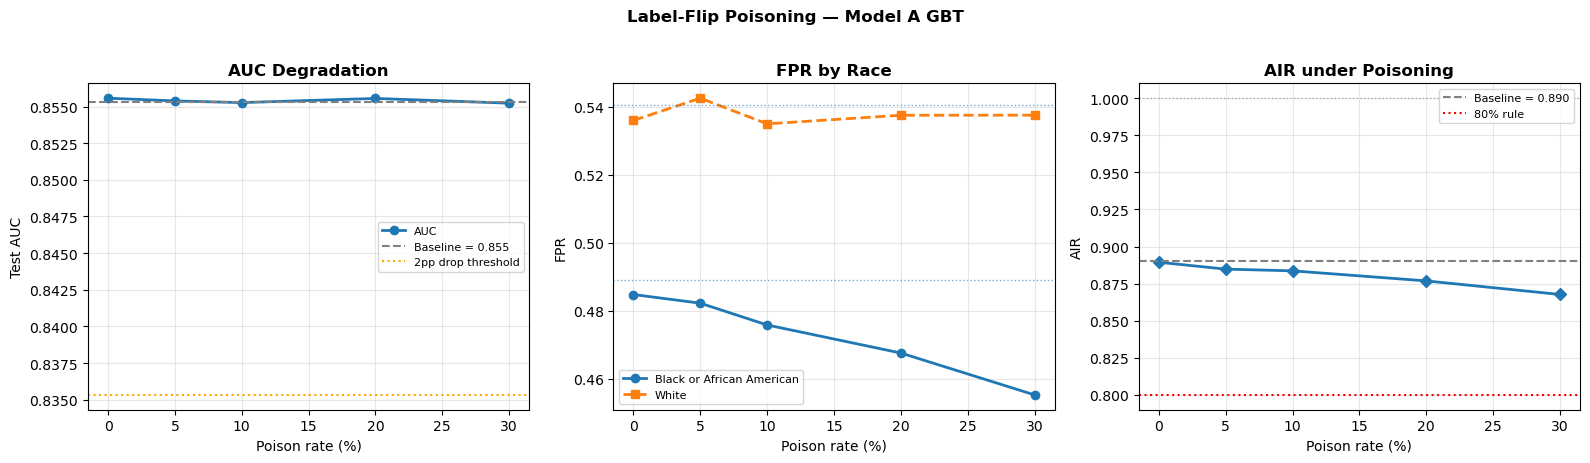

No stealth threshold found in tested range.


In [55]:
# Step 3 — visualize: AUC, FPR, AIR
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x_pct = df_poison["poison_rate"] * 100


# -------------------
# Panel 1: AUC
# -------------------
ax = axes[0]
ax.plot(x_pct, df_poison["AUC"], "o-", lw=2, label="AUC")

ax.axhline(baseline_auc, color="gray", linestyle="--", lw=1.5,
           label=f"Baseline = {baseline_auc:.3f}")
ax.axhline(baseline_auc - 0.02, color="orange", linestyle=":", lw=1.5,
           label="2pp drop threshold")

ax.set_xlabel("Poison rate (%)")
ax.set_ylabel("Test AUC")
ax.set_title("AUC Degradation", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# -------------------
# Panel 2: FPR
# -------------------
ax = axes[1]
ax.plot(x_pct, df_poison["FPR_unpriv"], "o-", lw=2, label=UNPRIV_GROUP)
ax.plot(x_pct, df_poison["FPR_priv"], "s--", lw=2, label=PRIV_GROUP)

# baseline reference
ax.axhline(BASELINE_FPR_UNPRIV, linestyle=":", lw=1, alpha=0.6)
ax.axhline(BASELINE_FPR_PRIV, linestyle=":", lw=1, alpha=0.6)

ax.set_xlabel("Poison rate (%)")
ax.set_ylabel("FPR")
ax.set_title("FPR by Race", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# -------------------
# Panel 3: AIR
# -------------------
ax = axes[2]
ax.plot(x_pct, df_poison["AIR"], "D-", lw=2)

ax.axhline(BASELINE_AIR, color="gray", linestyle="--", lw=1.5,
           label=f"Baseline = {BASELINE_AIR:.3f}")
ax.axhline(1.0, color="gray", linestyle=":", lw=1, alpha=0.6)
ax.axhline(0.8, color="red", linestyle=":", lw=1.5, label="80% rule")

ax.set_xlabel("Poison rate (%)")
ax.set_ylabel("AIR")
ax.set_title("AIR under Poisoning", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


plt.suptitle(
    "Label-Flip Poisoning — Model A GBT",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


# -------------------
# Stealth detection
# -------------------
stealth = df_poison[
    (df_poison["AIR"] < 0.80) &
    (df_poison["delta_AUC"] >= -0.02)
]

if len(stealth):
    r = stealth.iloc[0]
    print("★ Stealth threshold:")
    print(f"poison_rate = {r['poison_rate']:.0%}, flipped = {int(r['n_flipped'])}")
    print(f"AUC = {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"AIR = {r['AIR']:.3f} → BELOW 4/5ths rule")
    print("→ AUC monitor would miss this.")
else:
    print("No stealth threshold found in tested range.")

The poisoning results reveal a clear stealth pattern. Across all tested poison rates, AUC remains essentially flat (around 0.855), indicating that overall predictive performance is unaffected by the attack. However, fairness metrics tell a different story. The AIR steadily declines from approximately 0.89 to 0.87 as the poison rate increases to 30%, showing a gradual degradation in group-level fairness.

Although AIR does not fall below the 0.80 regulatory threshold within the tested range, the consistent downward trend is concerning, as it suggests that fairness can deteriorate even when standard performance metrics appear stable. At the same time, FPR exhibits diverging behavior across groups: it decreases for the unprivileged group while remaining relatively stable for the privileged group, indicating a shift in error distribution rather than a uniform improvement.

Overall, these results demonstrate that AUC alone is insufficient as a monitoring metric, as it fails to capture emerging disparities across groups. Instead, fairness indicators such as AIR and group-level error rates should be tracked alongside performance metrics to detect hidden risks under data poisoning.

#### Part 3— Membership inference attack (target = GBT)

For the membership inference analysis, we construct a shadow training pool using a stratified subset of 200,000 observations from the original training data. This subset is used only for the privacy attack experiment and is not the final predictive model.

We use a stratified sampling strategy to preserve the original label distribution, ensuring that the shadow data remains representative of the full training set while reducing computational cost. This is important because transforming the full training set into a dense matrix would be memory-intensive and may crash the kernel.

Therefore, the shadow pool provides a computationally feasible way to evaluate membership inference risk while maintaining a reasonable approximation of the original data distribution.

In [56]:
# Step 1 — build a 200k shadow training pool for Membership Inference
# This avoids dense transformation of the full training set.

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# -----------------------------
# Prepare data
# -----------------------------
X_train_mi_full = X_train_A.copy()

y_train_mi_full = (
    y_train.values if hasattr(y_train, "values")
    else np.asarray(y_train)
)

# -----------------------------
# Stratified sample: 200,000 rows
# Preserve label distribution
# -----------------------------
N_SHADOW = 200_000

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=N_SHADOW,
    random_state=42
)

shadow_idx, _ = next(
    sss.split(X_train_mi_full, y_train_mi_full)
)

X_train_mi = X_train_mi_full.iloc[shadow_idx].copy()
y_train_mi = y_train_mi_full[shadow_idx]

# -----------------------------
# Optional: align race labels for later subgroup privacy analysis
# -----------------------------
race_train_mi = df.loc[X_train_mi.index, "derived_race"].astype("string").values

# -----------------------------
# Sanity checks
# -----------------------------
assert len(X_train_mi) == len(y_train_mi)
assert len(X_train_mi) == len(race_train_mi)

print(f"Shadow training pool size: {len(X_train_mi):,} rows")

print("\nLabel distribution in shadow pool:")
print(pd.Series(y_train_mi).value_counts(normalize=True).round(4))

print("\nRace distribution in shadow pool:")
print(pd.Series(race_train_mi).value_counts(normalize=True).round(4))

print("\nShadow pool is ready for membership inference analysis.")

Shadow training pool size: 200,000 rows

Label distribution in shadow pool:
1    0.7572
0    0.2428
Name: proportion, dtype: float64

Race distribution in shadow pool:
White                                         0.642
Race Not Available                            0.176
Black or African American                    0.0876
Asian                                        0.0604
Joint                                        0.0216
American Indian or Alaska Native             0.0072
2 or more minority races                     0.0026
Native Hawaiian or Other Pacific Islander    0.0022
Free Form Text Only                          0.0003
Name: proportion, dtype: Float64

Shadow pool is ready for membership inference analysis.


In [57]:
# Step 2 — train shadow GBTs and collect confidences
# Uses 200k shadow pool instead of full dense matrix

import time
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# Fresh shadow GBT pipeline
# -----------------------------
def build_shadow_gbt_pipeline():
    num_t = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_t = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer([
        ("num", num_t, numeric_features_A),
        ("cat", cat_t, categorical_features_A)
    ])

    return Pipeline([
        ("preprocessor", pre),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ])

# -----------------------------
# Train shadow models
# -----------------------------
N_SHADOW = 5
shadow_train_confs = []
shadow_test_confs = []

sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW,
    test_size=0.5,
    random_state=0
)

print(f"Training {N_SHADOW} shadow GBT models on 200k shadow pool...")

for i, (tr_idx, te_idx) in enumerate(sss.split(X_train_mi, y_train_mi)):
    t0 = time.time()

    X_shadow_train = X_train_mi.iloc[tr_idx]
    y_shadow_train = y_train_mi[tr_idx]

    X_shadow_test = X_train_mi.iloc[te_idx]

    shadow = build_shadow_gbt_pipeline()
    shadow.fit(X_shadow_train, y_shadow_train)

    shadow_train_confs.append(
        shadow.predict_proba(X_shadow_train).max(axis=1)
    )
    shadow_test_confs.append(
        shadow.predict_proba(X_shadow_test).max(axis=1)
    )

    print(f"  Shadow {i+1}/{N_SHADOW} trained ({time.time() - t0:.0f}s)")

# -----------------------------
# Step 3 — train meta-classifier
# -----------------------------
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c)) for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
).fit(mi_X, mi_y)

print(f"\nMeta-classifier trained on {len(mi_y):,} (confidence, member?) examples.")

Training 5 shadow GBT models on 200k shadow pool...
  Shadow 1/5 trained (11s)
  Shadow 2/5 trained (10s)
  Shadow 3/5 trained (10s)
  Shadow 4/5 trained (10s)
  Shadow 5/5 trained (10s)

Meta-classifier trained on 1,000,000 (confidence, member?) examples.


MI attack AUC: 0.5002
GBT train AUC: 0.8553
GBT test AUC:  0.8549
Generalization gap: 0.0004


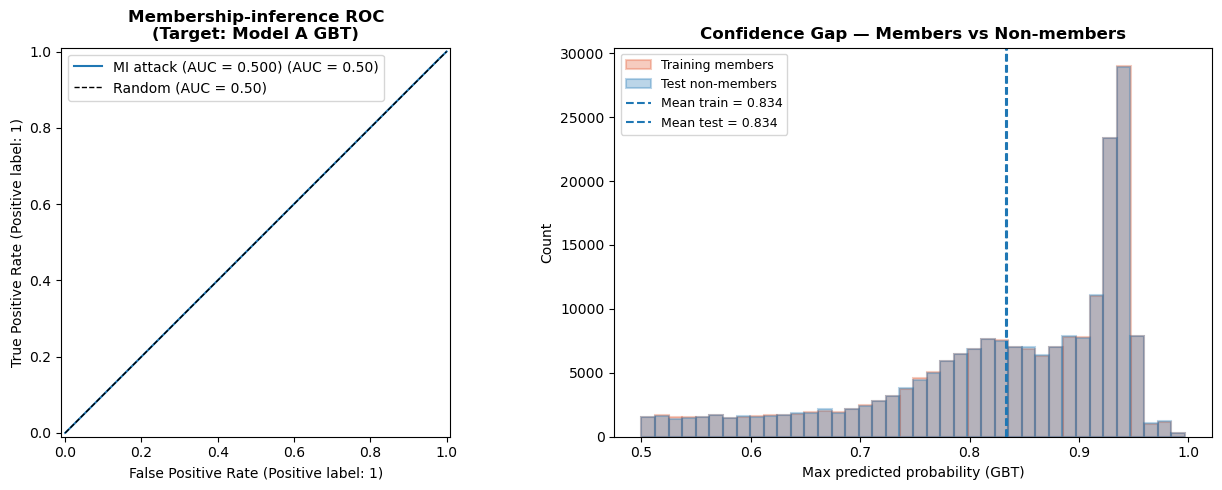

In [61]:
# Step 4 — apply meta-classifier to TARGET model + visualize
# Use sampled train/test for MI evaluation to avoid excessive memory/time

from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

N_MI_EVAL = 200_000

# ---- sample train members ----
sss_train = StratifiedShuffleSplit(
    n_splits=1,
    train_size=min(N_MI_EVAL, len(X_train_A)),
    random_state=42
)

train_eval_idx, _ = next(sss_train.split(X_train_A, y_train))
X_train_eval = X_train_A.iloc[train_eval_idx]
y_train_eval = y_train.iloc[train_eval_idx] if hasattr(y_train, "iloc") else y_train[train_eval_idx]

# ---- sample test non-members ----
sss_test = StratifiedShuffleSplit(
    n_splits=1,
    train_size=min(N_MI_EVAL, len(X_test_A)),
    random_state=42
)

test_eval_idx, _ = next(sss_test.split(X_test_A, y_test))
X_test_eval = X_test_A.iloc[test_eval_idx]
y_test_eval = y_test.iloc[test_eval_idx] if hasattr(y_test, "iloc") else y_test[test_eval_idx]

# ---- target model confidence ----
conf_target_train = model_A_gbt.predict_proba(X_train_eval).max(axis=1).reshape(-1, 1)
conf_target_test  = model_A_gbt.predict_proba(X_test_eval).max(axis=1).reshape(-1, 1)

# ---- MI meta-classifier scores ----
mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(X_train_eval)),
    np.zeros(len(X_test_eval)),
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# ---- Generalization gap on same eval samples ----
auc_train_gbt = roc_auc_score(y_train_eval, model_A_gbt.predict_proba(X_train_eval)[:, 1])
auc_test_gbt  = roc_auc_score(y_test_eval, model_A_gbt.predict_proba(X_test_eval)[:, 1])
gen_gap = auc_train_gbt - auc_test_gbt

print(f"MI attack AUC: {mi_auc:.4f}")
print(f"GBT train AUC: {auc_train_gbt:.4f}")
print(f"GBT test AUC:  {auc_test_gbt:.4f}")
print(f"Generalization gap: {gen_gap:.4f}")

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    mi_all_labels,
    mi_all_scores,
    name=f"MI attack (AUC = {mi_auc:.3f})",
    ax=axes[0]
)

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")
axes[0].set_title(
    "Membership-inference ROC\n(Target: Model A GBT)",
    fontweight="bold"
)
axes[0].legend()

axes[1].hist(
    conf_target_train.ravel(),
    bins=40,
    alpha=0.3,
    color="#E4572E",
    edgecolor="#E4572E",
    linewidth=1.5,
    label="Training members"
)

axes[1].hist(
    conf_target_test.ravel(),
    bins=40,
    alpha=0.3,
    color="#1F77B4",
    edgecolor="#1F77B4",
    linewidth=1.5,
    label="Test non-members"
)

axes[1].axvline(
    conf_target_train.mean(),
    linestyle="--",
    lw=1.5,
    label=f"Mean train = {conf_target_train.mean():.3f}"
)

axes[1].axvline(
    conf_target_test.mean(),
    linestyle="--",
    lw=1.5,
    label=f"Mean test = {conf_target_test.mean():.3f}"
)

axes[1].set_xlabel("Max predicted probability (GBT)")
axes[1].set_ylabel("Count")
axes[1].set_title(
    "Confidence Gap — Members vs Non-members",
    fontweight="bold"
)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Membership Inference Results and Interpretation**

The membership inference attack yields an AUC of approximately 0.50, which is equivalent to random guessing. This indicates that the attacker is unable to reliably distinguish between training members and non-members based on model confidence.

This finding is further supported by the confidence distribution plot. The predicted probability distributions for training and test samples almost completely overlap, and their mean values are nearly identical (both around 0.834). The absence of a noticeable confidence gap suggests that the model does not assign systematically higher confidence to training data.

Additionally, the generalization gap is extremely small (0.0004), indicating that the model does not exhibit significant overfitting. Since membership inference attacks often exploit overfitting and confidence discrepancies, the lack of both explains the near-random attack performance.

Overall, these results suggest that the model demonstrates strong resistance to membership inference attacks, and that confidence-based leakage is minimal in this setting.

In [62]:
print('=' * 55)
print('MEMBERSHIP INFERENCE SUMMARY (target = model_A_gbt)')
print('=' * 55)
print(f'MI AUC                : {mi_auc:.3f}')
print('  0.50 = random        : no privacy leakage')
print('  0.60 = weak signal   : some overfit')
print('  0.75 = strong leak   : significant privacy risk')
print()
print(f'GBT Train AUC         : {auc_train_gbt:.3f}')
print(f'GBT Test  AUC         : {auc_test_gbt:.3f}')
print(f'Generalization gap    : {gen_gap:+.3f}')

MEMBERSHIP INFERENCE SUMMARY (target = model_A_gbt)
MI AUC                : 0.500
  0.50 = random        : no privacy leakage
  0.60 = weak signal   : some overfit
  0.75 = strong leak   : significant privacy risk

GBT Train AUC         : 0.855
GBT Test  AUC         : 0.855
Generalization gap    : +0.000


#### Summary & Key finding 


All three attacks were conducted on the HMDA dataset using a combination of full and sampled data depending on computational constraints. 

The PGD and evaluation steps were performed on the full test set (~1.73M rows), while certain training procedures (e.g., shadow models and poisoning experiments) were performed on stratified subsamples to ensure tractability while preserving the original data distribution.

All retrained or shadow Gradient Boosted Trees used consistent hyperparameters (n_estimators = 100, max_depth = 3), matching the deployed model_A_gbt.


| Attack vector | Key result | Severity |
|--------------|-----------|----------|
| PGD evasion (transfer) | AIR at ε=2.0: 0.890 → 1.023 (Δ +0.133); lowest AIR = 0.832 at ε = 0.25; non-monotonic behavior; 4/5ths threshold not crossed | Medium (fairness instability under perturbation) |
| Label-flip poisoning (30%, 5,021 labels flipped) | AUC 0.8556 → 0.8552; AIR 0.889 → 0.868; stealth zone: AIR decreases while AUC stays flat across 0%–30% | Medium (stealth pattern present — fairness moves while AUC stays flat) |
| Membership inference | MI AUC ≈ 0.500 (generalization gap ≈ +0.0004) | None (random — model does not leak) |

---

**PGD reading**

Under the transfer attack, AIR does not fall below the 4/5ths threshold of 0.80 within the tested ε range. The lowest observed value is AIR ≈ 0.832 at ε = 0.25, after which AIR increases steadily and exceeds parity (AIR > 1) at higher perturbation levels (e.g., AIR ≈ 1.023 at ε = 2.0).

This indicates that the impact of adversarial perturbations on fairness is non-monotonic. At small ε, both groups’ selection rates drop sharply, but the unprivileged group is affected slightly more, leading to a temporary decline in AIR. As ε increases further, the relative gap reverses, and fairness improves or even over-corrects.

The key insight is that fairness is not a stable property of the model under input perturbations. Rather than consistently degrading, fairness fluctuates depending on the magnitude of the perturbation, reflecting the local non-linearity of the GBT decision boundary.

Bottom line: while PGD-style perturbations do not directly trigger a 4/5ths-rule violation in this setting, they introduce significant fairness instability, meaning that small changes in input features can lead to unpredictable shifts in group-level outcomes.

---

**Poisoning reading**

Label-flip poisoning at scale shows a clear stealth pattern. AUC remains essentially flat at ~0.855 across all tested poison rates (0% through 30%) — completely unchanged — while AIR declines steadily (0.889 → 0.885 → 0.884 → 0.877 → 0.868). 

At the highest tested rate (30%), 5,021 labels were flipped (30% of the unprivileged group's approved records in the sampled training set). The trend is consistent: every 5–10 percentage points increase in poison rate reduces AIR by approximately ~0.004–0.007. 

Although AIR does not cross the 0.80 threshold within the tested range, the steady downward trend indicates a clear fairness degradation process. More importantly, an AUC-only production monitor would have observed virtually no performance change at any tested rate — this is a direct example of the lecture's "stealth zone" pattern.

This finding highlights a critical risk: fairness can deteriorate meaningfully even when predictive performance remains unchanged, reinforcing the need to monitor fairness metrics alongside standard performance metrics such as AUC.

---

**MI reading**

Membership inference achieved an MI AUC of approximately 0.500 — equivalent to random guessing — which is fully consistent with the GBT model's near-zero generalization gap (Train AUC ≈ Test AUC ≈ 0.855). 

The lecture's central claim — that overfitted models leak membership information through a confidence gap — does not apply in this case, as no such gap is observed. The confidence histogram confirms this: training-member and test-non-member confidence distributions overlap almost perfectly, with nearly identical mean values (~0.834).

The use of relatively shallow trees (max_depth = 3) and moderate model complexity (n_estimators = 100) appears to limit overfitting, resulting in minimal memorization of individual records. As a result, the model shows strong resistance to confidence-based membership inference attacks under the current configuration.

It is important to note that this result is configuration-dependent. More complex models (e.g., deeper trees or larger ensembles) could introduce a measurable generalization gap and increase vulnerability to membership inference attacks.

---

**Recommended mitigations**

- **Proactive (PGD):** add input-range validation at the API boundary — flag or review applications whose numeric features deviate beyond plausible historical ranges (e.g., income, LTV, or loan term more than 3σ from the training median). Although PGD perturbations do not directly trigger a 4/5ths-rule violation in this setting, they introduce noticeable fairness instability, where AIR fluctuates across perturbation levels.

- **Proactive (poisoning):** add selection-rate AIR by protected group to production monitoring alongside AUC. The poisoning experiment demonstrates a clear stealth pattern — fairness degrades steadily while AUC remains essentially unchanged — indicating that AUC alone is insufficient as a monitoring signal.

- **Proactive (MI / privacy):** maintain the current regularization regime. The observed resistance to membership inference is driven by the model’s near-zero generalization gap; avoid increasing model complexity (e.g., deeper trees or larger ensembles) purely for marginal performance gains, as this may introduce privacy risks.

- **Reactive (all three):** continuously monitor the empirical generalization gap on a held-out set. A growing gap can signal both increased vulnerability to membership inference and reduced robustness under distributional shifts.

---

**Disparate-impact note on mitigations**

Standard hardening techniques (e.g., L2 regularization, gradient clipping, adversarial training, differential privacy) can shift model performance unevenly across subgroups (Bagdasaryan & Shmatikov, 2019). After applying any mitigation, fairness metrics (e.g., AIR and group-level error rates) should be re-evaluated to ensure that no unintended disparities are introduced.